# Stats for the Verb Phrase

In [ ]:
#first parse the corpus
# Import the toolkit, giving it a shorter alias 'mptf'
import mptf_parser as mptf

# Set folder paths
input_folder = r"C:\Users\rahaa\Dropbox\MPCD\exports_28-1-2026"
output_folder = r"C:\Users\rahaa\Dropbox\MPCD\the syntax project\nounphrase\export_files\conllu_output"

In [3]:
import os
from conllu import parse
from conllu.parser import DEFAULT_FIELD_PARSERS
import mptf_parser as mptf

# ======================================================
# LOAD BOTH CORPORA
# ======================================================

print("\n--- Loading corpora ---")

custom_field_parsers = DEFAULT_FIELD_PARSERS.copy()
custom_field_parsers["id"] = lambda line, i: line[i]
custom_field_parsers["head"] = lambda line, i: line[i]

my_corpus = []
syntactically_annotated_corpus = []

conllu_files = sorted(
    f for f in os.listdir(output_folder)
    if f.lower().endswith(".conllu")
    and "outdated" not in f.lower()
)

for filename in conllu_files:
    file_path = os.path.join(output_folder, filename)

    with open(file_path, "r", encoding="utf-8") as f:
        raw_data = f.read()

    # --- Clean malformed lines ---
    lines = raw_data.splitlines()
    clean_lines = [
        line for line in lines
        if line.startswith("#")
        or line.strip() == ""
        or line.count("\t") == 9
    ]
    clean_data = "\n".join(clean_lines) + "\n"

    # --- Parse sentences ---
    sentences = parse(clean_data, field_parsers=custom_field_parsers)

    for sent in sentences:
        sentence_obj = mptf.Sentence(
            sent,
            source_filename=filename
        )
        sentence_obj.metadata["source_filename"] = filename

        # → always add to the full corpus
        my_corpus.append(sentence_obj)

        # → add to syntactic corpus ONLY if deprel exists
        if any(tok.get("deprel") not in (None, "_") for tok in sent):
            syntactically_annotated_corpus.append(sentence_obj)

# ======================================================
# CONFIRMATION
# ======================================================

print("✔ Corpora loaded successfully.")
print(f"  my_corpus (all texts):")
print(f"    texts:     {len(set(s.metadata['source_filename'] for s in my_corpus))}")
print(f"    sentences: {len(my_corpus)}")

print(f"\n  syntactically_annotated_corpus:")
print(f"    texts:     {len(set(s.metadata['source_filename'] for s in syntactically_annotated_corpus))}")
print(f"    sentences: {len(syntactically_annotated_corpus)}")



--- Loading corpora ---
✔ Corpora loaded successfully.
  my_corpus (all texts):
    texts:     42
    sentences: 33471

  syntactically_annotated_corpus:
    texts:     31
    sentences: 5451


Globally:

percentage = deprel count ÷ total number of dependency-annotated tokens in the corpus

Per text:

percentage = deprel count ÷ total number of dependency-annotated tokens in that text

In [4]:
from collections import Counter, defaultdict

# ======================================================
# INITIALIZE COUNTERS
# ======================================================

# Global
global_deprel_counts = Counter()
global_total_tokens = 0

# Per text
per_text_deprel = defaultdict(Counter)
per_text_total_tokens = defaultdict(int)

# ======================================================
# ITERATE OVER SYNTACTIC CORPUS
# ======================================================

for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")

    for token in sentence.get_tokens():

        # Skip empty or malformed tokens
        if not token.deprel:
            continue

        if token.form in {"_", "__"}:
            continue

        # If deprel contains '|', keep only the second part
        deprel = token.deprel.split("|")[-1]

        # Global
        global_deprel_counts[deprel] += 1
        global_total_tokens += 1

        # Per text
        per_text_deprel[text_id][deprel] += 1
        per_text_total_tokens[text_id] += 1

# ======================================================
# COMPUTE RATIOS
# ======================================================

# Global ratios
global_deprel_ratios = {
    dep: count / global_total_tokens * 100
    for dep, count in global_deprel_counts.items()
}

# Per-text ratios
per_text_deprel_ratios = defaultdict(dict)

for text_id, counts in per_text_deprel.items():
    total = per_text_total_tokens[text_id]
    for dep, count in counts.items():
        per_text_deprel_ratios[text_id][dep] = (
            count / total * 100 if total > 0 else 0
        )

# ======================================================
# DISPLAY RESULTS
# ======================================================

print("=== Global DEPREL Statistics ===")

for dep, count in global_deprel_counts.most_common():
    percent = (count / global_total_tokens * 100) if global_total_tokens > 0 else 0
    print(f"{dep:<15} {count:>8}  ({percent:6.2f}%)")

print("\n=== Per-Text DEPREL Statistics ===")

for text_id, dep_counts in sorted(per_text_deprel.items()):
    total = per_text_total_tokens[text_id]

    print(f"\nText: {text_id}")
    print(f"{'DEPREL':<15} {'Count':>8}  {'Percent':>9}")
    print("-" * 36)

    for dep, count in dep_counts.most_common():
        percent = (count / total * 100) if total > 0 else 0
        print(f"{dep:<15} {count:>8}  ({percent:6.2f}%)")


=== Global DEPREL Statistics ===
case                8291  (  9.42%)
det                 7843  (  8.91%)
obl                 6672  (  7.58%)
nmod                6479  (  7.36%)
conj                6302  (  7.16%)
cc                  6273  (  7.13%)
advmod              6220  (  7.07%)
nsubj               5986  (  6.80%)
root                5283  (  6.00%)
mark                4319  (  4.91%)
obj                 2818  (  3.20%)
advcl               2361  (  2.68%)
_                   2354  (  2.67%)
amod                2317  (  2.63%)
punct               1932  (  2.19%)
acl:relcl           1471  (  1.67%)
xcomp               1294  (  1.47%)
nummod              1113  (  1.26%)
cop                  776  (  0.88%)
ccomp                679  (  0.77%)
aux                  679  (  0.77%)
parataxis            608  (  0.69%)
obl:lmod             605  (  0.69%)
appos                525  (  0.60%)
reparandum           487  (  0.55%)
dep                  398  (  0.45%)
advmod:tmod          359  (  0.

In [5]:
from collections import defaultdict, Counter

# ======================================================
# SETTINGS
# ======================================================

TARGET_DEPRELS = {"aux", "cop", "xcomp"}

# ======================================================
# DATA STRUCTURES
# ======================================================

# deprel -> lemma -> total count
deprel_lemma_counts = defaultdict(Counter)

# deprel -> lemma -> feat_key -> count
deprel_lemma_feat_key_counts = defaultdict(
    lambda: defaultdict(Counter)
)

# deprel -> lemma -> feat_key -> Counter(values)
deprel_lemma_feat_value_counts = defaultdict(
    lambda: defaultdict(lambda: defaultdict(Counter))
)

# ======================================================
# ITERATE OVER SYNTACTIC CORPUS
# ======================================================

for sentence in syntactically_annotated_corpus:
    for token in sentence.get_tokens():

        # Basic sanity checks
        if not token.deprel or not token.lemma:
            continue

        if token.form in {"_", "__"}:
            continue

        # If pipe-separated, keep SECOND deprel
        deprel = token.deprel.split("|")[-1]
        # Normalize LEMMA: keep FIRST if pipe-separated
    

        if deprel not in TARGET_DEPRELS:
            continue

        lemma = token.lemma.split("|")[0]
        # Count lemma per deprel
        deprel_lemma_counts[deprel][lemma] += 1

        feats = token.feats or {}

        for feat_key, feat_value in feats.items():
            deprel_lemma_feat_key_counts[deprel][lemma][feat_key] += 1
            deprel_lemma_feat_value_counts[deprel][lemma][feat_key][feat_value] += 1
print("=== DEPREL → LEMMA → FEATS STATISTICS ===")

for deprel in sorted(deprel_lemma_counts):
    print(f"\n==============================")
    print(f"DEPREL: {deprel}")
    print("==============================")

    for lemma, total in deprel_lemma_counts[deprel].most_common():
        print(f"\nLemma: {lemma}")
        print(f"  Total tokens: {total}")

        feat_keys = deprel_lemma_feat_key_counts[deprel][lemma]

        if not feat_keys:
            print("  FEATS: none")
            continue

        print("  FEATS:")

        for feat_key, key_count in feat_keys.items():
            print(f"    {feat_key}: {key_count}")

            for value, value_count in (
                deprel_lemma_feat_value_counts[deprel][lemma][feat_key].most_common()
            ):
                print(f"      {value}: {value_count}")


=== DEPREL → LEMMA → FEATS STATISTICS ===

DEPREL: aux

Lemma: ēstādan
  Total tokens: 317
  FEATS:
    Mood: 316
      Ind: 315
      Opt: 1
    Number: 316
      Sing: 300
      Plur: 16
    Person: 316
      3: 312
      1: 3
      2: 1
    Subcat: 317
      Intr: 317
    Tense: 317
      Pres: 282
      Past: 35
    VerbForm: 317
      Fin: 313
      Inf: 3
      Part: 1
    VerbType: 311
      Cop: 311
    Typo: 8
      Yes: 8

Lemma: h-
  Total tokens: 308
  FEATS:
    Mood: 308
      Ind: 253
      Opt: 35
      Sub: 20
    Number: 308
      Plur: 209
      Sing: 99
    Person: 308
      3: 252
      2: 30
      1: 26
    Subcat: 207
      Intr: 207
    Tense: 308
      Pres: 308
    VerbForm: 307
      Fin: 307
    VerbType: 258
      Cop: 258
    Polarity: 1
      Neg: 1
    Typo: 4
      Yes: 4

Lemma: būdan
  Total tokens: 54
  FEATS:
    Mood: 51
      Ind: 49
      Sub: 2
    Number: 51
      Sing: 50
      Plur: 1
    Person: 51
      3: 51
    Subcat: 54
      Intr: 54
 

In [6]:
from collections import defaultdict, Counter

# ======================================================
# TARGET DEPRELS
# ======================================================

TARGET_DEPRELS = {"aux", "cop", "xcomp"}

# ======================================================
# DATA STRUCTURE
# ======================================================
# stats[deprel][lemma] = {
#     "count": int,
#     "feats": {
#         feat_key: Counter({value: freq})
#     }
# }

stats = defaultdict(
    lambda: defaultdict(
        lambda: {
            "count": 0,
            "feats": defaultdict(Counter)
        }
    )
)

# ======================================================
# ITERATE OVER SYNTACTIC CORPUS
# ======================================================

for sentence in syntactically_annotated_corpus:

    # Build token index for head lookup
    tokens_by_id = {tok.id: tok for tok in sentence.get_tokens()}

    for token in sentence.get_tokens():

        # --------------------------
        # BASIC FILTERS
        # --------------------------
        if not token.deprel or not token.lemma:
            continue

        if token.form in {"_", "__"}:
            continue

        # --------------------------
        # NORMALIZE DEPREL
        # (take second if pipe-separated)
        # --------------------------
        deprel = token.deprel.split("|")[-1]

        if deprel not in TARGET_DEPRELS:
            continue

        # --------------------------
        # NORMALIZE LEMMA
        # (take first if pipe-separated)
        # --------------------------
        lemma = token.lemma.split("|")[0]

        if not lemma or lemma in {"_", "__"}:
            continue

        # --------------------------
        # SPECIAL RULE FOR XCOMP
        # HEAD must have VerbType=Mod
        # --------------------------
        if deprel == "xcomp":

            head = tokens_by_id.get(token.head)

            if not head or not head.feats:
                continue

            if head.feats.get("VerbType") != "Mod":
                continue

        # ==================================================
        # COUNTING
        # ==================================================

        entry = stats[deprel][lemma]
        entry["count"] += 1

        if token.feats:
            for feat_key, feat_val in token.feats.items():
                entry["feats"][feat_key][feat_val] += 1

# ======================================================
# DISPLAY RESULTS
# ======================================================

for deprel in sorted(stats):

    print(f"\n{'='*60}")
    print(f"DEPREL: {deprel}")
    print(f"{'='*60}")

    for lemma, data in sorted(
        stats[deprel].items(),
        key=lambda x: x[1]["count"],
        reverse=True
    ):

        print(f"\nLemma: {lemma}")
        print(f"  Total occurrences: {data['count']}")

        if not data["feats"]:
            print("  FEATS: none")
            continue

        print("  FEATS:")
        for feat_key, values in data["feats"].items():
            print(f"    {feat_key}:")
            for val, cnt in values.most_common():
                print(f"      {val}: {cnt}")



DEPREL: aux

Lemma: ēstādan
  Total occurrences: 317
  FEATS:
    Mood:
      Ind: 315
      Opt: 1
    Number:
      Sing: 300
      Plur: 16
    Person:
      3: 312
      1: 3
      2: 1
    Subcat:
      Intr: 317
    Tense:
      Pres: 282
      Past: 35
    VerbForm:
      Fin: 313
      Inf: 3
      Part: 1
    VerbType:
      Cop: 311
    Typo:
      Yes: 8

Lemma: h-
  Total occurrences: 308
  FEATS:
    Mood:
      Ind: 253
      Opt: 35
      Sub: 20
    Number:
      Plur: 209
      Sing: 99
    Person:
      3: 252
      2: 30
      1: 26
    Subcat:
      Intr: 207
    Tense:
      Pres: 308
    VerbForm:
      Fin: 307
    VerbType:
      Cop: 258
    Polarity:
      Neg: 1
    Typo:
      Yes: 4

Lemma: būdan
  Total occurrences: 54
  FEATS:
    Mood:
      Ind: 49
      Sub: 2
    Number:
      Sing: 50
      Plur: 1
    Person:
      3: 51
    Subcat:
      Intr: 54
    Tense:
      Pres: 27
      Past: 26
    VerbForm:
      Fin: 51
      Part: 2
      Inf: 1
    Ve

In [7]:
from collections import defaultdict, Counter

# ======================================================
# DATA STRUCTURE FOR AUXILIARIES
# ======================================================
# aux_stats[lemma] = {
#     "count": int,
#     "feats": {feat_key: Counter({feat_val: freq})}
# }
aux_stats = defaultdict(lambda: {"count": 0, "feats": defaultdict(Counter)})

# ======================================================
# ITERATE OVER SYNTACTICALLY ANNOTATED CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    for token in sentence.get_tokens():

        # --------------------------
        # FILTERS
        # --------------------------
        if not token.deprel or not token.lemma:
            continue
        if token.form in {"_", "__"}:
            continue
        # Only auxiliaries
        if token.deprel.split("|")[-1] != "aux":
            continue

        # Normalize lemma (take first pipe variant without spaces)
        lemma_candidates = token.lemma.split("|")
        lemma = next((l for l in lemma_candidates if " " not in l), lemma_candidates[0])

        if not lemma or lemma in {"_", "__"}:
            continue

        # --------------------------
        # COUNTING
        # --------------------------
        entry = aux_stats[lemma]
        entry["count"] += 1

        if token.feats:
            for feat_key, feat_val in token.feats.items():
                entry["feats"][feat_key][feat_val] += 1

# ======================================================
# DISPLAY RESULTS
# ======================================================
print("\n" + "="*60)
print("AUXILIARY LEMMAS AND THEIR FEATS")
print("="*60)

for lemma, data in sorted(aux_stats.items(), key=lambda x: x[1]["count"], reverse=True):
    print(f"\nLemma: {lemma}")
    print(f"  Total occurrences: {data['count']}")

    if not data["feats"]:
        print("  FEATS: none")
        continue

    print("  FEATS:")
    for feat_key, val_counter in data["feats"].items():
        print(f"    {feat_key}:")
        for val, cnt in val_counter.most_common():
            print(f"      {val}: {cnt}")



AUXILIARY LEMMAS AND THEIR FEATS

Lemma: ēstādan
  Total occurrences: 317
  FEATS:
    Mood:
      Ind: 315
      Opt: 1
    Number:
      Sing: 300
      Plur: 16
    Person:
      3: 312
      1: 3
      2: 1
    Subcat:
      Intr: 317
    Tense:
      Pres: 282
      Past: 35
    VerbForm:
      Fin: 313
      Inf: 3
      Part: 1
    VerbType:
      Cop: 311
    Typo:
      Yes: 8

Lemma: h-
  Total occurrences: 308
  FEATS:
    Mood:
      Ind: 253
      Opt: 35
      Sub: 20
    Number:
      Plur: 209
      Sing: 99
    Person:
      3: 252
      2: 30
      1: 26
    Subcat:
      Intr: 207
    Tense:
      Pres: 308
    VerbForm:
      Fin: 307
    VerbType:
      Cop: 258
    Polarity:
      Neg: 1
    Typo:
      Yes: 4

Lemma: būdan
  Total occurrences: 54
  FEATS:
    Mood:
      Ind: 49
      Sub: 2
    Number:
      Sing: 50
      Plur: 1
    Person:
      3: 51
    Subcat:
      Intr: 54
    Tense:
      Pres: 27
      Past: 26
    VerbForm:
      Fin: 51
      Part: 

In [8]:
from collections import defaultdict, Counter

# ------------------------------
# Helper function to normalize lemma
# ------------------------------
def select_lemma(lemma_str):
    candidates = lemma_str.split("|")
    for cand in candidates:
        if " " not in cand:
            return cand
    return candidates[0]

# ------------------------------
# Initialize data structure
# ------------------------------
# aux_phrases[aux_lemma] = Counter({phrase_str: count})
aux_phrases = defaultdict(Counter)

# ------------------------------
# Iterate over syntactic corpus
# ------------------------------
for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    token_by_id = {str(tok.id): tok for tok in tokens if tok.id is not None}

    for token in tokens:
        # --------------------------
        # Basic filters
        # --------------------------
        if not token.lemma or not token.feats or token.form in {"_", "__"}:
            continue

        # Only auxiliaries
        if token.deprel.split("|")[-1] != "aux":
            continue

        aux_lemma = select_lemma(token.lemma)

        # --------------------------
        # Get head token of the auxiliary
        # --------------------------
        head_token = token_by_id.get(str(token.head))
        if not head_token or not head_token.lemma:
            continue

        head_lemma = select_lemma(head_token.lemma)

        # --------------------------
        # Get particle dependents of the head
        # --------------------------
        particle_set = {"bē", "be", "nē", "ham", "hamēw"}
        head_dependents = [
            dep for dep in tokens
            if str(dep.head) == str(head_token.id) and select_lemma(dep.lemma) in particle_set
        ]

        # --------------------------
        # Build phrase: particles + head + auxiliary
        # --------------------------
        phrase_tokens = head_dependents + [head_token, token]  # particles, head, aux
        phrase_tokens_sorted = sorted(phrase_tokens, key=lambda x: x.id)
        phrase_lemmas = [select_lemma(t.lemma) for t in phrase_tokens_sorted]
        phrase_str = " ".join(phrase_lemmas)

        aux_phrases[aux_lemma][phrase_str] += 1

# ------------------------------
# Display results
# ------------------------------
print("\n" + "="*60)
print("AUXILIARY PHRASES WITH PARTICLES")
print("="*60)

for aux_lemma, phrases in sorted(aux_phrases.items()):
    print(f"\nAuxiliary: {aux_lemma}")
    for phrase, count in phrases.most_common():
        print(f"  {phrase}: {count}")



AUXILIARY PHRASES WITH PARTICLES

Auxiliary: būdan
  nē tuwān būdan: 6
  guftan būdan: 5
  kirdan būdan: 4
  dādan būdan: 4
  bištan būdan: 4
  šnāyēnīdan būdan: 4
  paydāgēnīdan būdan: 2
  šudan būdan: 2
  stāyīdār būdan: 1
  ēdōn būdan: 1
  dāštan būdan: 1
  wirāstan būdan: 1
  madan1 būdan: 1
  ōzadan būdan: 1
  tuwān būdan: 1
  brēhēnīdan būdan: 1
  kāmag būdan: 1
  hamkōxšīdan būdan: 1
  ǰastan būdan: 1
  bē taxtan būdan: 1
  paydāg būdan: 1
  wisāndan būdan: 1
  xwardan būdan: 1
  murnǰēnīdan būdan: 1
  rāmēnīdan būdan: 1
  bē dādan būdan: 1
  be griftan būdan: 1
  abzāyišn būdan: 1
  āmārīhā būdan: 1
  madan būdan: 1
  būdan būdan: 1

Auxiliary: h-
  būdan h-: 26
  madan1 h-: 13
  dādan h-: 9
  šudan h-: 9
  kirdan h-: 8
  ēstādan h-: 7
  rustan h-: 7
  waštan h-: 5
  raftan1 h-: 5
  brēhēnīdan h-: 5
  āmadan h-: 4
  dwāristan h-: 4
  ǰastan h-: 4
  waxšīdan h-: 4
  guftan h-: 4
  madan h-: 4
  xwāstan h-: 3
  gumārdan h-: 3
  kōxšīdan h-: 3
  axwāstār h-: 3
  raftan h-: 3
  nē

In [9]:
#investigation of Lightverbs
from collections import defaultdict, Counter

# ======================================================
# DATA STRUCTURE
# ======================================================
# light_verbs[lemma] = {
#     "count": int,
#     "feats": {
#         feat_key: Counter({value: freq})
#     }
# }

light_verbs = defaultdict(
    lambda: {
        "count": 0,
        "feats": defaultdict(Counter)
    }
)

# ======================================================
# ITERATE OVER SYNTACTIC CORPUS
# ======================================================

for sentence in syntactically_annotated_corpus:

    for token in sentence.get_tokens():

        # --------------------------
        # BASIC FILTERS
        # --------------------------
        if not token.lemma or not token.feats:
            continue

        if token.form in {"_", "__"}:
            continue

        # --------------------------
        # CHECK VerbType=Light
        # --------------------------
        if token.feats.get("VerbType") != "Light":
            continue

        # --------------------------
        # NORMALIZE LEMMA
        # (take first if pipe-separated)
        # --------------------------
        lemma = token.lemma.split("|")[0]

        if not lemma or lemma in {"_", "__"}:
            continue

        # ==================================================
        # COUNTING
        # ==================================================

        entry = light_verbs[lemma]
        entry["count"] += 1

        for feat_key, feat_val in token.feats.items():
            entry["feats"][feat_key][feat_val] += 1

# ======================================================
# DISPLAY RESULTS
# ======================================================

print("\n" + "=" * 60)
print("VERBS WITH VerbType=Light")
print("=" * 60)

for lemma, data in sorted(
    light_verbs.items(),
    key=lambda x: x[1]["count"],
    reverse=True
):

    print(f"\nLemma: {lemma}")
    print(f"  Total occurrences: {data['count']}")

    if not data["feats"]:
        print("  FEATS: none")
        continue

    print("  FEATS:")
    for feat_key, values in data["feats"].items():
        print(f"    {feat_key}:")
        for val, cnt in values.most_common():
            print(f"      {val}: {cnt}")



VERBS WITH VerbType=Light

Lemma: kirdan
  Total occurrences: 168
  FEATS:
    Subcat:
      Tran: 166
      Intr: 2
    Tense:
      Pres: 71
      Past: 56
    VerbForm:
      Fin: 117
      Inf: 36
      Part: 10
      Vnoun: 5
    VerbType:
      Light: 168
    Mood:
      Ind: 108
      Nec: 8
      Imp: 8
    Number:
      Sing: 97
      Plur: 20
    Person:
      3: 104
      2: 9
      1: 4
    Typo:
      Yes: 7
    Animacy:
      Inan: 1

Lemma: burdan
  Total occurrences: 31
  FEATS:
    Mood:
      Ind: 21
      Imp: 4
      Nec: 2
    Number:
      Sing: 21
      Plur: 4
    Person:
      3: 17
      2: 5
      1: 3
    Subcat:
      Tran: 31
    Tense:
      Pres: 16
      Past: 9
    VerbForm:
      Fin: 25
      Inf: 5
      Vnoun: 1
    VerbType:
      Light: 31
    Animacy:
      Inan: 1
    Typo:
      Yes: 1

Lemma: dāštan
  Total occurrences: 23
  FEATS:
    Mood:
      Ind: 13
      Nec: 4
    Subcat:
      Tran: 23
    VerbForm:
      Fin: 13
      Inf: 8
      

In [10]:
from collections import defaultdict, Counter

# ======================================================
# DATA STRUCTURE
# ======================================================
# lightverb_lvc[light_lemma] = {
#     "total": int,
#     "lvc_dependents": Counter({dependent_lemma: count})
# }
lightverb_lvc = defaultdict(lambda: {"total": 0, "lvc_dependents": Counter()})

def select_lemma(lemma_str):
    """
    Given a lemma that might be pipe-separated, return the first lemma
    that does NOT contain a space. If all contain spaces, fall back to the first.
    """
    candidates = lemma_str.split("|")
    for cand in candidates:
        if " " not in cand:
            return cand
    return candidates[0]  # fallback if all contain spaces


# ======================================================
# ITERATE OVER SYNTACTIC CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()

    # Build ID → token map for easy lookup
    token_by_id = {str(tok.id): tok for tok in tokens if tok.id is not None}

    for token in tokens:

        # --------------------------
        # BASIC FILTERS
        # --------------------------
        if not token.lemma or not token.feats:
            continue
        if token.form in {"_", "__"}:
            continue

        # --------------------------
        # CHECK VerbType=Light
        # --------------------------
        if token.feats.get("VerbType") != "Light":
            continue

        # --------------------------
        # NORMALIZE LIGHT VERB LEMMA
        # --------------------------
        light_lemma = select_lemma(token.lemma)
        if not light_lemma:
            continue

        # --------------------------
        # FIND DEPENDENTS WITH deprel=compound:lvc
        # --------------------------
        for dep in tokens:
            if str(dep.head) == str(token.id) and dep.deprel == "compound:lvc":
                dep_lemma = select_lemma(dep.lemma)
                lightverb_lvc[light_lemma]["lvc_dependents"][dep_lemma] += 1
                lightverb_lvc[light_lemma]["total"] += 1

# ======================================================
# DISPLAY RESULTS
# ======================================================
print("\n" + "="*60)
print("Light verbs and their Preverbs")
print("="*60)

for light_lemma, data in sorted(
    lightverb_lvc.items(),
    key=lambda x: x[1]["total"],
    reverse=True
):
    print(f"\nLight verb: {light_lemma}")
    print(f"  Total LVC occurrences: {data['total']}")
    print("  LVC dependents:")
    for dep_lemma, count in data["lvc_dependents"].most_common():
        print(f"    {dep_lemma}: {count}")



Light verbs and their Preverbs

Light verb: kirdan
  Total LVC occurrences: 88
  LVC dependents:
    passox: 21
    šōy1: 10
    zan: 7
    warm: 5
    pāk: 3
    pānagīh: 3
    mehmān: 2
    uzēnag: 2
    hammōzišn: 2
    wāng: 2
    pādifrāh: 2
    hučašmīh: 1
    gāh1: 1
    bahr: 1
    āwēnišn: 1
    paymān: 1
    šēwan: 1
    ayārōmandīh: 1
    griftār: 1
    tar: 1
    ayād: 1
    stāyišn: 1
    aspinǰ: 1
    paristišn: 1
    nigān: 1
    rawāg: 1
    paydāg: 1
    abzōn: 1
    xwadāyīh: 1
    wardānāg: 1
    nišānīdīg: 1
    wizend: 1
    graw: 1
    druyist: 1
    hangōšīdag: 1
    xwurdagčīnīh: 1
    tēzbrīnīh: 1
    passand: 1
    abarpād: 1
    rōšn: 1

Light verb: dāštan
  Total LVC occurrences: 13
  LVC dependents:
    nigāh: 5
    mehmān: 1
    bēš: 1
    spās: 1
    burd: 1
    kār1: 1
    mayān: 1
    nihān: 1
    wāng: 1

Light verb: burdan
  Total LVC occurrences: 5
  LVC dependents:
    wāng: 3
    namāz: 1
    čōb: 1

Light verb: pādan1
  Total LVC occurrences: 2
 

In [11]:
# Give light verb lemma and get sentence ids where it occurs

In [ ]:
from collections import defaultdict

# ======================================================
# INPUT: light verb lemma AND dependent lemma (compound:lvc)
# ======================================================

input_light_lemma = "kirdan"     # Light verb lemma
input_dep_lemma   = "ayārōmandīh"    # Dependent lemma to match

# ======================================================
# COLLECT SENTENCE IDS
# ======================================================

sentences_with_light_and_dep = set()

for sentence in syntactically_annotated_corpus:

    sentence_id = sentence.metadata.get("SENTENCE ID", "UNKNOWN_SENTENCE_ID")
    tokens = sentence.get_tokens()

    # Build ID → token map for easy lookup
    token_by_id = {str(tok.id): tok for tok in tokens if tok.id is not None}

    for token in tokens:

        # --------------------------
        # BASIC FILTERS
        # --------------------------
        if not token.lemma or not token.feats:
            continue
        if token.form in {"_", "__"}:
            continue

        # --------------------------
        # ONLY LIGHT VERBS
        # --------------------------
        if token.feats.get("VerbType") != "Light":
            continue

        # --------------------------
        # NORMALIZE LIGHT VERB LEMMA
        # --------------------------
        lemmata = token.lemma.split("|")
        light_lemma = lemmata[1] if len(lemmata) > 1 else lemmata[0]
        if light_lemma != input_light_lemma:
            continue

        # --------------------------
        # CHECK DEPENDENTS WITH deprel=compound:lvc
        # --------------------------
        for dep in tokens:
            if str(dep.head) == str(token.id) and dep.deprel == "compound:lvc":
                dep_lemmata = dep.lemma.split("|")
                dep_lemma_norm = dep_lemmata[1] if len(dep_lemmata) > 1 else dep_lemmata[0]

                if dep_lemma_norm == input_dep_lemma:
                    sentences_with_light_and_dep.add(sentence_id)

# ======================================================
# OUTPUT
# ======================================================

print(f"\nSentences where light verb '{input_light_lemma}' has LVC dependent '{input_dep_lemma}':\n")

for sid in sorted(sentences_with_light_and_dep):
    print(sid)

print(f"\nTotal sentences: {len(sentences_with_light_and_dep)}")



Sentences where light verb 'kirdan' has LVC dependent 'ayārōmandīh':

DMX-L19 s40	_	_	_	_	_	_	_	_	_

Total sentences: 1


In [13]:
# light verb constructions together with the preverbs
from collections import defaultdict, Counter

# ------------------------------
# Helper function to normalize lemma
# ------------------------------
def select_lemma(lemma_str):
    candidates = lemma_str.split("|")
    for cand in candidates:
        if " " not in cand:
            return cand
    return candidates[0]

# ------------------------------
# Initialize data structure
# ------------------------------
# lightverb_phrases[light_lemma] = Counter({phrase_str: count})
lightverb_phrases = defaultdict(Counter)

# ------------------------------
# Iterate over corpus
# ------------------------------
for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    token_by_id = {str(tok.id): tok for tok in tokens if tok.id is not None}

    for token in tokens:
        # Basic filters
        if not token.lemma or not token.feats or token.form in {"_", "__"}:
            continue
        if token.feats.get("VerbType") != "Light":
            continue

        # Normalize light verb lemma
        light_lemma = select_lemma(token.lemma)

        # Find compound:lvc dependents
        lvc_dependents = [dep for dep in tokens if str(dep.head) == str(token.id) and dep.deprel == "compound:lvc"]
        if not lvc_dependents:
            continue  # no LVC, skip

        # Find particles: bē/be, nē, ham/hamēw
        particle_set = {"bē", "be", "nē", "ham", "hamēw"}
        particles = [dep for dep in tokens if str(dep.head) == str(token.id) and select_lemma(dep.lemma) in particle_set]

        # Combine LVC and particles, sort by token.id to get correct order
        for lvc in lvc_dependents:
            phrase_tokens = particles + [lvc, token]  # particles, LVC, light verb
            # sort by token.id
            phrase_tokens_sorted = sorted(phrase_tokens, key=lambda x: x.id)
            # convert to lemmas
            phrase_lemmas = [select_lemma(t.lemma) for t in phrase_tokens_sorted]
            phrase_str = " ".join(phrase_lemmas)
            lightverb_phrases[light_lemma][phrase_str] += 1

# ------------------------------
# Display results
# ------------------------------
for light_lemma, phrases in sorted(lightverb_phrases.items()):
    print(f"\nLight verb: {light_lemma}")
    for phrase, count in phrases.most_common():
        print(f"  {phrase}: {count}")



Light verb: burdan
  wāng burdan: 3
  namāz burdan: 1
  čōb burdan: 1

Light verb: būdan
  bun būdan: 1

Light verb: dādan
  wānišn dādan: 1

Light verb: dāštan
  nigāh dāštan: 5
  mehmān dāštan: 1
  bēš dāštan: 1
  spās dāštan: 1
  burd dāštan: 1
  kār1 dāštan: 1
  mayān dāštan: 1
  nihān dāštan: 1
  wāng dāštan: 1

Light verb: framūdan
  kār1 framūdan: 1

Light verb: guftan
  mih guftan: 1
  nām guftan: 1

Light verb: gugān kirdan
  gugān gugān kirdan: 1

Light verb: kirdan
  passox kirdan: 21
  šōy1 kirdan: 10
  zan kirdan: 5
  warm kirdan: 3
  pāk kirdan: 3
  pānagīh kirdan: 3
  mehmān be kirdan: 2
  uzēnag kirdan: 2
  hammōzišn kirdan: 2
  wāng kirdan: 2
  pādifrāh kirdan: 2
  warm be kirdan: 2
  hučašmīh kirdan: 1
  gāh1 kirdan: 1
  bahr kirdan: 1
  āwēnišn kirdan: 1
  paymān kirdan: 1
  šēwan nē kirdan: 1
  ayārōmandīh kirdan: 1
  griftār kirdan: 1
  tar kirdan: 1
  ayād kirdan: 1
  stāyišn kirdan: 1
  aspinǰ nē kirdan: 1
  paristišn kirdan: 1
  nigān kirdan: 1
  rawāg kirdan: 

In [14]:
# ======================================================
# FIND SENTENCES WHERE ROOT IS NOT VERB
# ======================================================

root_not_verb_sentences = []

for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")

    root_tokens = []
    root_not_verb = False

    for token in sentence.get_tokens():

        # Skip malformed tokens
        if not token.deprel:
            continue

        if token.form in {"_", "__"}:
            continue

        # Normalize deprel
        deprel = token.deprel.split("|")[-1]

        # Check ROOT
        if deprel == "root":
            if token.upos != "VERB":
                root_not_verb = True
                root_tokens.append((token.form, token.upos))

    # Store sentence if condition met
    if root_not_verb:
        root_not_verb_sentences.append({
            "text_id": text_id,
            "sentence": sentence,
            "roots": root_tokens
        })

# ======================================================
# PRINT RESULTS
# ======================================================

from collections import Counter

# ======================================================
# ROOT STATISTICS
# ======================================================

total_sentences_with_root = 0
root_is_verb = 0
root_not_verb = 0
root_not_verb_upos = Counter()

# ======================================================
# ITERATE OVER CORPUS
# ======================================================

for sentence in syntactically_annotated_corpus:
    root_found = False

    for token in sentence.get_tokens():

        # Skip malformed tokens
        if not token.deprel:
            continue

        if token.form in {"_", "__"}:
            continue

        # Normalize DEPREL
        deprel = token.deprel.split("|")[-1]

        # Check ROOT
        if deprel == "root":
            root_found = True
            total_sentences_with_root += 1

            if token.upos == "VERB":
                root_is_verb += 1
            else:
                root_not_verb += 1
                root_not_verb_upos[token.upos] += 1

            break  # Only one ROOT per sentence

# ======================================================
# PRINT RESULTS
# ======================================================
from collections import Counter, defaultdict

# ======================================================
# INITIALIZE GLOBAL AND PER-FILE COUNTERS
# ======================================================

# Global counts
global_total_with_root = 0
global_root_is_verb = 0
global_root_not_verb = 0
global_root_not_verb_upos = Counter()

# Per-file counts
per_file_stats = defaultdict(lambda: {
    "total_with_root": 0,
    "root_is_verb": 0,
    "root_not_verb": 0,
    "root_not_verb_upos": Counter()
})

# ======================================================
# ITERATE OVER CORPUS
# ======================================================

for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    root_found = False

    for token in sentence.get_tokens():

        if not token.deprel:
            continue

        if token.form in {"_", "__"}:
            continue

        # Normalize DEPREL
        deprel = token.deprel.split("|")[-1]

        # Check ROOT
        if deprel == "root":
            root_found = True

            # -------------------
            # Update global counts
            # -------------------
            global_total_with_root += 1
            if token.upos == "VERB":
                global_root_is_verb += 1
            else:
                global_root_not_verb += 1
                global_root_not_verb_upos[token.upos] += 1

            # -------------------
            # Update per-file counts
            # -------------------
            per_file_stats[text_id]["total_with_root"] += 1
            if token.upos == "VERB":
                per_file_stats[text_id]["root_is_verb"] += 1
            else:
                per_file_stats[text_id]["root_not_verb"] += 1
                per_file_stats[text_id]["root_not_verb_upos"][token.upos] += 1

            break  # Only one root per sentence

# ======================================================
# DISPLAY GLOBAL RESULTS
# ======================================================

print("=== GLOBAL ROOT STATISTICS ===")
print(f"Total sentences with ROOT: {global_total_with_root}")
print(f"ROOT is VERB:              {global_root_is_verb}")
print(f"ROOT is NOT VERB:          {global_root_not_verb}")

if global_total_with_root > 0:
    print(f"VERB roots:     {global_root_is_verb / global_total_with_root * 100:.2f}%")
    print(f"Non-VERB roots: {global_root_not_verb / global_total_with_root * 100:.2f}%")

print("\nUPOS of ROOT when ROOT is NOT VERB (GLOBAL):")
for upos, count in global_root_not_verb_upos.most_common():
    print(f"{upos:<10} {count}")

# ======================================================
# DISPLAY PER-FILE RESULTS
# ======================================================

print("\n=== PER-FILE ROOT STATISTICS ===")
for text_id, stats in sorted(per_file_stats.items()):
    total = stats["total_with_root"]
    is_verb = stats["root_is_verb"]
    not_verb = stats["root_not_verb"]

    print(f"\nFile: {text_id}")
    print(f"Total sentences with ROOT: {total}")
    print(f"ROOT is VERB:              {is_verb}")
    print(f"ROOT is NOT VERB:          {not_verb}")

    if total > 0:
        print(f"VERB roots:     {is_verb / total * 100:.2f}%")
        print(f"Non-VERB roots: {not_verb / total * 100:.2f}%")

    print("UPOS of ROOT when ROOT is NOT VERB:")
    for upos, count in stats["root_not_verb_upos"].most_common():
        print(f"  {upos:<10} {count}")

=== GLOBAL ROOT STATISTICS ===
Total sentences with ROOT: 5281
ROOT is VERB:              3425
ROOT is NOT VERB:          1856
VERB roots:     64.86%
Non-VERB roots: 35.14%

UPOS of ROOT when ROOT is NOT VERB (GLOBAL):
NOUN       773
ADJ        607
PRON       205
ADV        132
PROPN      81
DET        17
AUX        16
NUM        15
PART       4
_          3
ADP        2
Noun       1

=== PER-FILE ROOT STATISTICS ===

File: AOD-K20_mptf.conllu
Total sentences with ROOT: 67
ROOT is VERB:              40
ROOT is NOT VERB:          27
VERB roots:     59.70%
Non-VERB roots: 40.30%
UPOS of ROOT when ROOT is NOT VERB:
  NOUN       10
  ADJ        7
  NUM        4
  AUX        2
  _          1
  PART       1
  ADV        1
  PRON       1

File: Col-TD2-2_mptf.conllu
Total sentences with ROOT: 3
ROOT is VERB:              2
ROOT is NOT VERB:          1
VERB roots:     66.67%
Non-VERB roots: 33.33%
UPOS of ROOT when ROOT is NOT VERB:
  ADJ        1

File: DD-K35_mptf.conllu
Total sentences with

In [15]:
from collections import defaultdict

def find_tokens_with_newpart(corpus, target_deprel, target_upos=None):
    """
    Find all tokens matching deprel and UPOS, return their newpart and sentence metadata.

    Args:
        corpus: list of Sentence objects
        target_deprel: DEPREL to match (e.g., "root")
        target_upos: if set, only match this UPOS (e.g., "VERB", "AUX"); None = any UPOS

    Returns:
        dict: keys = text_id, values = list of dicts:
            - metadata: SENTENCE ID, source_filename
            - token_form
            - token_upos
            - token_deprel
            - token_newpart
    """
    results_per_file = defaultdict(list)

    for sentence in corpus:
        # use file name as text_id
        text_id = getattr(sentence, "file_name", "unknown")

        tokens = getattr(sentence, "get_tokens", lambda: getattr(sentence, "_tokens", []))()
        for token in tokens:
            if not getattr(token, "deprel", None):
                continue

            # Use last part if DEPREL is composite like "obl|nmod"
            deprel = token.deprel.split("|")[-1]

            upos = getattr(token, "upos", None)
            form = getattr(token, "form", None)

            if deprel != target_deprel:
                continue
            if target_upos and upos != target_upos:
                continue

            # Extract newpart from misc_dict (handles multi-part newpart)
            newpart_value = None
            if hasattr(token, "misc_dict"):
                newpart_value = token.misc_dict.get("newpart")

            # Collect metadata
            cleaned_metadata = {
                "SENTENCE ID": getattr(sentence, "sentence_id", ""),
                "source_filename": text_id
            }

            results_per_file[text_id].append({
                "metadata": cleaned_metadata,
                "token_form": form,
                "token_upos": upos,
                "token_deprel": deprel,
                "token_newpart": newpart_value
            })

    return results_per_file


# ===============================
# Example usage
# ===============================
target_deprel = "root"
target_upos = "AUX"  # or None to match any UPOS

matches = find_tokens_with_newpart(
    syntactically_annotated_corpus,
    target_deprel=target_deprel,
    target_upos=target_upos
)

# ===============================
# Print results per file
# ===============================
for text_id, tokens in sorted(matches.items()):
    print(f"\n=== File: {text_id} ===")
    print(f"Total tokens matching ({target_deprel}, {target_upos}): {len(tokens)}\n")
    for item in tokens:
        print("Metadata:", item["metadata"])
        print("Token form:", item["token_form"])
        print("UPOS:", item["token_upos"])
        print("DEPREL:", item["token_deprel"])
        print("newpart:", item["token_newpart"])
        print("-" * 50)


=== File: AOD-K20_mptf.conllu ===
Total tokens matching (root, AUX): 2

Metadata: {'SENTENCE ID': '19', 'source_filename': 'AOD-K20_mptf.conllu'}
Token form: abāyēd
UPOS: AUX
DEPREL: root
newpart: AOD 2
--------------------------------------------------
Metadata: {'SENTENCE ID': '24', 'source_filename': 'AOD-K20_mptf.conllu'}
Token form: abāyēd
UPOS: AUX
DEPREL: root
newpart: AOD 2
--------------------------------------------------

=== File: DD-K35_mptf.conllu ===
Total tokens matching (root, AUX): 1

Metadata: {'SENTENCE ID': '67', 'source_filename': 'DD-K35_mptf.conllu'}
Token form: tuwān
UPOS: AUX
DEPREL: root
newpart: DD 2
--------------------------------------------------

=== File: DMX-K43a_mptf.conllu ===
Total tokens matching (root, AUX): 5

Metadata: {'SENTENCE ID': '6', 'source_filename': 'DMX-K43a_mptf.conllu'}
Token form: šāyēd
UPOS: AUX
DEPREL: root
newpart: DMX 1
--------------------------------------------------
Metadata: {'SENTENCE ID': '62', 'source_filename': 'DMX-K

In [ ]:
from collections import Counter, defaultdict

# ======================================================
# TARGET DEPRELS TO CHECK
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# INITIALIZE GLOBAL AND PER-FILE COUNTERS
# ======================================================
global_stats_per_deprel = defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
})

global_stats_combined = {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}

per_file_stats = defaultdict(lambda: defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}))

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    # Build head -> dependents mapping
    head_to_dependents = defaultdict(list)
    for token in tokens:
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:

        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]
        if deprel not in target_deprels:
            continue

        # Apply SCONJ filter only to dependent clauses, not root
        if deprel != "root":
            dependents = head_to_dependents.get(token.id, [])
            has_sconj_dependent = any(dep.upos == "SCONJ" for dep in dependents)
            if not has_sconj_dependent:
                continue

        # -------------------
        # Update global per-deprel counts
        # -------------------
        global_stats_per_deprel[deprel]["total"] += 1
        global_stats_combined["total"] += 1
        per_file_stats[text_id][deprel]["total"] += 1

        if token.upos == "VERB":
            global_stats_per_deprel[deprel]["verbal"] += 1
            global_stats_combined["verbal"] += 1
            per_file_stats[text_id][deprel]["verbal"] += 1
        else:
            global_stats_per_deprel[deprel]["non_verbal"] += 1
            global_stats_combined["non_verbal"] += 1
            per_file_stats[text_id][deprel]["non_verbal"] += 1

            global_stats_per_deprel[deprel]["non_verbal_upos"][token.upos] += 1
            global_stats_combined["non_verbal_upos"][token.upos] += 1
            per_file_stats[text_id][deprel]["non_verbal_upos"][token.upos] += 1

# ======================================================
# GLOBAL SUMMARY
# ======================================================
print("\n=== Nominal Clauses versus Verbal Clauses ===\n")

total = global_stats_combined["total"]
verbal = global_stats_combined["verbal"]
non_verbal = global_stats_combined["non_verbal"]

print(f"Total number of clauses: {total}")
print(f"Total number of verbal clauses: {verbal}")
print(f"Total number of non-verbal clauses: {non_verbal}")

if total > 0:
    print(f"Verbal clauses (%): {verbal / total * 100:.2f}")
    print(f"Non-verbal clauses (%): {non_verbal / total * 100:.2f}")

print("\nDistribution of UPOS of non-verbal clause heads:")
for upos, count in global_stats_combined["non_verbal_upos"].most_common():
    print(f"  {upos:<10} {count}")

# ======================================================
# GLOBAL PER-DEPREL RESULTS
# ======================================================
print("\n=== Clause Types by Dependency Relation ===\n")

deprel_labels = {
    "root": "Main Clauses",
    "acl:relcl": "Relative Clauses",
    "acl": "Adjectival Clauses",
    "advcl": "Adverbial Clauses",
    "acl:cleft": "Cleft Constructions",
    "xcomp": "Open Clausal Complements",
    "ccomp": "Clausal Complements",
    "csubj": "Clausal Subjects",
    "csubj:pass": "Passive Clausal Subjects",
    "parataxis": "Parataxis"
}

for deprel, stats in global_stats_per_deprel.items():
    label = deprel_labels.get(deprel, deprel)

    total = stats["total"]
    verbal = stats["verbal"]
    non_verbal = stats["non_verbal"]

    print(f"\nClause type: {label} ({deprel})")
    print(f"Total clauses: {total}")
    print(f"Verbal clauses: {verbal}")
    print(f"Non-verbal clauses: {non_verbal}")

    if total > 0:
        print(f"Verbal (%): {verbal / total * 100:.2f}")
        print(f"Non-verbal (%): {non_verbal / total * 100:.2f}")

    print("UPOS of non-verbal clause heads:")
    for upos, count in stats["non_verbal_upos"].most_common():
        print(f"  {upos:<10} {count}")

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== Per-File Clause Statistics ===\n")

for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"\nFile: {text_id}")

    for deprel, stats in deprel_data.items():
        label = deprel_labels.get(deprel, deprel)

        total = stats["total"]
        verbal = stats["verbal"]
        non_verbal = stats["non_verbal"]

        print(f"\n  Clause type: {label} ({deprel})")
        print(f"  Total clauses: {total}")
        print(f"  Verbal clauses: {verbal}")
        print(f"  Non-verbal clauses: {non_verbal}")

        if total > 0:
            print(f"  Verbal (%): {verbal / total * 100:.2f}")
            print(f"  Non-verbal (%): {non_verbal / total * 100:.2f}")

        print("  UPOS of non-verbal clause heads:")
        for upos, count in stats["non_verbal_upos"].most_common():
            print(f"    {upos:<10} {count}")

    print("=" * 80)


=== Nominal Clauses versus Verbal Clauses ===

Total number of clauses: 9138
Total number of verbal clauses: 6139
Total number of non-verbal clauses: 2999
Verbal clauses (%): 67.18
Non-verbal clauses (%): 32.82

Distribution of UPOS of non-verbal clause heads:
  NOUN       1204
  ADJ        1014
  PRON       306
  ADV        209
  PROPN      156
  AUX        44
  DET        26
  NUM        22
  PART       9
  ADP        4
  _          3
  Noun       1
  SCONJ      1

=== Clause Types by Dependency Relation ===


Clause type: Main Clauses (root)
Total clauses: 5283
Verbal clauses: 3425
Non-verbal clauses: 1858
Verbal (%): 64.83
Non-verbal (%): 35.17
UPOS of non-verbal clause heads:
  NOUN       773
  ADJ        608
  PRON       206
  ADV        132
  PROPN      81
  DET        17
  AUX        16
  NUM        15
  PART       4
  _          3
  ADP        2
  Noun       1

Clause type: Clausal Complements (ccomp)
Total clauses: 592
Verbal clauses: 378
Non-verbal clauses: 214
Verbal (%): 

In [174]:
from collections import Counter, defaultdict

# ======================================================
# TARGET DEPRELS TO CHECK
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# INITIALIZE GLOBAL AND PER-FILE COUNTERS
# ======================================================
global_stats_per_deprel = defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
})

global_stats_combined = {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}

per_file_stats = defaultdict(lambda: defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}))

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    # Build head -> dependents mapping
    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:

        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # --------------------------------------------------
        # CLAUSE HEAD LOGIC INCLUDING CONJ (STRICT)
        # --------------------------------------------------
        clause_type = None

        # Regular clause heads
        if deprel in target_deprels:
            clause_type = deprel

        # conj counts only if its head is a clause head
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        # --------------------------------------------------
        # SCONJ FILTER (not for root)
        # --------------------------------------------------
        if clause_type != "root":
            dependents = head_to_dependents.get(token.id, [])
            has_sconj_dependent = any(dep.upos == "SCONJ" for dep in dependents)
            if not has_sconj_dependent:
                continue

        # -------------------
        # Update statistics
        # -------------------
        global_stats_per_deprel[clause_type]["total"] += 1
        global_stats_combined["total"] += 1
        per_file_stats[text_id][clause_type]["total"] += 1

        if token.upos == "VERB":
            global_stats_per_deprel[clause_type]["verbal"] += 1
            global_stats_combined["verbal"] += 1
            per_file_stats[text_id][clause_type]["verbal"] += 1
        else:
            global_stats_per_deprel[clause_type]["non_verbal"] += 1
            global_stats_combined["non_verbal"] += 1
            per_file_stats[text_id][clause_type]["non_verbal"] += 1

            global_stats_per_deprel[clause_type]["non_verbal_upos"][token.upos] += 1
            global_stats_combined["non_verbal_upos"][token.upos] += 1
            per_file_stats[text_id][clause_type]["non_verbal_upos"][token.upos] += 1

# ======================================================
# GLOBAL SUMMARY
# ======================================================
print("\n=== Nominal Clauses versus Verbal Clauses ===\n")

total = global_stats_combined["total"]
verbal = global_stats_combined["verbal"]
non_verbal = global_stats_combined["non_verbal"]

print(f"Total number of clauses: {total}")
print(f"Total number of verbal clauses: {verbal}")
print(f"Total number of non-verbal clauses: {non_verbal}")

if total > 0:
    print(f"Verbal clauses (%): {verbal / total * 100:.2f}")
    print(f"Non-verbal clauses (%): {non_verbal / total * 100:.2f}")

print("\nDistribution of UPOS of non-verbal clause heads:")
for upos, count in global_stats_combined["non_verbal_upos"].most_common():
    print(f"  {upos:<10} {count}")

# ======================================================
# GLOBAL PER-DEPREL RESULTS
# ======================================================
print("\n=== Clause Types by Dependency Relation ===\n")

deprel_labels = {
    "root": "Main Clauses",
    "acl:relcl": "Relative Clauses",
    "acl": "Adjectival Clauses",
    "advcl": "Adverbial Clauses",
    "acl:cleft": "Cleft Constructions",
    "xcomp": "Open Clausal Complements",
    "ccomp": "Clausal Complements",
    "csubj": "Clausal Subjects",
    "csubj:pass": "Passive Clausal Subjects",
    "parataxis": "Parataxis",
    "conj": "Coordinated Clauses"
}

for deprel, stats in global_stats_per_deprel.items():
    label = deprel_labels.get(deprel, deprel)

    total = stats["total"]
    verbal = stats["verbal"]
    non_verbal = stats["non_verbal"]

    print(f"\nClause type: {label} ({deprel})")
    print(f"Total clauses: {total}")
    print(f"Verbal clauses: {verbal}")
    print(f"Non-verbal clauses: {non_verbal}")

    if total > 0:
        print(f"Verbal (%): {verbal / total * 100:.2f}")
        print(f"Non-verbal (%): {non_verbal / total * 100:.2f}")

    print("UPOS of non-verbal clause heads:")
    for upos, count in stats["non_verbal_upos"].most_common():
        print(f"  {upos:<10} {count}")

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== Per-File Clause Statistics ===\n")

for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"\nFile: {text_id}")

    for deprel, stats in deprel_data.items():
        label = deprel_labels.get(deprel, deprel)

        total = stats["total"]
        verbal = stats["verbal"]
        non_verbal = stats["non_verbal"]

        print(f"\n  Clause type: {label} ({deprel})")
        print(f"  Total clauses: {total}")
        print(f"  Verbal clauses: {verbal}")
        print(f"  Non-verbal clauses: {non_verbal}")

        if total > 0:
            print(f"  Verbal (%): {verbal / total * 100:.2f}")
            print(f"  Non-verbal (%): {non_verbal / total * 100:.2f}")

        print("  UPOS of non-verbal clause heads:")
        for upos, count in stats["non_verbal_upos"].most_common():
            print(f"    {upos:<10} {count}")

    print("=" * 80)


=== Nominal Clauses versus Verbal Clauses ===

Total number of clauses: 9184
Total number of verbal clauses: 6163
Total number of non-verbal clauses: 3021
Verbal clauses (%): 67.11
Non-verbal clauses (%): 32.89

Distribution of UPOS of non-verbal clause heads:
  NOUN       1217
  ADJ        1018
  PRON       307
  ADV        210
  PROPN      159
  AUX        44
  DET        26
  NUM        22
  PART       9
  ADP        4
  _          3
  Noun       1
  SCONJ      1

=== Clause Types by Dependency Relation ===


Clause type: Main Clauses (root)
Total clauses: 5283
Verbal clauses: 3425
Non-verbal clauses: 1858
Verbal (%): 64.83
Non-verbal (%): 35.17
UPOS of non-verbal clause heads:
  NOUN       773
  ADJ        608
  PRON       206
  ADV        132
  PROPN      81
  DET        17
  AUX        16
  NUM        15
  PART       4
  _          3
  ADP        2
  Noun       1

Clause type: Clausal Complements (ccomp)
Total clauses: 592
Verbal clauses: 378
Non-verbal clauses: 214
Verbal (%): 

In [175]:
from collections import Counter, defaultdict

# ======================================================
# TARGET DEPRELS TO CHECK
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# INITIALIZE GLOBAL AND PER-FILE COUNTERS
# ======================================================
global_stats_per_deprel = defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
})

global_stats_combined = {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}

per_file_stats = defaultdict(lambda: defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}))

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    # Build head -> dependents mapping
    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:

        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # --------------------------------------------------
        # CLAUSE HEAD LOGIC INCLUDING RESTRICTED CONJ
        # --------------------------------------------------
        clause_type = None

        # Regular clause heads
        if deprel in target_deprels:
            clause_type = deprel

        # Restricted conj clause logic
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)

            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]

                # Condition 1: head must be a clause head
                if head_deprel in target_deprels:

                    dependents = head_to_dependents.get(token.id, [])

                    # Filter out trivial dependents
                    filtered_dependents = [
                        dep for dep in dependents
                        if dep.deprel and dep.deprel.split("|")[-1] not in {"det", "case", "amod", "nmod"}
                    ]

                    # Condition 2: at least 3 meaningful dependents
                    if len(filtered_dependents) >= 3:
                        clause_type = "conj"

        if clause_type is None:
            continue

        # --------------------------------------------------
        # SCONJ FILTER (not for root)
        # --------------------------------------------------
        if clause_type != "root":
            dependents = head_to_dependents.get(token.id, [])
            has_sconj_dependent = any(dep.upos == "SCONJ" for dep in dependents)
            if not has_sconj_dependent:
                continue

        # -------------------
        # Update statistics
        # -------------------
        global_stats_per_deprel[clause_type]["total"] += 1
        global_stats_combined["total"] += 1
        per_file_stats[text_id][clause_type]["total"] += 1

        if token.upos == "VERB":
            global_stats_per_deprel[clause_type]["verbal"] += 1
            global_stats_combined["verbal"] += 1
            per_file_stats[text_id][clause_type]["verbal"] += 1
        else:
            global_stats_per_deprel[clause_type]["non_verbal"] += 1
            global_stats_combined["non_verbal"] += 1
            per_file_stats[text_id][clause_type]["non_verbal"] += 1

            global_stats_per_deprel[clause_type]["non_verbal_upos"][token.upos] += 1
            global_stats_combined["non_verbal_upos"][token.upos] += 1
            per_file_stats[text_id][clause_type]["non_verbal_upos"][token.upos] += 1

# ======================================================
# GLOBAL SUMMARY
# ======================================================
print("\n=== Nominal Clauses versus Verbal Clauses ===\n")

total = global_stats_combined["total"]
verbal = global_stats_combined["verbal"]
non_verbal = global_stats_combined["non_verbal"]

print(f"Total number of clauses: {total}")
print(f"Total number of verbal clauses: {verbal}")
print(f"Total number of non-verbal clauses: {non_verbal}")

if total > 0:
    print(f"Verbal clauses (%): {verbal / total * 100:.2f}")
    print(f"Non-verbal clauses (%): {non_verbal / total * 100:.2f}")

print("\nDistribution of UPOS of non-verbal clause heads:")
for upos, count in global_stats_combined["non_verbal_upos"].most_common():
    print(f"  {upos:<10} {count}")

# ======================================================
# GLOBAL PER-DEPREL RESULTS
# ======================================================
print("\n=== Clause Types by Dependency Relation ===\n")

deprel_labels = {
    "root": "Main Clauses",
    "acl:relcl": "Relative Clauses",
    "acl": "Adjectival Clauses",
    "advcl": "Adverbial Clauses",
    "acl:cleft": "Cleft Constructions",
    "xcomp": "Open Clausal Complements",
    "ccomp": "Clausal Complements",
    "csubj": "Clausal Subjects",
    "csubj:pass": "Passive Clausal Subjects",
    "parataxis": "Parataxis",
    "conj": "Coordinated Clauses"
}

for deprel, stats in global_stats_per_deprel.items():
    label = deprel_labels.get(deprel, deprel)

    total = stats["total"]
    verbal = stats["verbal"]
    non_verbal = stats["non_verbal"]

    print(f"\nClause type: {label} ({deprel})")
    print(f"Total clauses: {total}")
    print(f"Verbal clauses: {verbal}")
    print(f"Non-verbal clauses: {non_verbal}")

    if total > 0:
        print(f"Verbal (%): {verbal / total * 100:.2f}")
        print(f"Non-verbal (%): {non_verbal / total * 100:.2f}")

    print("UPOS of non-verbal clause heads:")
    for upos, count in stats["non_verbal_upos"].most_common():
        print(f"  {upos:<10} {count}")

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== Per-File Clause Statistics ===\n")

for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"\nFile: {text_id}")

    for deprel, stats in deprel_data.items():
        label = deprel_labels.get(deprel, deprel)

        total = stats["total"]
        verbal = stats["verbal"]
        non_verbal = stats["non_verbal"]

        print(f"\n  Clause type: {label} ({deprel})")
        print(f"  Total clauses: {total}")
        print(f"  Verbal clauses: {verbal}")
        print(f"  Non-verbal clauses: {non_verbal}")

        if total > 0:
            print(f"  Verbal (%): {verbal / total * 100:.2f}")
            print(f"  Non-verbal (%): {non_verbal / total * 100:.2f}")

        print("  UPOS of non-verbal clause heads:")
        for upos, count in stats["non_verbal_upos"].most_common():
            print(f"    {upos:<10} {count}")

    print("=" * 80)


=== Nominal Clauses versus Verbal Clauses ===

Total number of clauses: 9173
Total number of verbal clauses: 6161
Total number of non-verbal clauses: 3012
Verbal clauses (%): 67.16
Non-verbal clauses (%): 32.84

Distribution of UPOS of non-verbal clause heads:
  NOUN       1212
  ADJ        1018
  PRON       306
  ADV        210
  PROPN      156
  AUX        44
  DET        26
  NUM        22
  PART       9
  ADP        4
  _          3
  Noun       1
  SCONJ      1

=== Clause Types by Dependency Relation ===


Clause type: Main Clauses (root)
Total clauses: 5283
Verbal clauses: 3425
Non-verbal clauses: 1858
Verbal (%): 64.83
Non-verbal (%): 35.17
UPOS of non-verbal clause heads:
  NOUN       773
  ADJ        608
  PRON       206
  ADV        132
  PROPN      81
  DET        17
  AUX        16
  NUM        15
  PART       4
  _          3
  ADP        2
  Noun       1

Clause type: Clausal Complements (ccomp)
Total clauses: 592
Verbal clauses: 378
Non-verbal clauses: 214
Verbal (%): 

In [19]:
conj_count = 0

for sentence in syntactically_annotated_corpus:
    for token in sentence.get_tokens():
        if not token.deprel:
            continue

        deprel = token.deprel.split("|")[-1]

        if deprel == "conj":
            conj_count += 1

print(f"Total number of 'conj' tokens: {conj_count}")

Total number of 'conj' tokens: 6540


In [178]:
from collections import defaultdict

# Target clause heads
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

conj_count = 0
conj_per_file = defaultdict(int)

for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    # Build head -> dependents mapping
    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # Only consider 'conj'
        if deprel != "conj":
            continue

        # Head must be a clause head
        head_token = id_to_token.get(token.head)
        if not head_token or not head_token.deprel:
            continue
        head_deprel = head_token.deprel.split("|")[-1]
        if head_deprel not in target_deprels:
            continue

        # Must have more than 3 dependents
        dependents = head_to_dependents.get(token.id, [])
        if len(dependents) <= 3:
            continue

        # Must not have any dependent with deprel det, case, amod
        if any(dep.deprel in {"det", "case", "amod"} for dep in dependents):
            continue

        # SCONJ filter not applied to root; conj is not root, so apply
        has_sconj = any(dep.upos == "SCONJ" for dep in dependents)
        if not has_sconj:
            continue

        # Passed all filters
        conj_count += 1
        conj_per_file[text_id] += 1

print(f"Total 'conj' clauses after all filters: {conj_count}")
for file, count in sorted(conj_per_file.items()):
    print(f"{file}: {count}")

Total 'conj' clauses after all filters: 17
AOD-K20_mptf.conllu: 1
DD-K35_mptf.conllu: 2
Dk5-B_mptf.conllu: 1
GBd-TD1_mptf.conllu: 1
MHD-MHDC_mptf.conllu: 3
NM-K35_mptf.conllu: 5
PY-Pt4_mptf.conllu: 1
ZWY-K20_mptf.conllu: 1
ZWY-K43a_mptf.conllu: 2


In [176]:
from collections import Counter, defaultdict

# ======================================================
# TARGET DEPRELS TO CHECK
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# INITIALIZE GLOBAL AND PER-FILE COUNTERS
# ======================================================
global_stats_per_deprel = defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
})

global_stats_combined = {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}

per_file_stats = defaultdict(lambda: defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter()
}))

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    # Build head -> dependents mapping
    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]
        clause_type = None

        # Regular clause heads
        if deprel in target_deprels:
            clause_type = deprel

        # Restricted conj clause logic
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                # Condition 1: head must be a clause head
                if head_deprel in target_deprels:
                    dependents = head_to_dependents.get(token.id, [])
                    # Filter out trivial dependents
                    filtered_dependents = [
                        dep for dep in dependents
                        if dep.deprel and dep.deprel.split("|")[-1] not in {"det", "case", "amod", "nmod"}
                    ]
                    # Condition 2: at least 3 meaningful dependents
                    if len(filtered_dependents) >= 3:
                        clause_type = "conj"

        if clause_type is None:
            continue

        # --------------------------------------------------
        # SCONJ FILTER (skip for root and conj)
        # --------------------------------------------------
        if clause_type not in {"root", "conj"}:
            dependents = head_to_dependents.get(token.id, [])
            has_sconj_dependent = any(dep.upos == "SCONJ" for dep in dependents)
            if not has_sconj_dependent:
                continue

        # -------------------
        # Update statistics
        # -------------------
        global_stats_per_deprel[clause_type]["total"] += 1
        global_stats_combined["total"] += 1
        per_file_stats[text_id][clause_type]["total"] += 1

        if token.upos == "VERB":
            global_stats_per_deprel[clause_type]["verbal"] += 1
            global_stats_combined["verbal"] += 1
            per_file_stats[text_id][clause_type]["verbal"] += 1
        else:
            global_stats_per_deprel[clause_type]["non_verbal"] += 1
            global_stats_combined["non_verbal"] += 1
            per_file_stats[text_id][clause_type]["non_verbal"] += 1

            global_stats_per_deprel[clause_type]["non_verbal_upos"][token.upos] += 1
            global_stats_combined["non_verbal_upos"][token.upos] += 1
            per_file_stats[text_id][clause_type]["non_verbal_upos"][token.upos] += 1

# ======================================================
# GLOBAL SUMMARY
# ======================================================
print("\n=== Nominal Clauses versus Verbal Clauses ===\n")

total = global_stats_combined["total"]
verbal = global_stats_combined["verbal"]
non_verbal = global_stats_combined["non_verbal"]

print(f"Total number of clauses: {total}")
print(f"Total number of verbal clauses: {verbal}")
print(f"Total number of non-verbal clauses: {non_verbal}")

if total > 0:
    print(f"Verbal clauses (%): {verbal / total * 100:.2f}")
    print(f"Non-verbal clauses (%): {non_verbal / total * 100:.2f}")

print("\nDistribution of UPOS of non-verbal clause heads:")
for upos, count in global_stats_combined["non_verbal_upos"].most_common():
    print(f"  {upos:<10} {count}")

# ======================================================
# GLOBAL PER-DEPREL RESULTS
# ======================================================
print("\n=== Clause Types by Dependency Relation ===\n")

deprel_labels = {
    "root": "Main Clauses",
    "acl:relcl": "Relative Clauses",
    "acl": "Adjectival Clauses",
    "advcl": "Adverbial Clauses",
    "acl:cleft": "Cleft Constructions",
    "xcomp": "Open Clausal Complements",
    "ccomp": "Clausal Complements",
    "csubj": "Clausal Subjects",
    "csubj:pass": "Passive Clausal Subjects",
    "parataxis": "Parataxis",
    "conj": "Coordinated Clauses"
}

for deprel, stats in global_stats_per_deprel.items():
    label = deprel_labels.get(deprel, deprel)
    total = stats["total"]
    verbal = stats["verbal"]
    non_verbal = stats["non_verbal"]

    print(f"\nClause type: {label} ({deprel})")
    print(f"Total clauses: {total}")
    print(f"Verbal clauses: {verbal}")
    print(f"Non-verbal clauses: {non_verbal}")

    if total > 0:
        print(f"Verbal (%): {verbal / total * 100:.2f}")
        print(f"Non-verbal (%): {non_verbal / total * 100:.2f}")

    print("UPOS of non-verbal clause heads:")
    for upos, count in stats["non_verbal_upos"].most_common():
        print(f"  {upos:<10} {count}")

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== Per-File Clause Statistics ===\n")

for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"\nFile: {text_id}")
    for deprel, stats in deprel_data.items():
        label = deprel_labels.get(deprel, deprel)
        total = stats["total"]
        verbal = stats["verbal"]
        non_verbal = stats["non_verbal"]

        print(f"\n  Clause type: {label} ({deprel})")
        print(f"  Total clauses: {total}")
        print(f"  Verbal clauses: {verbal}")
        print(f"  Non-verbal clauses: {non_verbal}")

        if total > 0:
            print(f"  Verbal (%): {verbal / total * 100:.2f}")
            print(f"  Non-verbal (%): {non_verbal / total * 100:.2f}")

        print("  UPOS of non-verbal clause heads:")
        for upos, count in stats["non_verbal_upos"].most_common():
            print(f"    {upos:<10} {count}")
    print("=" * 80)


=== Nominal Clauses versus Verbal Clauses ===

Total number of clauses: 9824
Total number of verbal clauses: 6631
Total number of non-verbal clauses: 3193
Verbal clauses (%): 67.50
Non-verbal clauses (%): 32.50

Distribution of UPOS of non-verbal clause heads:
  NOUN       1293
  ADJ        1072
  PRON       320
  ADV        219
  PROPN      170
  AUX        47
  DET        28
  NUM        23
  PART       12
  ADP        4
  _          3
  Noun       1
  SCONJ      1

=== Clause Types by Dependency Relation ===


Clause type: Main Clauses (root)
Total clauses: 5283
Verbal clauses: 3425
Non-verbal clauses: 1858
Verbal (%): 64.83
Non-verbal (%): 35.17
UPOS of non-verbal clause heads:
  NOUN       773
  ADJ        608
  PRON       206
  ADV        132
  PROPN      81
  DET        17
  AUX        16
  NUM        15
  PART       4
  _          3
  ADP        2
  Noun       1

Clause type: Clausal Complements (ccomp)
Total clauses: 592
Verbal clauses: 378
Non-verbal clauses: 214
Verbal (%):

In [162]:
from collections import Counter

debug_csubj = {
    "csubj": {
        "total": 0,
        "verbal": 0,
        "non_verbal": 0,
        "copula": 0,
        "elliptic": 0,
        "upos": Counter()
    },
    "csubj:pass": {
        "total": 0,
        "verbal": 0,
        "non_verbal": 0,
        "copula": 0,
        "elliptic": 0,
        "upos": Counter()
    }
}

for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()

    # Build head -> dependents mapping
    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        if deprel not in {"csubj", "csubj:pass"}:
            continue

        stats = debug_csubj[deprel]
        stats["total"] += 1

        dependents = head_to_dependents.get(token.id, [])
        has_cop = any(dep.deprel == "cop" for dep in dependents)

        if token.upos == "VERB":
            stats["verbal"] += 1
        else:
            stats["non_verbal"] += 1
            stats["upos"][token.upos] += 1

        if has_cop:
            stats["copula"] += 1

# Compute elliptic
for deprel, stats in debug_csubj.items():
    stats["elliptic"] = stats["non_verbal"] - stats["copula"]

# Print results
print("\n=== DEBUG: csubj CLAUSES ===\n")

for deprel, stats in debug_csubj.items():
    print(f"\nClause type: {deprel}")
    print(f"Total: {stats['total']}")
    print(f"Verbal: {stats['verbal']}")
    print(f"Non-verbal: {stats['non_verbal']}")
    print(f"Copula: {stats['copula']}")
    print(f"Elliptic (non-verbal - copula): {stats['elliptic']}")

    if stats["upos"]:
        print("UPOS distribution (non-verbal heads):")
        for upos, count in stats["upos"].most_common():
            print(f"  {upos:<10} {count}")


=== DEBUG: csubj CLAUSES ===


Clause type: csubj
Total: 269
Verbal: 206
Non-verbal: 63
Copula: 8
Elliptic (non-verbal - copula): 55
UPOS distribution (non-verbal heads):
  ADJ        24
  NOUN       18
  ADV        9
  PRON       5
  PROPN      4
  AUX        2
  SCONJ      1

Clause type: csubj:pass
Total: 13
Verbal: 10
Non-verbal: 3
Copula: 0
Elliptic (non-verbal - copula): 3
UPOS distribution (non-verbal heads):
  NOUN       1
  PART       1
  PRON       1


In [ ]:
from collections import Counter, defaultdict

# ======================================================
# INITIALIZE GLOBAL AND PER-FILE COUNTERS
# ======================================================
global_stats_per_deprel = defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter(),
    "has_aux_dependent": 0  # <- add here
})

global_stats_combined = {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "non_verbal_upos": Counter(),
    "has_aux_dependent": 0   # <- add here
}

# per_file_stats: nested defaultdict
per_file_stats = defaultdict(
    lambda: defaultdict(
        lambda: {
            "total": 0,
            "verbal": 0,
            "non_verbal": 0,
            "non_verbal_upos": Counter(),
            "has_aux_dependent": 0  # <- add here
        }
    )
)
# ======================================================
# ADD AUX-DEPENDENT COUNTER
# ======================================================
# Extend global stats per deprel
for stats_dict in [global_stats_per_deprel, per_file_stats]:
    for key in stats_dict.keys():
        if isinstance(stats_dict[key], dict):
            stats_dict[key]["has_aux_dependent"] = 0

# Add combined counter
global_stats_combined["has_aux_dependent"] = 0

# ======================================================
# ITERATE OVER CORPUS (add AUX check inside)
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]
        clause_type = None

        # Regular clause heads
        if deprel in target_deprels:
            clause_type = deprel

        # Restricted conj clause logic
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    dependents = head_to_dependents.get(token.id, [])
                    filtered_dependents = [
                        dep for dep in dependents
                        if dep.deprel and dep.deprel.split("|")[-1] not in {"det", "case", "amod", "nmod"}
                    ]
                    if len(filtered_dependents) >= 3:
                        clause_type = "conj"

        if clause_type is None:
            continue

        # SCONJ filter
        if clause_type not in {"root", "conj"}:
            dependents = head_to_dependents.get(token.id, [])
            if not any(dep.upos == "SCONJ" for dep in dependents):
                continue

        # -------------------
        # Update statistics
        # -------------------
        global_stats_per_deprel[clause_type]["total"] += 1
        global_stats_combined["total"] += 1
        per_file_stats[text_id][clause_type]["total"] += 1

        if token.upos == "VERB":
            global_stats_per_deprel[clause_type]["verbal"] += 1
            global_stats_combined["verbal"] += 1
            per_file_stats[text_id][clause_type]["verbal"] += 1
        else:
            global_stats_per_deprel[clause_type]["non_verbal"] += 1
            global_stats_combined["non_verbal"] += 1
            per_file_stats[text_id][clause_type]["non_verbal"] += 1

            global_stats_per_deprel[clause_type]["non_verbal_upos"][token.upos] += 1
            global_stats_combined["non_verbal_upos"][token.upos] += 1
            per_file_stats[text_id][clause_type]["non_verbal_upos"][token.upos] += 1

        # -------------------
        # Check for AUX dependent
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        if any(dep.upos == "AUX" for dep in dependents):
            global_stats_per_deprel[clause_type]["has_aux_dependent"] += 1
            global_stats_combined["has_aux_dependent"] += 1
            per_file_stats[text_id][clause_type]["has_aux_dependent"] += 1

# ======================================================
# PRINT AUX SUMMARY
# ======================================================
print("\n=== Clauses with AUX Dependents ===\n")
print(f"Total clauses with AUX dependents: {global_stats_combined['has_aux_dependent']}")
print(f"Percentage of total clauses: {global_stats_combined['has_aux_dependent'] / global_stats_combined['total'] * 100:.2f}%")


=== Clauses with AUX Dependents ===

Total clauses with AUX dependents: 1182
Percentage of total clauses: 12.24%


In [139]:
# ======================================================
# Initialize AUX × Verbal/Nominal counters
# ======================================================
aux_clause_stats = {
    "verbal_has_aux": 0,
    "verbal_no_aux": 0,
    "nominal_has_aux": 0,
    "nominal_no_aux": 0
}

# ======================================================
# Iterate over corpus (inside existing loop, after checking clause_type)
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]
        clause_type = None

        # Regular clause heads
        if deprel in target_deprels:
            clause_type = deprel

        # Restricted conj clause logic
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    dependents = head_to_dependents.get(token.id, [])
                    filtered_dependents = [
                        dep for dep in dependents
                        if dep.deprel and dep.deprel.split("|")[-1] not in {"det", "case", "amod", "nmod"}
                    ]
                    if len(filtered_dependents) >= 3:
                        clause_type = "conj"

        if clause_type is None:
            continue

        # SCONJ filter
        if clause_type not in {"root", "conj"}:
            dependents = head_to_dependents.get(token.id, [])
            if not any(dep.upos == "SCONJ" for dep in dependents):
                continue

        # -------------------
        # Check for AUX dependent
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_aux = any(dep.deprel == "aux" for dep in dependents)

        # -------------------
        # Update verbal/nominal × AUX counters
        # -------------------
        if token.upos == "VERB":
            if has_aux:
                aux_clause_stats["verbal_has_aux"] += 1
            else:
                aux_clause_stats["verbal_no_aux"] += 1
        else:
            if has_aux:
                aux_clause_stats["nominal_has_aux"] += 1
            else:
                aux_clause_stats["nominal_no_aux"] += 1

# ======================================================
# Print AUX × Verbal/Nominal breakdown
# ======================================================
print("\n=== AUX × Verbal/Nominal Clauses ===\n")
total_verbal = aux_clause_stats["verbal_has_aux"] + aux_clause_stats["verbal_no_aux"]
total_nominal = aux_clause_stats["nominal_has_aux"] + aux_clause_stats["nominal_no_aux"]

print(f"Verbal clauses: {total_verbal}")
print(f"  With AUX: {aux_clause_stats['verbal_has_aux']}")
print(f"  Without AUX: {aux_clause_stats['verbal_no_aux']}")
print(f"  With AUX (%): {aux_clause_stats['verbal_has_aux'] / total_verbal * 100:.2f}%\n")

print(f"Nominal clauses: {total_nominal}")
print(f"  With AUX: {aux_clause_stats['nominal_has_aux']}")
print(f"  Without AUX: {aux_clause_stats['nominal_no_aux']}")
print(f"  With AUX (%): {aux_clause_stats['nominal_has_aux'] / total_nominal * 100:.2f}%")


=== AUX × Verbal/Nominal Clauses ===

Verbal clauses: 6509
  With AUX: 524
  Without AUX: 5985
  With AUX (%): 8.05%

Nominal clauses: 3146
  With AUX: 48
  Without AUX: 3098
  With AUX (%): 1.53%


In [140]:
# ======================================================
# Initialize global and per-file AUX × Verbal/Nominal counters
# ======================================================
aux_clause_stats = {
    "verbal_has_aux": 0,
    "verbal_no_aux": 0,
    "nominal_has_aux": 0,
    "nominal_no_aux": 0
}

file_aux_clause_stats = defaultdict(lambda: {
    "verbal_has_aux": 0,
    "verbal_no_aux": 0,
    "nominal_has_aux": 0,
    "nominal_no_aux": 0
})

# ======================================================
# Iterate over corpus (inside the existing loop, after checking clause_type)
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]
        clause_type = None

        if deprel in target_deprels:
            clause_type = deprel
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    dependents = head_to_dependents.get(token.id, [])
                    filtered_dependents = [
                        dep for dep in dependents
                        if dep.deprel and dep.deprel.split("|")[-1] not in {"det", "case", "amod", "nmod"}
                    ]
                    if len(filtered_dependents) >= 3:
                        clause_type = "conj"

        if clause_type is None:
            continue

        # SCONJ filter
        if clause_type not in {"root", "conj"}:
            dependents = head_to_dependents.get(token.id, [])
            if not any(dep.upos == "SCONJ" for dep in dependents):
                continue

        # Check for AUX dependent
        dependents = head_to_dependents.get(token.id, [])
        has_aux = any(dep.deprel == "aux" for dep in dependents)

        # -------------------
        # Update global AUX × Verbal/Nominal counters
        # -------------------
        if token.upos == "VERB":
            if has_aux:
                aux_clause_stats["verbal_has_aux"] += 1
                file_aux_clause_stats[text_id]["verbal_has_aux"] += 1
            else:
                aux_clause_stats["verbal_no_aux"] += 1
                file_aux_clause_stats[text_id]["verbal_no_aux"] += 1
        else:
            if has_aux:
                aux_clause_stats["nominal_has_aux"] += 1
                file_aux_clause_stats[text_id]["nominal_has_aux"] += 1
            else:
                aux_clause_stats["nominal_no_aux"] += 1
                file_aux_clause_stats[text_id]["nominal_no_aux"] += 1

print("\n=== AUX × Verbal/Nominal Clauses (per file) ===\n")

for text_id, stats in sorted(file_aux_clause_stats.items()):
    total_verbal = stats["verbal_has_aux"] + stats["verbal_no_aux"]
    total_nominal = stats["nominal_has_aux"] + stats["nominal_no_aux"]

    verbal_pct = (stats["verbal_has_aux"] / total_verbal * 100) if total_verbal > 0 else 0
    nominal_pct = (stats["nominal_has_aux"] / total_nominal * 100) if total_nominal > 0 else 0

    print(f"File: {text_id}")
    print(f"  Verbal clauses: {total_verbal}")
    print(f"    With AUX: {stats['verbal_has_aux']}")
    print(f"    Without AUX: {stats['verbal_no_aux']}")
    print(f"    With AUX (%): {verbal_pct:.2f}%")
    print(f"  Nominal clauses: {total_nominal}")
    print(f"    With AUX: {stats['nominal_has_aux']}")
    print(f"    Without AUX: {stats['nominal_no_aux']}")
    print(f"    With AUX (%): {nominal_pct:.2f}%")
    print("="*60)


=== AUX × Verbal/Nominal Clauses (per file) ===

File: AOD-K20_mptf.conllu
  Verbal clauses: 57
    With AUX: 3
    Without AUX: 54
    With AUX (%): 5.26%
  Nominal clauses: 44
    With AUX: 0
    Without AUX: 44
    With AUX (%): 0.00%
File: Col-TD2-2_mptf.conllu
  Verbal clauses: 2
    With AUX: 0
    Without AUX: 2
    With AUX (%): 0.00%
  Nominal clauses: 1
    With AUX: 0
    Without AUX: 1
    With AUX (%): 0.00%
File: DD-K35_mptf.conllu
  Verbal clauses: 301
    With AUX: 20
    Without AUX: 281
    With AUX (%): 6.64%
  Nominal clauses: 194
    With AUX: 3
    Without AUX: 191
    With AUX (%): 1.55%
File: DD-TD4a_mptf.conllu
  Verbal clauses: 0
    With AUX: 0
    Without AUX: 0
    With AUX (%): 0.00%
  Nominal clauses: 1
    With AUX: 0
    Without AUX: 1
    With AUX (%): 0.00%
File: DMX-K43a_mptf.conllu
  Verbal clauses: 261
    With AUX: 24
    Without AUX: 237
    With AUX (%): 9.20%
  Nominal clauses: 240
    With AUX: 0
    Without AUX: 240
    With AUX (%): 0.00%
F

In [169]:
from collections import defaultdict

def find_tokens_with_newpart(corpus, target_deprels, target_upos=None):
    """
    Find all tokens matching one of the target DEPRELs and optional UPOS,
    returning their newpart and sentence metadata.

    Args:
        corpus: list of Sentence objects
        target_deprels: set or list of DEPRELs to match (e.g., {"root", "acl", ...})
        target_upos: if set, only match this UPOS (e.g., "VERB", "AUX"); None = any UPOS

    Returns:
        dict: keys = text_id, values = list of dicts:
            - metadata: SENTENCE ID, source_filename
            - token_form
            - token_upos
            - token_deprel
            - token_newpart
    """
    results_per_file = defaultdict(list)

    for sentence in corpus:
        # Extract file/source information
        text_id = getattr(sentence, "metadata", {}).get("source_filename", "unknown")
        sent_id = getattr(sentence, "sentence_id", "")

        # Extract tokens (support get_tokens method or _tokens attribute)
        tokens = getattr(sentence, "get_tokens", lambda: getattr(sentence, "_tokens", []))()

        for token in tokens:
            if not getattr(token, "deprel", None):
                continue

            # Use last part if DEPREL is composite like "obl|nmod"
            deprel = token.deprel.split("|")[-1]
            upos = getattr(token, "upos", None)
            form = getattr(token, "form", None)

            # DEPREL filter (supports multiple)
            if deprel not in target_deprels:
                continue

            # Optional UPOS filter
            if target_upos and upos != target_upos:
                continue

            # Extract newpart from misc_dict or parse raw misc string
            newpart_value = None
            if hasattr(token, "misc_dict") and token.misc_dict:
                newpart_value = token.misc_dict.get("newpart")
            elif hasattr(token, "misc") and token.misc:
                misc_pairs = token.misc.split("|")
                misc_dict = dict(pair.split("=", 1) for pair in misc_pairs if "=" in pair)
                newpart_value = misc_dict.get("newpart")

            # Collect metadata and token info
            cleaned_metadata = {
                "SENTENCE ID": sent_id,
                "source_filename": text_id
            }

            results_per_file[text_id].append({
                "metadata": cleaned_metadata,
                "token_form": form,
                "token_upos": upos,
                "token_deprel": deprel,
                "token_newpart": newpart_value
            })

    return results_per_file

# Target DEPRELs
target_deprels = {
    "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass",
    "parataxis", "conj"
}

# Optional: filter by UPOS (set to None to ignore UPOS)
target_upos = 'DET'  # e.g., "AUX" or "VERB"

# Run the search
matches = find_tokens_with_newpart(
    syntactically_annotated_corpus,
    target_deprels=target_deprels,
    target_upos=target_upos
)

# Print results per file
for text_id, tokens in sorted(matches.items()):
    print(f"\n=== File: {text_id} ===")
    print(f"Total tokens matching DEPRELs ({', '.join(target_deprels)}), UPOS={target_upos}: {len(tokens)}\n")
    for item in tokens:
        print("Metadata:", item["metadata"])
        print("Token form:", item["token_form"])
        print("UPOS:", item["token_upos"])
        print("DEPREL:", item["token_deprel"])
        print("newpart:", item["token_newpart"])
        print("-" * 50)


=== File: Dk5-B_mptf.conllu ===
Total tokens matching DEPRELs (acl:relcl, xcomp, csubj, parataxis, advcl, ccomp, conj, acl:cleft, csubj:pass, acl), UPOS=DET: 3

Metadata: {'SENTENCE ID': '51', 'source_filename': 'Dk5-B_mptf.conllu'}
Token form: was
UPOS: DET
DEPREL: conj
newpart: Dk5 4
--------------------------------------------------
Metadata: {'SENTENCE ID': '164', 'source_filename': 'Dk5-B_mptf.conllu'}
Token form: abārīg
UPOS: DET
DEPREL: conj
newpart: Dk5 19
--------------------------------------------------
Metadata: {'SENTENCE ID': '385', 'source_filename': 'Dk5-B_mptf.conllu'}
Token form: abārīg
UPOS: DET
DEPREL: conj
newpart: Dk5 24
--------------------------------------------------

=== File: Dk7-B_mptf.conllu ===
Total tokens matching DEPRELs (acl:relcl, xcomp, csubj, parataxis, advcl, ccomp, conj, acl:cleft, csubj:pass, acl), UPOS=DET: 4

Metadata: {'SENTENCE ID': '3', 'source_filename': 'Dk7-B_mptf.conllu'}
Token form: ān
UPOS: DET
DEPREL: conj
newpart: dk7_ch1
---------

In [170]:
from collections import defaultdict

# ======================================================
# Set of subclause deprels
# ======================================================
subclause_deprels = {
    "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass"
}

# ======================================================
# Initialize counts per head deprel
# ======================================================
subclause_counts = defaultdict(int)
main_clause_counts = defaultdict(int)

# ======================================================
# Iterate over corpus
# ======================================================
for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    id_to_token = {token.id: token for token in tokens}

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # Determine clause type
        clause_type = None

        if deprel in subclause_deprels:
            clause_type = "subclause"

        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token:
                head_deprel = head_token.deprel.split("|")[-1]
                # Conj is subclause if head is subclause
                if head_deprel in subclause_deprels:
                    clause_type = "subclause"
                # Conj is main clause if head is main clause
                elif head_deprel in {"root", "parataxis"}:
                    clause_type = "main"
                else:
                    # Otherwise, check recursively? To be safe, treat as subclause
                    clause_type = "subclause"

        elif deprel in {"root", "parataxis"}:
            clause_type = "main"

        if clause_type is None:
            continue

        # Count per head deprel
        if clause_type == "subclause":
            subclause_counts[deprel] += 1
        elif clause_type == "main":
            main_clause_counts[deprel] += 1

# ======================================================
# Print results
# ======================================================
print("\n=== Subclauses per head deprel ===\n")
for deprel, count in sorted(subclause_counts.items()):
    print(f"{deprel:<12} {count}")

print("\n=== Main clauses per head deprel ===\n")
for deprel, count in sorted(main_clause_counts.items()):
    print(f"{deprel:<12} {count}")


=== Subclauses per head deprel ===

acl          260
acl:cleft    60
acl:relcl    1471
advcl        2361
ccomp        679
conj         5076
csubj        269
csubj:pass   13
xcomp        1294

=== Main clauses per head deprel ===

conj         1206
parataxis    608
root         5283


In [27]:
# ======================================================
# Initialize counters for heads with 'mark' dependents
# ======================================================
# Global
global_mark_counts = {
    "subclauses": 0,
    "main_clauses": 0
}

# Per-deprel
for stats in global_stats_per_deprel.values():
    stats["has_mark"] = 0

# Per-file
for file_data in per_file_stats.values():
    for stats in file_data.values():
        stats["has_mark"] = 0

# ======================================================
# Iterate over corpus and check for 'mark' dependents
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]
        clause_type = None

        # Regular clause heads
        if deprel in target_deprels:
            clause_type = deprel

        # Restricted conj clause logic
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    dependents = head_to_dependents.get(token.id, [])
                    filtered_dependents = [
                        dep for dep in dependents
                        if dep.deprel and dep.deprel.split("|")[-1] not in {"det", "case", "amod", "nmod"}
                    ]
                    if len(filtered_dependents) >= 3:
                        clause_type = "conj"

        if clause_type is None:
            continue

        # SCONJ filter
        if clause_type not in {"root", "conj"}:
            dependents = head_to_dependents.get(token.id, [])
            if not any(dep.upos == "SCONJ" for dep in dependents):
                continue

        # Determine subclause or main clause
        if deprel in subclause_deprels:
            clause_scope = "subclauses"
        elif deprel in {"root", "parataxis"}:
            clause_scope = "main_clauses"
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token:
                head_deprel = head_token.deprel.split("|")[-1]
                clause_scope = "subclauses" if head_deprel in subclause_deprels else "main_clauses"
        else:
            clause_scope = None

        # -------------------
        # Check for 'mark' dependents
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)

        if has_mark:
            # Global counter
            if clause_scope:
                global_mark_counts[clause_scope] += 1
            # Per-deprel
            if clause_scope:
                global_stats_per_deprel[clause_type]["has_mark"] += 1
            # Per-file
            if clause_scope:
                per_file_stats[text_id][clause_type]["has_mark"] += 1

# ======================================================
# PRINT RESULTS
# ======================================================
print("\n=== Clauses with 'mark' Dependent ===\n")
print(f"Global counts:")
print(f"  Subclauses: {global_mark_counts['subclauses']}")
print(f"  Main clauses: {global_mark_counts['main_clauses']}")

print("\nPer-deprel counts:")
for deprel, stats in global_stats_per_deprel.items():
    print(f"  {deprel:<12} has 'mark': {stats['has_mark']}")

print("\nPer-file counts (sample):")
for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"\nFile: {text_id}")
    for deprel, stats in deprel_data.items():
        print(f"  {deprel:<12} has 'mark': {stats['has_mark']}")
    print("-"*40)


=== Clauses with 'mark' Dependent ===

Global counts:
  Subclauses: 3725
  Main clauses: 29

Per-deprel counts:
  root         has 'mark': 0
  ccomp        has 'mark': 592
  acl:relcl    has 'mark': 1278
  conj         has 'mark': 53
  advcl        has 'mark': 1599
  xcomp        has 'mark': 35
  acl:cleft    has 'mark': 59
  acl          has 'mark': 114
  csubj:pass   has 'mark': 11
  parataxis    has 'mark': 13

Per-file counts (sample):

File: AOD-K20_mptf.conllu
  root         has 'mark': 0
  ccomp        has 'mark': 11
  acl:relcl    has 'mark': 16
  conj         has 'mark': 0
  advcl        has 'mark': 2
----------------------------------------

File: Col-TD2-2_mptf.conllu
  root         has 'mark': 0
----------------------------------------

File: DD-K35_mptf.conllu
  root         has 'mark': 0
  acl:relcl    has 'mark': 102
  conj         has 'mark': 5
  ccomp        has 'mark': 13
  advcl        has 'mark': 84
  xcomp        has 'mark': 1
  acl:cleft    has 'mark': 1
  acl   

In [28]:
# ======================================================
# Initialize counters for sub/main clauses with and without 'mark'
# ======================================================
mark_stats = {
    "subclauses": {"with_mark": 0, "without_mark": 0},
    "main_clauses": {"with_mark": 0, "without_mark": 0}
}

# ======================================================
# Iterate over corpus and update mark stats
# ======================================================
for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    id_to_token = {t.id: t for t in tokens}
    head_to_dependents = defaultdict(list)
    for t in tokens:
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # Determine subclause vs main clause (same rules as before)
        if deprel in subclause_deprels:
            clause_scope = "subclauses"
        elif deprel in {"root", "parataxis"}:
            clause_scope = "main_clauses"
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token:
                head_deprel = head_token.deprel.split("|")[-1]
                clause_scope = "subclauses" if head_deprel in subclause_deprels else "main_clauses"
        else:
            continue  # skip clauses that do not fit

        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)

        if has_mark:
            mark_stats[clause_scope]["with_mark"] += 1
        else:
            mark_stats[clause_scope]["without_mark"] += 1

# ======================================================
# Print summary
# ======================================================
print("\n=== Clauses with vs without 'mark' Dependent ===\n")

for scope in ["subclauses", "main_clauses"]:
    with_mark = mark_stats[scope]["with_mark"]
    without_mark = mark_stats[scope]["without_mark"]
    total = with_mark + without_mark
    ratio = (with_mark / total * 100) if total > 0 else 0

    print(f"{scope.capitalize()}:")
    print(f"  With 'mark': {with_mark}")
    print(f"  Without 'mark': {without_mark}")
    print(f"  Percentage with 'mark': {ratio:.2f}%\n")


=== Clauses with vs without 'mark' Dependent ===

Subclauses:
  With 'mark': 3785
  Without 'mark': 3724
  Percentage with 'mark': 50.41%

Main_clauses:
  With 'mark': 119
  Without 'mark': 10703
  Percentage with 'mark': 1.10%



In [171]:
from collections import Counter, defaultdict

# ======================================================
# Target deprels
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

subclause_deprels = {
    "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass"
}

# ======================================================
# Initialize statistics
# ======================================================
per_deprel_stats = defaultdict(lambda: {
    "subclauses": {"with_mark": 0, "without_mark": 0},
    "main_clauses": {"with_mark": 0, "without_mark": 0}
})

per_file_stats = defaultdict(lambda: defaultdict(lambda: {
    "subclauses": {"with_mark": 0, "without_mark": 0},
    "main_clauses": {"with_mark": 0, "without_mark": 0}
}))

# ======================================================
# Iterate over corpus
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}
    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # Determine clause scope
        if deprel in subclause_deprels:
            clause_scope = "subclauses"
        elif deprel in {"root", "parataxis"}:
            clause_scope = "main_clauses"
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token:
                head_deprel = head_token.deprel.split("|")[-1]
                clause_scope = "subclauses" if head_deprel in subclause_deprels else "main_clauses"
            else:
                continue
        else:
            continue

        # Check for 'mark' dependent
        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)

        # Update per head deprel stats
        if has_mark:
            per_deprel_stats[deprel][clause_scope]["with_mark"] += 1
            per_file_stats[text_id][deprel][clause_scope]["with_mark"] += 1
        else:
            per_deprel_stats[deprel][clause_scope]["without_mark"] += 1
            per_file_stats[text_id][deprel][clause_scope]["without_mark"] += 1

# ======================================================
# Print results per head deprel
# ======================================================
print("\n=== Clauses with vs without 'mark' per head deprel ===\n")
for deprel, stats in sorted(per_deprel_stats.items()):
    print(f"Head deprel: {deprel}")
    # Only print scopes that have non-zero totals
    for scope in ["subclauses", "main_clauses"]:
        total = stats[scope]["with_mark"] + stats[scope]["without_mark"]
        if total > 0:
            with_mark = stats[scope]["with_mark"]
            without_mark = stats[scope]["without_mark"]
            ratio = with_mark / total * 100
            print(f"  {scope}: with_mark={with_mark}, without_mark={without_mark}, with_mark (%)={ratio:.2f}%")
    print("-"*50)

# ======================================================
# Print results per file
# ======================================================
print("\n=== Clauses with vs without 'mark' per file ===\n")
for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"File: {text_id}")
    for deprel, stats in sorted(deprel_data.items()):
        # Only print scopes with non-zero totals
        for scope in ["subclauses", "main_clauses"]:
            total = stats[scope]["with_mark"] + stats[scope]["without_mark"]
            if total > 0:
                with_mark = stats[scope]["with_mark"]
                without_mark = stats[scope]["without_mark"]
                ratio = with_mark / total * 100
                print(f"  Head deprel: {deprel}, {scope}: with_mark={with_mark}, without_mark={without_mark}, with_mark (%)={ratio:.2f}%")
    print("="*80)


=== Clauses with vs without 'mark' per head deprel ===

Head deprel: acl
  subclauses: with_mark=115, without_mark=145, with_mark (%)=44.23%
--------------------------------------------------
Head deprel: acl:cleft
  subclauses: with_mark=59, without_mark=1, with_mark (%)=98.33%
--------------------------------------------------
Head deprel: acl:relcl
  subclauses: with_mark=1295, without_mark=176, with_mark (%)=88.04%
--------------------------------------------------
Head deprel: advcl
  subclauses: with_mark=1639, without_mark=722, with_mark (%)=69.42%
--------------------------------------------------
Head deprel: ccomp
  subclauses: with_mark=593, without_mark=86, with_mark (%)=87.33%
--------------------------------------------------
Head deprel: conj
  subclauses: with_mark=37, without_mark=1403, with_mark (%)=2.57%
  main_clauses: with_mark=14, without_mark=4828, with_mark (%)=0.29%
--------------------------------------------------
Head deprel: csubj
  subclauses: with_mark=1

In [30]:
# ======================================================
# DEBUG: Find roots or main clauses with 'mark' dependents
#        but ignore ones that have an immediate nsubj:outer
# ======================================================
mark_cases_count = 0  # Counter for number of cases

for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}
    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    sentence_id = sentence.metadata.get("SENTENCE ID", "unknown")
    sentence_text = sentence.metadata.get("text", "N/A")

    for token in tokens:
        deprel = token.deprel.split("|")[-1] if token.deprel else None
        if deprel in {"root", "parataxis"}:
            dependents = head_to_dependents.get(token.id, [])

            # Skip if there is an immediate nsubj:outer
            if any(dep.deprel == "nsubj:outer" for dep in dependents):
                continue

            mark_dependents = [dep for dep in dependents if dep.deprel == "mark"]
            if mark_dependents:
                mark_cases_count += 1
                print("="*80)
                print(f"DEBUG: Found root/parataxis with 'mark' (no nsubj:outer)")
                print(f"File: {text_id}")
                print(f"Sentence metadata: {sentence_id}")
                print(f"Sentence text: {sentence_text}")
                print("Head token:", token.form, token.id, token.deprel, token.upos)
                print("Mark dependents (lemma):")
                for dep in mark_dependents:
                    print(f"  {dep.lemma} ({dep.id})")

print("\nTotal number of roots/parataxis/conj with mark dependents (excluding nsubj:outer):", mark_cases_count)

DEBUG: Found root/parataxis with 'mark' (no nsubj:outer)
File: DD-K35_mptf.conllu
Sentence metadata: DD-K35 s76	_	_	_	_	_	_	_	_	_
Sentence text: _ _ _ _ _ _ čē ka xwābarān spurrtom ud purrabdīhā passāxt ī dahišn ī xwadāy u =š aǰumbišn stī pad abarrasānīh ī X gannāmēnōy ǰumbišnīg _ awēnišnīg mēnōy agumēzišn ī ō wēnābdāg stī _ ud wēnišnīg nimūnag mēnōy ī waxšag ruwān andar gētī rawišnīg tan nēk xwadāy kird
Head token: kird 42 root VERB
Mark dependents (lemma):
  čē (1)
DEBUG: Found root/parataxis with 'mark' (no nsubj:outer)
File: DD-K35_mptf.conllu
Sentence metadata: DD-K35 s330	_	_	_	_	_	_	_	_	_
Sentence text: _ _ _ _ čē nē hangōšīdag gumēzag anāgīh ī gētī ō ān ī =š aǰomā nēkīh u =š damišn az bunkadag ī anāgīh
Head token: hangōšīdag 3 root ADJ
Mark dependents (lemma):
  čē (1)
DEBUG: Found root/parataxis with 'mark' (no nsubj:outer)
File: Dk5-B_mptf.conllu
Sentence metadata: Dk5-B s331	_	_	_	_	_	_	_	_	_
Sentence text: _ _ _ ud čiyōn dēn andar gētīyān mādayānīhā kār dō ēk dānāgēnīdār ī 

In [172]:
from collections import Counter, defaultdict

# ======================================================
# TARGETS
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

subclause_deprels = {
    "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass"
}

# ======================================================
# GLOBAL COUNTERS
# ======================================================
global_stats = {
    "verbal_total": 0,
    "finite": 0,
    "non_finite": 0,
    "non_finite_types": Counter()
}

# ======================================================
# PER-FILE COUNTERS
# ======================================================
per_file_stats = defaultdict(lambda: {
    "verbal_total": 0,
    "finite": 0,
    "non_finite": 0,
    "non_finite_types": Counter()
})

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # -------------------
        # CLAUSE IDENTIFICATION
        # -------------------
        clause_type = None

        if deprel in target_deprels:
            clause_type = deprel

        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        # -------------------
        # ONLY VERBAL CLAUSES
        # -------------------
        if token.upos != "VERB":
            continue

        # -------------------
        # CHECK VERBFORM
        # -------------------
        verbform = None
        if token.feats and "VerbForm" in token.feats:
            verbform = token.feats["VerbForm"]

        global_stats["verbal_total"] += 1
        per_file_stats[text_id]["verbal_total"] += 1

        if verbform == "Fin":
            global_stats["finite"] += 1
            per_file_stats[text_id]["finite"] += 1

        elif verbform in {"Inf", "VNoun", "Part", "Conv"}:
            global_stats["non_finite"] += 1
            global_stats["non_finite_types"][verbform] += 1

            per_file_stats[text_id]["non_finite"] += 1
            per_file_stats[text_id]["non_finite_types"][verbform] += 1

# ======================================================
# GLOBAL RESULTS
# ======================================================
print("\n=== GLOBAL VERBAL CLAUSE FINITENESS ===\n")

total = global_stats["verbal_total"]
finite = global_stats["finite"]
non_finite = global_stats["non_finite"]

print(f"Total verbal clauses: {total}")
print(f"Finite verbs:         {finite}")
print(f"Non-finite verbs:     {non_finite}")

if total > 0:
    print(f"Finite (%):     {finite / total * 100:.2f}%")
    print(f"Non-finite (%): {non_finite / total * 100:.2f}%")

print("\nDistribution of non-finite verb forms:")
for vf, count in global_stats["non_finite_types"].most_common():
    perc = count / non_finite * 100 if non_finite > 0 else 0
    print(f"{vf:<6} {count} ({perc:.2f}%)")

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== PER-FILE VERBAL CLAUSE FINITENESS ===\n")

for text_id, stats in sorted(per_file_stats.items()):
    total = stats["verbal_total"]
    finite = stats["finite"]
    non_finite = stats["non_finite"]

    print(f"\nFile: {text_id}")
    print(f"Total verbal clauses: {total}")
    print(f"Finite:               {finite}")
    print(f"Non-finite:           {non_finite}")

    if total > 0:
        print(f"Finite (%):     {finite / total * 100:.2f}%")
        print(f"Non-finite (%): {non_finite / total * 100:.2f}%")

    print("Non-finite breakdown:")
    for vf, count in stats["non_finite_types"].most_common():
        perc = count / non_finite * 100 if non_finite > 0 else 0
        print(f"  {vf:<6} {count} ({perc:.2f}%)")

    print("=" * 80)


=== GLOBAL VERBAL CLAUSE FINITENESS ===

Total verbal clauses: 8551
Finite verbs:         6790
Non-finite verbs:     1473
Finite (%):     79.41%
Non-finite (%): 17.23%

Distribution of non-finite verb forms:
Inf    734 (49.83%)
Part   674 (45.76%)
Conv   64 (4.34%)
VNoun  1 (0.07%)

=== PER-FILE VERBAL CLAUSE FINITENESS ===


File: AOD-K20_mptf.conllu
Total verbal clauses: 84
Finite:               46
Non-finite:           33
Finite (%):     54.76%
Non-finite (%): 39.29%
Non-finite breakdown:
  Inf    25 (75.76%)
  Part   7 (21.21%)
  Conv   1 (3.03%)

File: Col-TD2-2_mptf.conllu
Total verbal clauses: 2
Finite:               2
Non-finite:           0
Finite (%):     100.00%
Non-finite (%): 0.00%
Non-finite breakdown:

File: DD-K35_mptf.conllu
Total verbal clauses: 413
Finite:               345
Non-finite:           63
Finite (%):     83.54%
Non-finite (%): 15.25%
Non-finite breakdown:
  Inf    32 (50.79%)
  Part   28 (44.44%)
  Conv   3 (4.76%)

File: DMX-K43a_mptf.conllu
Total verbal 

In [ ]:
from collections import defaultdict

# ======================================================
# COUNTERS
# ======================================================
global_stats = {
    "finite_with_mark": 0,
    "finite_without_mark": 0,
    "nonfinite_with_mark": 0,
    "nonfinite_without_mark": 0
}

per_file_stats = defaultdict(lambda: {
    "finite_with_mark": 0,
    "finite_without_mark": 0,
    "nonfinite_with_mark": 0,
    "nonfinite_without_mark": 0
})

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # -------------------
        # CLAUSE IDENTIFICATION 
        # -------------------
        clause_type = None

        if deprel in target_deprels:
            clause_type = deprel

        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        # -------------------
        # ONLY VERBAL CLAUSES
        # -------------------
        if token.upos != "VERB":
            continue

        # -------------------
        # GET VERBFORM
        # -------------------
        verbform = token.feats.get("VerbForm") if token.feats else None

        is_finite = verbform == "Fin"
        is_nonfinite = verbform in {"Inf", "VNoun", "Part", "Conv"}

        if not (is_finite or is_nonfinite):
            continue  # skip unclear cases

        # -------------------
        # CHECK MARK
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)

        # -------------------
        # UPDATE COUNTS
        # -------------------
        if is_finite:
            if has_mark:
                global_stats["finite_with_mark"] += 1
                per_file_stats[text_id]["finite_with_mark"] += 1
            else:
                global_stats["finite_without_mark"] += 1
                per_file_stats[text_id]["finite_without_mark"] += 1

        elif is_nonfinite:
            if has_mark:
                global_stats["nonfinite_with_mark"] += 1
                per_file_stats[text_id]["nonfinite_with_mark"] += 1
            else:
                global_stats["nonfinite_without_mark"] += 1
                per_file_stats[text_id]["nonfinite_without_mark"] += 1

# ======================================================
# GLOBAL RESULTS
# ======================================================
print("\n=== FINITE vs NON-FINITE × MARK ===\n")

f_with = global_stats["finite_with_mark"]
f_without = global_stats["finite_without_mark"]
nf_with = global_stats["nonfinite_with_mark"]
nf_without = global_stats["nonfinite_without_mark"]

f_total = f_with + f_without
nf_total = nf_with + nf_without

print("FINITE verbs:")
print(f"  With mark:    {f_with}")
print(f"  Without mark: {f_without}")
if f_total > 0:
    print(f"  With mark (%): {f_with / f_total * 100:.2f}%")

print("\nNON-FINITE verbs:")
print(f"  With mark:    {nf_with}")
print(f"  Without mark: {nf_without}")
if nf_total > 0:
    print(f"  With mark (%): {nf_with / nf_total * 100:.2f}%")

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== PER-FILE FINITE vs NON-FINITE × MARK ===\n")

for text_id, stats in sorted(per_file_stats.items()):
    f_with = stats["finite_with_mark"]
    f_without = stats["finite_without_mark"]
    nf_with = stats["nonfinite_with_mark"]
    nf_without = stats["nonfinite_without_mark"]

    f_total = f_with + f_without
    nf_total = nf_with + nf_without

    print(f"\nFile: {text_id}")

    print("  FINITE:")
    print(f"    With mark:    {f_with}")
    print(f"    Without mark: {f_without}")
    if f_total > 0:
        print(f"    With mark (%): {f_with / f_total * 100:.2f}%")

    print("  NON-FINITE:")
    print(f"    With mark:    {nf_with}")
    print(f"    Without mark: {nf_without}")
    if nf_total > 0:
        print(f"    With mark (%): {nf_with / nf_total * 100:.2f}%")

    print("=" * 80)


=== FINITE vs NON-FINITE × MARK ===

FINITE verbs:
  With mark:    2366
  Without mark: 4246
  With mark (%): 35.78%

NON-FINITE verbs:
  With mark:    292
  Without mark: 1113
  With mark (%): 20.78%

=== PER-FILE FINITE vs NON-FINITE × MARK ===


File: AOD-K20_mptf.conllu
  FINITE:
    With mark:    14
    Without mark: 31
    With mark (%): 31.11%
  NON-FINITE:
    With mark:    3
    Without mark: 28
    With mark (%): 9.68%

File: Col-TD2-2_mptf.conllu
  FINITE:
    With mark:    0
    Without mark: 2
    With mark (%): 0.00%
  NON-FINITE:
    With mark:    0
    Without mark: 0

File: DD-K35_mptf.conllu
  FINITE:
    With mark:    137
    Without mark: 191
    With mark (%): 41.77%
  NON-FINITE:
    With mark:    16
    Without mark: 46
    With mark (%): 25.81%

File: DMX-K43a_mptf.conllu
  FINITE:
    With mark:    57
    Without mark: 175
    With mark (%): 24.57%
  NON-FINITE:
    With mark:    8
    Without mark: 67
    With mark (%): 10.67%

File: DMX-L19_mptf.conllu
  FIN

In [ ]:
from collections import defaultdict

# ======================================================
# NON-FINITE DETAILED COUNTERS
# ======================================================
global_nonfinite_stats = defaultdict(lambda: {
    "with_mark": 0,
    "without_mark": 0
})

per_file_nonfinite_stats = defaultdict(lambda: defaultdict(lambda: {
    "with_mark": 0,
    "without_mark": 0
}))

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # -------------------
        # CLAUSE IDENTIFICATION
        # -------------------
        clause_type = None

        if deprel in target_deprels:
            clause_type = deprel

        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        # -------------------
        # ONLY VERBAL CLAUSES
        # -------------------
        if token.upos != "VERB":
            continue

        # -------------------
        # CHECK VERBFORM
        # -------------------
        verbform = token.feats.get("VerbForm") if token.feats else None

        if verbform not in {"Inf", "VNoun", "Part", "Conv"}:
            continue  # only NON-FINITE

        # -------------------
        # CHECK MARK
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)

        # -------------------
        # UPDATE COUNTS
        # -------------------
        if has_mark:
            global_nonfinite_stats[verbform]["with_mark"] += 1
            per_file_nonfinite_stats[text_id][verbform]["with_mark"] += 1
        else:
            global_nonfinite_stats[verbform]["without_mark"] += 1
            per_file_nonfinite_stats[text_id][verbform]["without_mark"] += 1

# ======================================================
# GLOBAL RESULTS
# ======================================================
print("\n=== NON-FINITE VERB TYPES × MARK ===\n")

for vf, stats in global_nonfinite_stats.items():
    with_mark = stats["with_mark"]
    without_mark = stats["without_mark"]
    total = with_mark + without_mark

    print(f"{vf}:")
    print(f"  With mark:    {with_mark}")
    print(f"  Without mark: {without_mark}")
    if total > 0:
        print(f"  With mark (%): {with_mark / total * 100:.2f}%")
    print("-" * 40)

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== PER-FILE NON-FINITE VERB TYPES × MARK ===\n")

for text_id, vf_data in sorted(per_file_nonfinite_stats.items()):
    print(f"\nFile: {text_id}")
    for vf, stats in vf_data.items():
        with_mark = stats["with_mark"]
        without_mark = stats["without_mark"]
        total = with_mark + without_mark

        print(f"  {vf}:")
        print(f"    With mark:    {with_mark}")
        print(f"    Without mark: {without_mark}")
        if total > 0:
            print(f"    With mark (%): {with_mark / total * 100:.2f}%")

    print("=" * 80)


=== NON-FINITE VERB TYPES × MARK ===

Inf:
  With mark:    31
  Without mark: 649
  With mark (%): 4.56%
----------------------------------------
Part:
  With mark:    259
  Without mark: 402
  With mark (%): 39.18%
----------------------------------------
Conv:
  With mark:    2
  Without mark: 61
  With mark (%): 3.17%
----------------------------------------
VNoun:
  With mark:    0
  Without mark: 1
  With mark (%): 0.00%
----------------------------------------

=== PER-FILE NON-FINITE VERB TYPES × MARK ===


File: AOD-K20_mptf.conllu
  Inf:
    With mark:    0
    Without mark: 23
    With mark (%): 0.00%
  Part:
    With mark:    3
    Without mark: 4
    With mark (%): 42.86%
  Conv:
    With mark:    0
    Without mark: 1
    With mark (%): 0.00%

File: DD-K35_mptf.conllu
  Inf:
    With mark:    3
    Without mark: 29
    With mark (%): 9.38%
  Part:
    With mark:    13
    Without mark: 14
    With mark (%): 48.15%
  Conv:
    With mark:    0
    Without mark: 3
    With m

In [141]:
from collections import defaultdict

# ======================================================
# NON-FINITE DETAILED COUNTERS
# ======================================================
global_nonfinite_stats = defaultdict(lambda: {
    "with_mark": 0,
    "without_mark": 0
})

per_file_nonfinite_stats = defaultdict(lambda: defaultdict(lambda: {
    "with_mark": 0,
    "without_mark": 0
}))

excluded_aux_nonfinite = 0

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # -------------------
        # CLAUSE IDENTIFICATION
        # -------------------
        clause_type = None

        if deprel in target_deprels:
            clause_type = deprel

        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        # -------------------
        # ONLY VERBAL CLAUSES
        # -------------------
        if token.upos != "VERB":
            continue

        # -------------------
        # CHECK VERBFORM
        # -------------------
        verbform = token.feats.get("VerbForm") if token.feats else None

        if verbform not in {"Inf", "VNoun", "Part", "Conv"}:
            continue  # only NON-FINITE

        # -------------------
        # CHECK DEPENDENTS
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)
        has_aux = any(dep.deprel == "aux" for dep in dependents)

        # Exclude auxiliary constructions
        if has_aux:
            excluded_aux_nonfinite += 1
            continue

        # -------------------
        # UPDATE COUNTS
        # -------------------
        if has_mark:
            global_nonfinite_stats[verbform]["with_mark"] += 1
            per_file_nonfinite_stats[text_id][verbform]["with_mark"] += 1
        else:
            global_nonfinite_stats[verbform]["without_mark"] += 1
            per_file_nonfinite_stats[text_id][verbform]["without_mark"] += 1

# ======================================================
# GLOBAL RESULTS
# ======================================================
print("\n=== NON-FINITE VERB TYPES × MARK (AUX EXCLUDED) ===\n")

for vf, stats in global_nonfinite_stats.items():
    with_mark = stats["with_mark"]
    without_mark = stats["without_mark"]
    total = with_mark + without_mark

    print(f"{vf}:")
    print(f"  With mark:    {with_mark}")
    print(f"  Without mark: {without_mark}")
    if total > 0:
        print(f"  With mark (%): {with_mark / total * 100:.2f}%")
    print("-" * 40)

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== PER-FILE NON-FINITE VERB TYPES × MARK (AUX EXCLUDED) ===\n")

for text_id, vf_data in sorted(per_file_nonfinite_stats.items()):
    print(f"\nFile: {text_id}")
    for vf, stats in vf_data.items():
        with_mark = stats["with_mark"]
        without_mark = stats["without_mark"]
        total = with_mark + without_mark

        print(f"  {vf}:")
        print(f"    With mark:    {with_mark}")
        print(f"    Without mark: {without_mark}")
        if total > 0:
            print(f"    With mark (%): {with_mark / total * 100:.2f}%")

    print("=" * 80)

# ======================================================
# AUX FILTER INFO
# ======================================================
print("\nExcluded non-finite heads with AUX dependents:", excluded_aux_nonfinite)


=== NON-FINITE VERB TYPES × MARK (AUX EXCLUDED) ===

Inf:
  With mark:    29
  Without mark: 646
  With mark (%): 4.30%
----------------------------------------
Conv:
  With mark:    2
  Without mark: 61
  With mark (%): 3.17%
----------------------------------------
Part:
  With mark:    30
  Without mark: 106
  With mark (%): 22.06%
----------------------------------------
VNoun:
  With mark:    0
  Without mark: 1
  With mark (%): 0.00%
----------------------------------------

=== PER-FILE NON-FINITE VERB TYPES × MARK (AUX EXCLUDED) ===


File: AOD-K20_mptf.conllu
  Inf:
    With mark:    0
    Without mark: 23
    With mark (%): 0.00%
  Conv:
    With mark:    0
    Without mark: 1
    With mark (%): 0.00%
  Part:
    With mark:    1
    Without mark: 1
    With mark (%): 50.00%

File: DD-K35_mptf.conllu
  Inf:
    With mark:    3
    Without mark: 29
    With mark (%): 9.38%
  Conv:
    With mark:    0
    Without mark: 3
    With mark (%): 0.00%
  Part:
    With mark:    0
    

In [173]:
#From the non-finite the auxiliary verb construction shall be taken out.
from collections import defaultdict

# ======================================================
# TARGET CLAUSE HEAD DEPRELS
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# COUNTERS
# ======================================================
per_deprel_stats = defaultdict(lambda: {
    "finite_with_mark": 0,
    "finite_without_mark": 0,
    "nonfinite_with_mark": 0,
    "nonfinite_without_mark": 0
})

per_file_stats = defaultdict(lambda: defaultdict(lambda: {
    "finite_with_mark": 0,
    "finite_without_mark": 0,
    "nonfinite_with_mark": 0,
    "nonfinite_without_mark": 0
}))

excluded_aux_nonfinite = 0

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    # Build dependency maps
    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    # ==================================================
    # PROCESS TOKENS
    # ==================================================
    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # -------------------
        # CLAUSE IDENTIFICATION
        # -------------------
        clause_type = None

        if deprel in target_deprels:
            clause_type = deprel

        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        # -------------------
        # ONLY VERB HEADS
        # -------------------
        if token.upos != "VERB":
            continue

        # -------------------
        # DEPENDENTS
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)
        has_aux = any(dep.deprel == "aux" for dep in dependents)

        # -------------------
        # FINITENESS
        # -------------------
        verbform = token.feats.get("VerbForm") if token.feats else None

        is_finite = verbform == "Fin"
        is_nonfinite = verbform in {"Inf", "VNoun", "Part", "Conv"}

        # Exclude auxiliary constructions from non-finite
        if is_nonfinite and has_aux:
            excluded_aux_nonfinite += 1
            continue

        # -------------------
        # UPDATE COUNTS
        # -------------------
        if is_finite:
            if has_mark:
                per_deprel_stats[clause_type]["finite_with_mark"] += 1
                per_file_stats[text_id][clause_type]["finite_with_mark"] += 1
            else:
                per_deprel_stats[clause_type]["finite_without_mark"] += 1
                per_file_stats[text_id][clause_type]["finite_without_mark"] += 1

        elif is_nonfinite:
            if has_mark:
                per_deprel_stats[clause_type]["nonfinite_with_mark"] += 1
                per_file_stats[text_id][clause_type]["nonfinite_with_mark"] += 1
            else:
                per_deprel_stats[clause_type]["nonfinite_without_mark"] += 1
                per_file_stats[text_id][clause_type]["nonfinite_without_mark"] += 1

# ======================================================
# GLOBAL RESULTS
# ======================================================
print("\n=== FINITE / NON-FINITE × MARK PER CLAUSE TYPE ===\n")

for deprel, stats in sorted(per_deprel_stats.items()):
    print(f"Clause type: {deprel}")

    f_with = stats["finite_with_mark"]
    f_without = stats["finite_without_mark"]
    nf_with = stats["nonfinite_with_mark"]
    nf_without = stats["nonfinite_without_mark"]

    f_total = f_with + f_without
    nf_total = nf_with + nf_without

    print("  FINITE:")
    print(f"    With mark:    {f_with}")
    print(f"    Without mark: {f_without}")
    if f_total > 0:
        print(f"    With mark (%): {f_with / f_total * 100:.2f}%")

    print("  NON-FINITE:")
    print(f"    With mark:    {nf_with}")
    print(f"    Without mark: {nf_without}")
    if nf_total > 0:
        print(f"    With mark (%): {nf_with / nf_total * 100:.2f}%")

    print("-" * 50)

# ======================================================
# PER FILE RESULTS
# ======================================================
print("\n=== PER-FILE RESULTS ===\n")

for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"\nFile: {text_id}")

    for deprel, stats in sorted(deprel_data.items()):
        print(f"  Clause type: {deprel}")

        f_with = stats["finite_with_mark"]
        f_without = stats["finite_without_mark"]
        nf_with = stats["nonfinite_with_mark"]
        nf_without = stats["nonfinite_without_mark"]

        f_total = f_with + f_without
        nf_total = nf_with + nf_without

        print("    FINITE:")
        print(f"      With mark:    {f_with}")
        print(f"      Without mark: {f_without}")
        if f_total > 0:
            print(f"      With mark (%): {f_with / f_total * 100:.2f}%")

        print("    NON-FINITE:")
        print(f"      With mark:    {nf_with}")
        print(f"      Without mark: {nf_without}")
        if nf_total > 0:
            print(f"      With mark (%): {nf_with / nf_total * 100:.2f}%")

    print("=" * 80)

# ======================================================
# AUX FILTER INFO
# ======================================================
print("\nExcluded non-finite clause heads with AUX dependents:", excluded_aux_nonfinite)


=== FINITE / NON-FINITE × MARK PER CLAUSE TYPE ===

Clause type: acl
  FINITE:
    With mark:    72
    Without mark: 20
    With mark (%): 78.26%
  NON-FINITE:
    With mark:    2
    Without mark: 19
    With mark (%): 9.52%
--------------------------------------------------
Clause type: acl:cleft
  FINITE:
    With mark:    37
    Without mark: 1
    With mark (%): 97.37%
  NON-FINITE:
    With mark:    0
    Without mark: 0
--------------------------------------------------
Clause type: acl:relcl
  FINITE:
    With mark:    712
    Without mark: 93
    With mark (%): 88.45%
  NON-FINITE:
    With mark:    20
    Without mark: 3
    With mark (%): 86.96%
--------------------------------------------------
Clause type: advcl
  FINITE:
    With mark:    1129
    Without mark: 155
    With mark (%): 87.93%
  NON-FINITE:
    With mark:    22
    Without mark: 88
    With mark (%): 20.00%
--------------------------------------------------
Clause type: ccomp
  FINITE:
    With mark:    31

In [ ]:
from collections import defaultdict

# ======================================================
# TARGET CLAUSE HEAD DEPRELS
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# MAIN DATA STRUCTURE
# ======================================================
# Always keeps counts by clause type and finiteness
clause_stats = defaultdict(lambda: {
    "finite_with_mark": 0,
    "finite_without_mark": 0,
    "nonfinite_with_mark": 0,
    "nonfinite_without_mark": 0
})

excluded_aux_nonfinite = 0  # counter for non-finite auxiliaries removed

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    id_to_token = {t.id: t for t in tokens}
    head_to_dependents = defaultdict(list)
    for t in tokens:
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # -------------------
        # Identify clause type
        # -------------------
        clause_type = None
        if deprel in target_deprels:
            clause_type = deprel
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        if token.upos != "VERB":
            continue

        # -------------------
        # Finiteness
        # -------------------
        verbform = token.feats.get("VerbForm") if token.feats else None
        is_finite = verbform == "Fin"
        is_nonfinite = verbform in {"Inf", "VNoun", "Part", "Conv"}

        # -------------------
        # Exclude auxiliaries from non-finite
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_mark = any(dep.deprel == "mark" for dep in dependents)
        has_aux = any(dep.upos == "AUX" for dep in dependents)

        if is_nonfinite and has_aux:
            excluded_aux_nonfinite += 1
            continue

        # -------------------
        # Update counts
        # -------------------
        if is_finite:
            if has_mark:
                clause_stats[clause_type]["finite_with_mark"] += 1
            else:
                clause_stats[clause_type]["finite_without_mark"] += 1
        elif is_nonfinite:
            if has_mark:
                clause_stats[clause_type]["nonfinite_with_mark"] += 1
            else:
                clause_stats[clause_type]["nonfinite_without_mark"] += 1

# ======================================================
# NOW clause_stats can be used anywhere!
# ======================================================
print("=== Global Clause Stats ===")
for ctype, stats in sorted(clause_stats.items()):
    print(f"{ctype}: {stats}")

print("Excluded non-finite clause heads with AUX dependents:", excluded_aux_nonfinite)

=== Global Clause Stats ===
acl: {'finite_with_mark': 72, 'finite_without_mark': 20, 'nonfinite_with_mark': 2, 'nonfinite_without_mark': 19}
acl:cleft: {'finite_with_mark': 37, 'finite_without_mark': 1, 'nonfinite_with_mark': 0, 'nonfinite_without_mark': 0}
acl:relcl: {'finite_with_mark': 712, 'finite_without_mark': 93, 'nonfinite_with_mark': 20, 'nonfinite_without_mark': 3}
advcl: {'finite_with_mark': 1129, 'finite_without_mark': 155, 'nonfinite_with_mark': 20, 'nonfinite_without_mark': 87}
ccomp: {'finite_with_mark': 314, 'finite_without_mark': 32, 'nonfinite_with_mark': 7, 'nonfinite_without_mark': 9}
conj: {'finite_with_mark': 20, 'finite_without_mark': 754, 'nonfinite_with_mark': 0, 'nonfinite_without_mark': 96}
csubj:pass: {'finite_with_mark': 4, 'finite_without_mark': 0, 'nonfinite_with_mark': 0, 'nonfinite_without_mark': 2}
parataxis: {'finite_with_mark': 11, 'finite_without_mark': 347, 'nonfinite_with_mark': 0, 'nonfinite_without_mark': 14}
root: {'finite_with_mark': 55, 'fini

In [200]:
from collections import defaultdict

# ======================================================
# TARGET CLAUSE HEAD DEPRELS
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

nonfinite_forms = {"Inf", "VNoun", "Part", "Conv"}

# ======================================================
# COUNTERS
# ======================================================
per_deprel_nonfinite_stats = defaultdict(
    lambda: defaultdict(lambda: {"with_mark": 0, "without_mark": 0})
)

per_file_nonfinite_stats = defaultdict(
    lambda: defaultdict(lambda: defaultdict(lambda: {"with_mark": 0, "without_mark": 0}))
)

excluded_aux_nonfinite = 0

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for t in tokens:
        id_to_token[t.id] = t
        if t.head is not None and isinstance(t.head, int):
            head_to_dependents[t.head].append(t)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]

        # -------------------
        # CLAUSE IDENTIFICATION
        # -------------------
        clause_type = None

        if deprel in target_deprels:
            clause_type = deprel

        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                if head_deprel in target_deprels:
                    clause_type = "conj"

        if clause_type is None:
            continue

        # -------------------
        # ONLY VERB HEADS
        # -------------------
        if token.upos != "VERB":
            continue

        # -------------------
        # DEPENDENTS
        # -------------------
        dependents = head_to_dependents.get(token.id, [])

        has_mark = any(
            dep.deprel and dep.deprel.split("|")[-1] == "mark"
            for dep in dependents
        )

        has_aux = any(
            dep.deprel and (
                dep.upos.split("|")[-1].startswith("aux"))
                
            for dep in dependents
        )

        # -------------------
        # VERBFORM
        # -------------------
        verbform = token.feats.get("VerbForm") if token.feats else None

        if verbform not in nonfinite_forms:
            continue

        # Exclude auxiliary constructions
        if has_aux:
            excluded_aux_nonfinite += 1
            continue

        # -------------------
        # UPDATE COUNTS
        # -------------------
        if has_mark:
            per_deprel_nonfinite_stats[clause_type][verbform]["with_mark"] += 1
            per_file_nonfinite_stats[text_id][clause_type][verbform]["with_mark"] += 1
        else:
            per_deprel_nonfinite_stats[clause_type][verbform]["without_mark"] += 1
            per_file_nonfinite_stats[text_id][clause_type][verbform]["without_mark"] += 1

# ======================================================
# PRINT GLOBAL RESULTS
# ======================================================
print("\n=== NON-FINITE CLAUSES BY VERBFORM × MARK × CLAUSE TYPE (AUX out)===\n")

for clause_type, vf_data in sorted(per_deprel_nonfinite_stats.items()):
    print(f"Clause type: {clause_type}")

    for vf, stats in vf_data.items():
        with_mark = stats["with_mark"]
        without_mark = stats["without_mark"]
        total = with_mark + without_mark

        print(f"  VerbForm: {vf}")
        print(f"    With mark:    {with_mark}")
        print(f"    Without mark: {without_mark}")
        if total > 0:
            print(f"    With mark (%): {with_mark / total * 100:.2f}%")

    print("-" * 50)

print("\nExcluded non-finite heads with AUX:", excluded_aux_nonfinite)

# ======================================================
# PER FILE RESULTS
# ======================================================
print("\n=== PER-FILE NON-FINITE VERBFORM STATS ===\n")

for text_id, clause_data in sorted(per_file_nonfinite_stats.items()):
    print(f"\nFile: {text_id}")

    for clause_type, vf_data in clause_data.items():
        print(f"  Clause type: {clause_type}")

        for vf, stats in vf_data.items():
            with_mark = stats["with_mark"]
            without_mark = stats["without_mark"]
            total = with_mark + without_mark

            print(f"    VerbForm: {vf}")
            print(f"      With mark:    {with_mark}")
            print(f"      Without mark: {without_mark}")
            if total > 0:
                print(f"      With mark (%): {with_mark / total * 100:.2f}%")

    print("=" * 80)


=== NON-FINITE CLAUSES BY VERBFORM × MARK × CLAUSE TYPE (AUX out)===

Clause type: acl
  VerbForm: Part
    With mark:    7
    Without mark: 4
    With mark (%): 63.64%
  VerbForm: Inf
    With mark:    1
    Without mark: 17
    With mark (%): 5.56%
--------------------------------------------------
Clause type: acl:cleft
  VerbForm: Part
    With mark:    4
    Without mark: 0
    With mark (%): 100.00%
--------------------------------------------------
Clause type: acl:relcl
  VerbForm: Part
    With mark:    102
    Without mark: 16
    With mark (%): 86.44%
  VerbForm: Inf
    With mark:    4
    Without mark: 0
    With mark (%): 100.00%
--------------------------------------------------
Clause type: advcl
  VerbForm: Conv
    With mark:    2
    Without mark: 56
    With mark (%): 3.45%
  VerbForm: Part
    With mark:    99
    Without mark: 12
    With mark (%): 89.19%
  VerbForm: Inf
    With mark:    12
    Without mark: 28
    With mark (%): 30.00%
------------------------

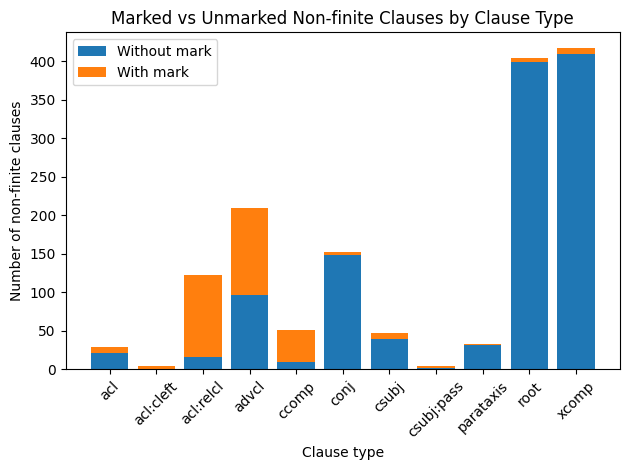

In [199]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_mark_vs_no_mark_nonfinite(stats):
    """
    Plot stacked bar chart of marked vs unmarked non-finite clauses per clause type.

    Parameters
    ----------
    stats : dict
        Nested dictionary with structure:
        stats[clause_type][verbform]["with_mark"]
        stats[clause_type][verbform]["without_mark"]

    The function aggregates counts across verb forms and plots a stacked
    bar chart showing the number of marked vs unmarked non-finite clauses
    for each clause type.
    """

    clause_totals = defaultdict(lambda: {"with": 0, "without": 0})

    # Aggregate counts
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            clause_totals[clause_type]["with"] += counts["with_mark"]
            clause_totals[clause_type]["without"] += counts["without_mark"]

    # Sort clause types for nicer plotting
    clause_types = sorted(clause_totals.keys())

    with_mark = [clause_totals[c]["with"] for c in clause_types]
    without_mark = [clause_totals[c]["without"] for c in clause_types]

    # Plot
    plt.figure()

    plt.bar(clause_types, without_mark, label="Without mark")
    plt.bar(clause_types, with_mark, bottom=without_mark, label="With mark")

    plt.xlabel("Clause type")
    plt.ylabel("Number of non-finite clauses")
    plt.title("Marked vs Unmarked Non-finite Clauses by Clause Type")
    plt.xticks(rotation=45)

    plt.legend()
    plt.tight_layout()

    plt.show()
plot_mark_vs_no_mark_nonfinite(per_deprel_nonfinite_stats)

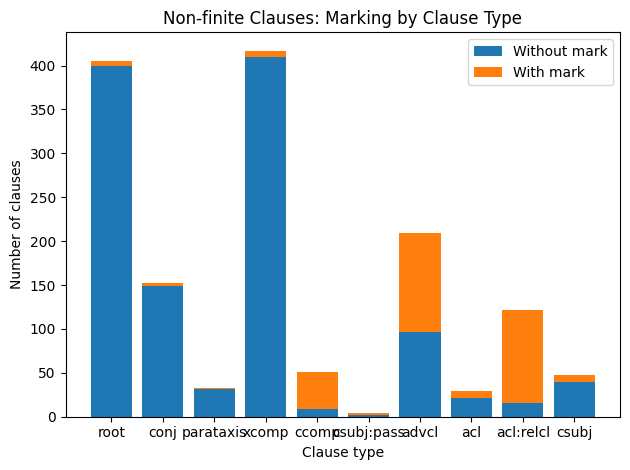

In [198]:
def plot_mark_vs_no_mark_nonfinite(stats):
    """
    Stacked bar chart of marked vs unmarked non-finite clauses per clause type.
    """

    import matplotlib.pyplot as plt
    from collections import defaultdict

    clause_totals = defaultdict(lambda: {"with": 0, "without": 0})

    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            clause_totals[clause_type]["with"] += counts["with_mark"]
            clause_totals[clause_type]["without"] += counts["without_mark"]

    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj:pass",
        "advcl", "acl", "acl:relcl", "csubj"
    ]

    clause_types = [c for c in clause_order if c in clause_totals]

    with_mark = [clause_totals[c]["with"] for c in clause_types]
    without_mark = [clause_totals[c]["without"] for c in clause_types]

    plt.figure()

    plt.bar(clause_types, without_mark, label="Without mark")
    plt.bar(clause_types, with_mark, bottom=without_mark, label="With mark")

    plt.xlabel("Clause type")
    plt.ylabel("Number of clauses")
    plt.title("Non-finite Clauses: Marking by Clause Type")

    plt.legend()
    plt.tight_layout()
    plt.show()

plot_mark_vs_no_mark_nonfinite(per_deprel_nonfinite_stats)

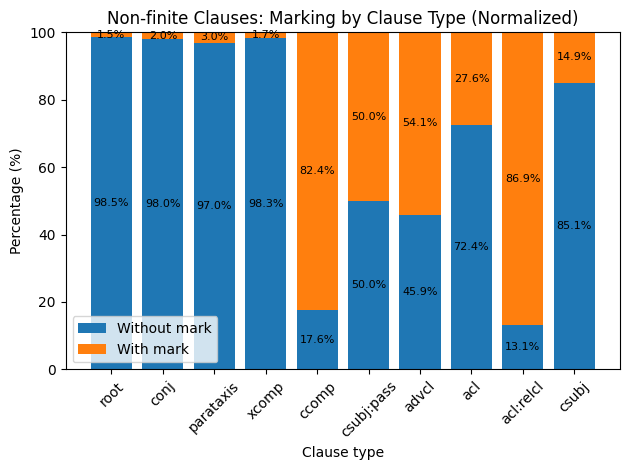

In [196]:
#here I want to normalize the counts by the total number of non-finite clauses per clause type, to get a percentage of marked vs unmarked non-finite clauses for each clause type.
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_mark_vs_no_mark_percentage(stats):
    """
    Plot normalized (percentage) stacked bar chart of marked vs unmarked
    non-finite clauses per clause type.

    Parameters
    ----------
    stats : dict
        Nested dictionary:
        stats[clause_type][verbform]["with_mark"]
        stats[clause_type][verbform]["without_mark"]

    The function aggregates counts across verb forms and normalizes them
    per clause type (each bar sums to 100%).
    """

    clause_totals = defaultdict(lambda: {"with": 0, "without": 0})

    # -------------------
    # Aggregate counts
    # -------------------
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            clause_totals[clause_type]["with"] += counts["with_mark"]
            clause_totals[clause_type]["without"] += counts["without_mark"]

    # -------------------
    # Order (linguistic)
    # -------------------
    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj:pass",
        "advcl", "acl", "acl:relcl", "csubj"
    ]

    clause_types = [c for c in clause_order if c in clause_totals]

    # -------------------
    # Normalize to %
    # -------------------
    with_mark_pct = []
    without_mark_pct = []

    for c in clause_types:
        total = clause_totals[c]["with"] + clause_totals[c]["without"]

        if total == 0:
            with_mark_pct.append(0)
            without_mark_pct.append(0)
        else:
            with_mark_pct.append(clause_totals[c]["with"] / total * 100)
            without_mark_pct.append(clause_totals[c]["without"] / total * 100)

    # -------------------
    # Plot
    # -------------------
    # -------------------
    # Plot
    # -------------------
    plt.figure()

    plt.bar(clause_types, without_mark_pct, label="Without mark")
    plt.bar(clause_types, with_mark_pct, bottom=without_mark_pct, label="With mark")

    plt.xlabel("Clause type")
    plt.ylabel("Percentage (%)")
    plt.title("Non-finite Clauses: Marking by Clause Type (Normalized)")

    plt.ylim(0, 100)
    plt.xticks(rotation=45)

    # -------------------
    # ADD PERCENT LABELS HERE
    # -------------------
    for i, (w, wo) in enumerate(zip(with_mark_pct, without_mark_pct)):
        if wo > 0:
            plt.text(i, wo / 2, f"{wo:.1f}%", ha='center', va='center', fontsize=8)
        if w > 0:
            plt.text(i, wo + w / 2, f"{w:.1f}%", ha='center', va='center', fontsize=8)

    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_mark_vs_no_mark_percentage(per_deprel_nonfinite_stats)

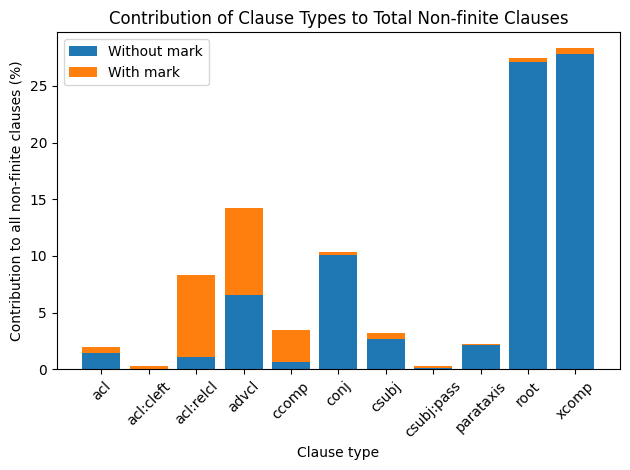

In [183]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_clause_type_contribution(stats):
    """
    Plot the contribution of each clause type to the total number
    of non-finite clauses in the corpus.

    The stacked bars show how much each clause type contributes
    to the total pool of non-finite clauses, split into marked
    and unmarked clauses.

    Parameters
    ----------
    stats : dict
        Nested dictionary:
        stats[clause_type][verbform]["with_mark"]
        stats[clause_type][verbform]["without_mark"]
    """

    clause_totals = defaultdict(lambda: {"with": 0, "without": 0})

    # Aggregate counts
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            clause_totals[clause_type]["with"] += counts["with_mark"]
            clause_totals[clause_type]["without"] += counts["without_mark"]

    # Total number of non-finite clauses
    total_clauses = sum(
        v["with"] + v["without"] for v in clause_totals.values()
    )

    clause_types = sorted(clause_totals.keys())

    with_pct = []
    without_pct = []

    for c in clause_types:
        with_pct.append(clause_totals[c]["with"] / total_clauses * 100)
        without_pct.append(clause_totals[c]["without"] / total_clauses * 100)

    # Plot
    plt.figure()

    plt.bar(clause_types, without_pct, label="Without mark")
    plt.bar(clause_types, with_pct, bottom=without_pct, label="With mark")

    plt.xlabel("Clause type")
    plt.ylabel("Contribution to all non-finite clauses (%)")
    plt.title("Contribution of Clause Types to Total Non-finite Clauses")

    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_clause_type_contribution(per_deprel_nonfinite_stats)

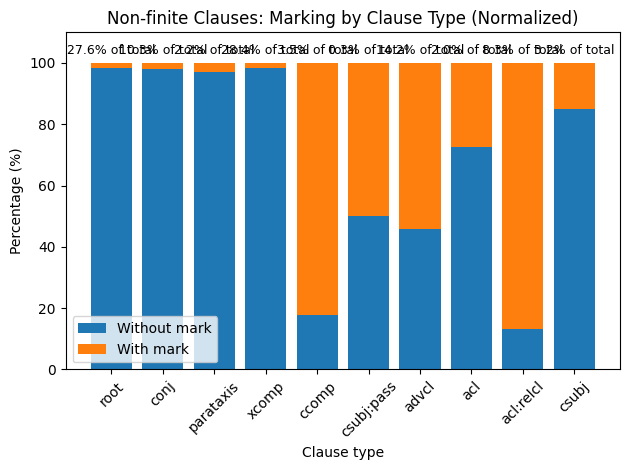

In [195]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_mark_vs_no_mark_percentage(stats):
    """
    Plot normalized (percentage) stacked bar chart of marked vs unmarked
    non-finite clauses per clause type.

    Additionally shows the contribution of each clause type to the total
    number of non-finite clauses above each bar.

    Parameters
    ----------
    stats : dict
        Nested dictionary:
        stats[clause_type][verbform]["with_mark"]
        stats[clause_type][verbform]["without_mark"]
    """

    clause_totals = defaultdict(lambda: {"with": 0, "without": 0})

    # -------------------
    # Aggregate counts
    # -------------------
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            clause_totals[clause_type]["with"] += counts["with_mark"]
            clause_totals[clause_type]["without"] += counts["without_mark"]

    # -------------------
    # Order (linguistic)
    # -------------------
    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj:pass",
        "advcl", "acl", "acl:relcl", "csubj"
    ]

    clause_types = [c for c in clause_order if c in clause_totals]

    # -------------------
    # Normalize to %
    # -------------------
    with_mark_pct = []
    without_mark_pct = []
    contribution_pct = []

    total_nonfinite = sum(
        clause_totals[c]["with"] + clause_totals[c]["without"]
        for c in clause_types
    )

    for c in clause_types:
        total = clause_totals[c]["with"] + clause_totals[c]["without"]

        if total == 0:
            with_mark_pct.append(0)
            without_mark_pct.append(0)
            contribution_pct.append(0)
        else:
            with_mark_pct.append(clause_totals[c]["with"] / total * 100)
            without_mark_pct.append(clause_totals[c]["without"] / total * 100)
            contribution_pct.append(total / total_nonfinite * 100)

    # -------------------
    # Plot
    # -------------------
    plt.figure()

    plt.bar(clause_types, without_mark_pct, label="Without mark")
    plt.bar(clause_types, with_mark_pct, bottom=without_mark_pct, label="With mark")

    plt.xlabel("Clause type")
    plt.ylabel("Percentage (%)")
    plt.title("Non-finite Clauses: Marking by Clause Type (Normalized)")

    plt.ylim(0, 110)
    plt.xticks(rotation=45)


    # -------------------
    # Contribution labels above bars
    # -------------------
    for i, contrib in enumerate(contribution_pct):
        plt.text(i, 103, f"{contrib:.1f}% of total", ha='center', fontsize=9)

    plt.legend()
    plt.tight_layout()
    plt.show()
plot_mark_vs_no_mark_percentage(per_deprel_nonfinite_stats)

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\433779987.py:128: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


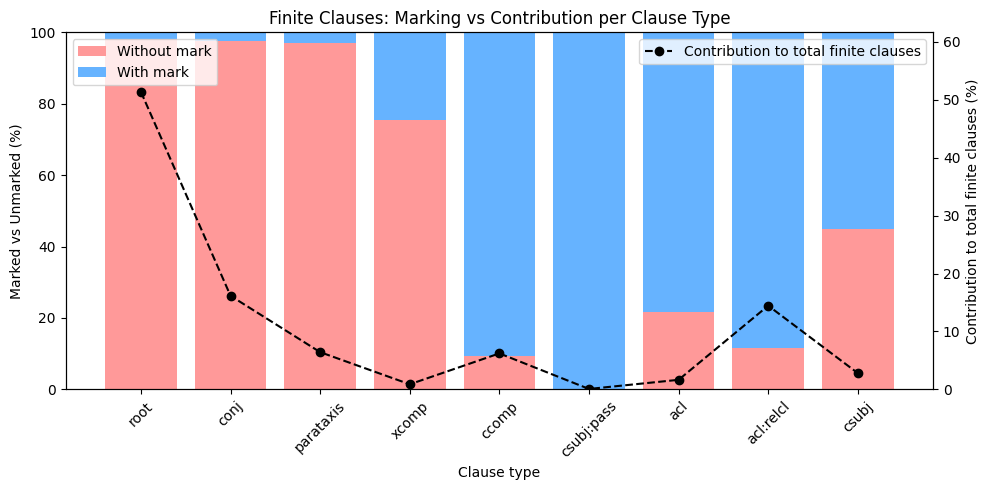

In [190]:
from collections import defaultdict
import matplotlib.pyplot as plt

# ======================================================
# BUILD FINITE CLAUSE STATS
# ======================================================
def build_finite_clause_stats(sentences, excluded_aux_tokens):
    """
    Build finite clause stats from a corpus, including auxiliary constructions
    that were excluded from the non-finite counts.

    Parameters
    ----------
    sentences : list
        List of sentence objects, each with tokens having attributes:
        - id, form, upos, deprel, feats, head
    excluded_aux_tokens : set
        Set of token IDs that were excluded from non-finite counts because they
        were auxiliaries. They should be counted as finite.

    Returns
    -------
    finite_stats : dict
        Nested dictionary:
        finite_stats[clause_type]["with_mark"/"without_mark"]
    """

    target_deprels = {
        "root", "acl:relcl", "acl", "advcl", "acl:cleft",
        "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
    }

    finite_stats = defaultdict(lambda: {"with_mark": 0, "without_mark": 0})

    for sentence in sentences:
        tokens = sentence.get_tokens()
        id_to_token = {t.id: t for t in tokens}
        head_to_dependents = defaultdict(list)
        for t in tokens:
            if t.head is not None:
                head_to_dependents[t.head].append(t)

        for token in tokens:
            if token.upos != "VERB":
                continue

            verbform = token.feats.get("VerbForm") if token.feats else None
            is_finite = verbform == "Fin" or token.id in excluded_aux_tokens
            if not is_finite:
                continue

            # Determine clause type
            deprel = token.deprel.split("|")[-1]
            clause_type = None
            if deprel in target_deprels:
                clause_type = deprel
            elif deprel == "conj":
                head_token = id_to_token.get(token.head)
                if head_token and head_token.deprel.split("|")[-1] in target_deprels:
                    clause_type = "conj"

            if clause_type is None:
                continue

            # Check for mark
            dependents = head_to_dependents.get(token.id, [])
            has_mark = any(dep.deprel == "mark" for dep in dependents)

            if has_mark:
                finite_stats[clause_type]["with_mark"] += 1
            else:
                finite_stats[clause_type]["without_mark"] += 1

    return finite_stats


# ======================================================
# PLOT FINITE CLAUSE STATS
# ======================================================
def plot_finite_mark_vs_no_mark(finite_stats):
    """
    Plot finite clause stats as stacked bar chart with contribution line.

    Parameters
    ----------
    finite_stats : dict
        Nested dictionary: finite_stats[clause_type]["with_mark"/"without_mark"]
    """

    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj:pass", "csubj"
        "advcl", "acl", "acl:relcl", "csubj"
    ]
    clause_types = [c for c in clause_order if c in finite_stats]

    # Compute percentages
    with_mark_pct = []
    without_mark_pct = []
    contribution_pct = []

    total_finite = sum(
        finite_stats[c]["with_mark"] + finite_stats[c]["without_mark"] 
        for c in clause_types
    )

    for c in clause_types:
        total = finite_stats[c]["with_mark"] + finite_stats[c]["without_mark"]
        if total == 0:
            with_mark_pct.append(0)
            without_mark_pct.append(0)
            contribution_pct.append(0)
        else:
            with_mark_pct.append(finite_stats[c]["with_mark"] / total * 100)
            without_mark_pct.append(finite_stats[c]["without_mark"] / total * 100)
            contribution_pct.append(total / total_finite * 100)

    # -------------------
    # Plot
    # -------------------
    fig, ax1 = plt.subplots(figsize=(10, 5))

    ax1.bar(clause_types, without_mark_pct, label="Without mark", color="#ff9999")
    ax1.bar(clause_types, with_mark_pct, bottom=without_mark_pct, label="With mark", color="#66b3ff")
    ax1.set_xlabel("Clause type")
    ax1.set_ylabel("Marked vs Unmarked (%)")
    ax1.set_ylim(0, 100)
    ax1.set_xticklabels(clause_types, rotation=45)

    # Contribution line
    ax2 = ax1.twinx()
    ax2.plot(clause_types, contribution_pct, color='black', marker='o', linestyle='--', label='Contribution to total finite clauses')
    ax2.set_ylabel("Contribution to total finite clauses (%)")
    ax2.set_ylim(0, max(contribution_pct)*1.2)

    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title("Finite Clauses: Marking vs Contribution per Clause Type")
    plt.tight_layout()
    plt.show()

# ======================================================
# MAIN EXECUTION
# ======================================================
# Suppose the corpus is loaded as a list of sentence objects:
sentences = syntactically_annotated_corpus  # corpus variable
excluded_aux_tokens = set()  # populate this with IDs of auxiliaries removed from non-finite counts

# Build finite clause stats
finite_stats = build_finite_clause_stats(sentences, excluded_aux_tokens)

# Plot finite clauses
plot_finite_mark_vs_no_mark(finite_stats)

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\3043605285.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


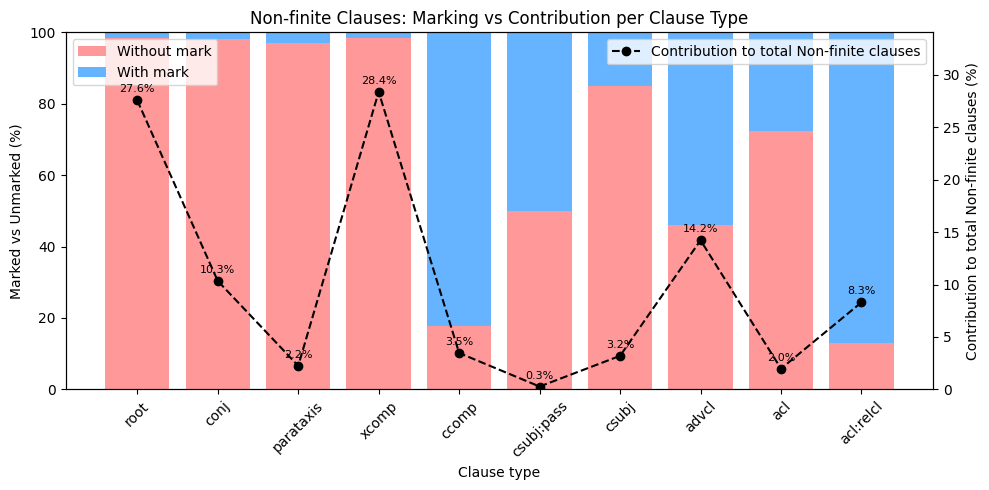

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\3043605285.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


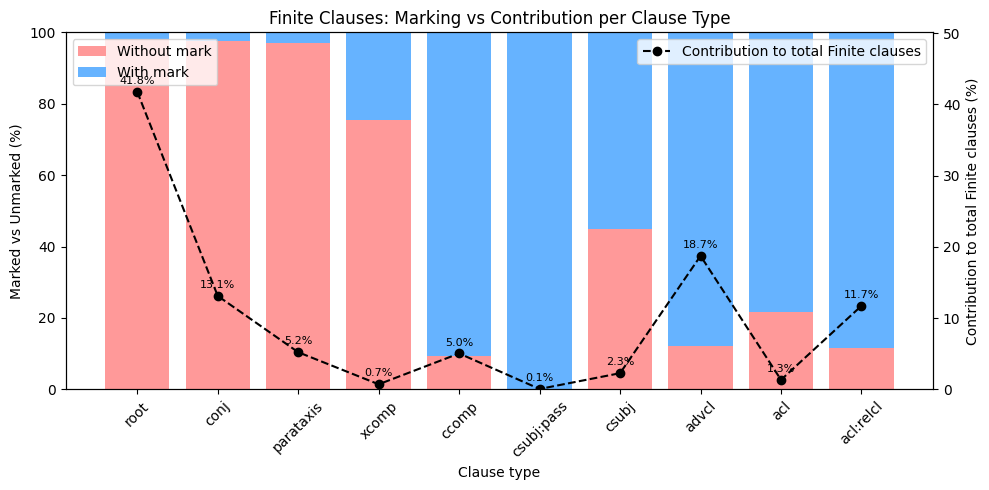

In [194]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_mark_vs_no_mark_with_contrib(stats, clause_type_label="Non-finite"):
    """
    Plot normalized stacked bar chart of marked vs unmarked clauses per clause type,
    with contribution of each clause type to total clauses shown as a line on a secondary y-axis.
    Contribution percentages are annotated above each point.

    Parameters
    ----------
    stats : dict
        Nested dictionary:
        stats[clause_type][verbform]["with_mark"]
        stats[clause_type][verbform]["without_mark"]
    clause_type_label : str
        Label to indicate whether these are "Finite" or "Non-finite" clauses.
    """

    clause_totals = defaultdict(lambda: {"with": 0, "without": 0})

    # Aggregate counts
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            clause_totals[clause_type]["with"] += counts["with_mark"]
            clause_totals[clause_type]["without"] += counts["without_mark"]

    # Linguistic ordering
    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj:pass", "csubj",
        "advcl", "acl", "acl:relcl"
    ]
    clause_types = [c for c in clause_order if c in clause_totals]

    # Normalize for marking percentages
    with_mark_pct = []
    without_mark_pct = []
    contribution_pct = []

    total_clauses = sum(
        clause_totals[c]["with"] + clause_totals[c]["without"]
        for c in clause_types
    )

    for c in clause_types:
        total = clause_totals[c]["with"] + clause_totals[c]["without"]
        if total == 0:
            with_mark_pct.append(0)
            without_mark_pct.append(0)
            contribution_pct.append(0)
        else:
            with_mark_pct.append(clause_totals[c]["with"] / total * 100)
            without_mark_pct.append(clause_totals[c]["without"] / total * 100)
            contribution_pct.append(total / total_clauses * 100)

    # -------------------
    # Plot
    # -------------------
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Stacked bar
    ax1.bar(clause_types, without_mark_pct, label="Without mark", color="#ff9999")
    ax1.bar(clause_types, with_mark_pct, bottom=without_mark_pct, label="With mark", color="#66b3ff")
    ax1.set_xlabel("Clause type")
    ax1.set_ylabel("Marked vs Unmarked (%)")
    ax1.set_ylim(0, 100)
    ax1.set_xticklabels(clause_types, rotation=45)

    # Secondary axis for contribution
    ax2 = ax1.twinx()
    ax2.plot(clause_types, contribution_pct, color='black', marker='o', linestyle='--',
             label=f'Contribution to total {clause_type_label} clauses')
    ax2.set_ylabel(f"Contribution to total {clause_type_label} clauses (%)")
    ax2.set_ylim(0, max(contribution_pct)*1.2)

    # Annotate contribution percentages above each point
    for i, pct in enumerate(contribution_pct):
        ax2.text(i, pct + max(contribution_pct)*0.02, f"{pct:.1f}%", 
                 ha='center', va='bottom', fontsize=8, color='black')

    # Legends
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")

    plt.title(f"{clause_type_label} Clauses: Marking vs Contribution per Clause Type")
    plt.tight_layout()
    plt.show()

from collections import defaultdict

# ======================================================
# BUILD FINITE CLAUSE STATS (NESTED BY VERBFORM)
# ======================================================
def build_finite_clause_stats_nested(sentences, excluded_aux_tokens):
    """
    Build finite clause stats from a corpus, including auxiliary constructions
    that were excluded from the non-finite counts.

    The returned dictionary is nested by verbform, just like non-finite stats:
    stats[clause_type][verbform]["with_mark"/"without_mark"]

    Parameters
    ----------
    sentences : list
        List of sentence objects, each with tokens having attributes:
        - id, form, upos, deprel, feats, head
    excluded_aux_tokens : set
        Set of token IDs that were excluded from non-finite counts because they
        were auxiliaries. They should be counted as finite.

    Returns
    -------
    finite_stats : dict
        Nested dictionary:
        finite_stats[clause_type][verbform]["with_mark"/"without_mark"]
    """

    target_deprels = {
        "root", "acl:relcl", "acl", "advcl", "acl:cleft",
        "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
    }

    finite_stats = defaultdict(lambda: defaultdict(lambda: {"with_mark": 0, "without_mark": 0}))

    for sentence in sentences:
        tokens = sentence.get_tokens()
        id_to_token = {t.id: t for t in tokens}
        head_to_dependents = defaultdict(list)
        for t in tokens:
            if t.head is not None:
                head_to_dependents[t.head].append(t)

        for token in tokens:
            if token.upos != "VERB":
                continue

            verbform = token.feats.get("VerbForm") if token.feats else "Fin"
            # Include auxiliaries removed from non-finite counts
            is_finite = verbform == "Fin" or token.id in excluded_aux_tokens
            if not is_finite:
                continue

            # Determine clause type
            deprel = token.deprel.split("|")[-1]
            clause_type = None
            if deprel in target_deprels:
                clause_type = deprel
            elif deprel == "conj":
                head_token = id_to_token.get(token.head)
                if head_token and head_token.deprel.split("|")[-1] in target_deprels:
                    clause_type = "conj"

            if clause_type is None:
                continue

            # Check for mark
            dependents = head_to_dependents.get(token.id, [])
            has_mark = any(dep.deprel == "mark" for dep in dependents)

            if has_mark:
                finite_stats[clause_type][verbform]["with_mark"] += 1
            else:
                finite_stats[clause_type][verbform]["without_mark"] += 1

    return finite_stats

# Build finite stats (nested)
finite_stats_nested = build_finite_clause_stats_nested(syntactically_annotated_corpus, excluded_aux_tokens)

# Plot non-finite
plot_mark_vs_no_mark_with_contrib(per_deprel_nonfinite_stats, clause_type_label="Non-finite")

# Plot finite
plot_mark_vs_no_mark_with_contrib(finite_stats_nested, clause_type_label="Finite")

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\3403469338.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


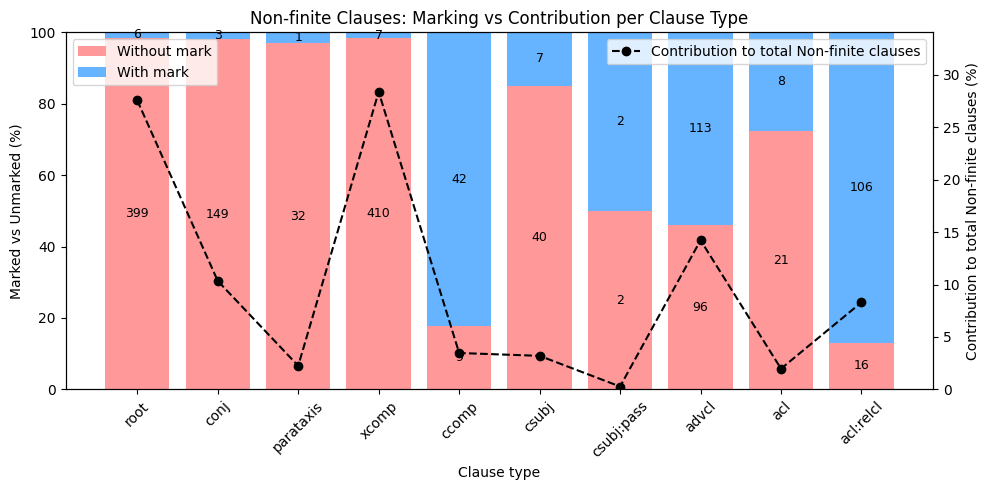

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\3403469338.py:71: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


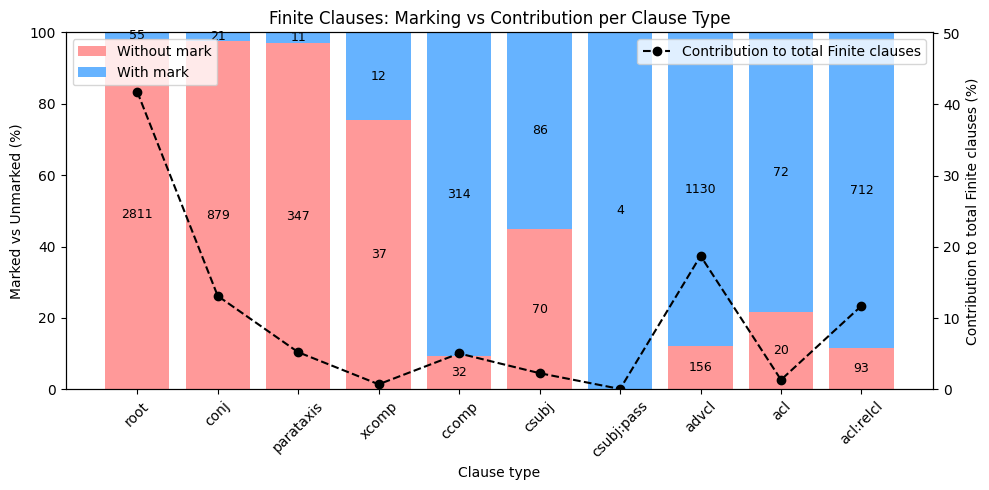

In [188]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_mark_vs_no_mark_with_contrib(stats, clause_type_label="Non-finite"):
    """
    Plot normalized stacked bar chart of marked vs unmarked clauses per clause type,
    with contribution of each clause type to total clauses shown as a line on a secondary y-axis.
    Also adds absolute counts on each segment of the bar.
    
    Works for both finite and non-finite stats.

    Parameters
    ----------
    stats : dict
        Nested dictionary:
        stats[clause_type][verbform] -> {"with_mark": int, "without_mark": int}
    clause_type_label : str
        Label to indicate clause type, e.g., "Finite" or "Non-finite".
    """

    clause_totals = defaultdict(lambda: {"with": 0, "without": 0})

    # Aggregate counts safely
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            if isinstance(counts, dict):
                clause_totals[clause_type]["with"] += counts.get("with_mark", 0)
                clause_totals[clause_type]["without"] += counts.get("without_mark", 0)
            elif isinstance(counts, int):
                clause_totals[clause_type]["with"] += counts
            else:
                raise TypeError(f"Unexpected data type for {clause_type}/{vf}: {type(counts)}")

    # Linguistic ordering
    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj", "csubj:pass",
        "advcl", "acl", "acl:relcl"
    ]
    clause_types = [c for c in clause_order if c in clause_totals]

    # Normalize for marking percentages
    with_mark_pct = []
    without_mark_pct = []
    contribution_pct = []

    total_clauses = sum(clause_totals[c]["with"] + clause_totals[c]["without"] for c in clause_types)

    for c in clause_types:
        total = clause_totals[c]["with"] + clause_totals[c]["without"]
        if total == 0:
            with_mark_pct.append(0)
            without_mark_pct.append(0)
            contribution_pct.append(0)
        else:
            with_mark_pct.append(clause_totals[c]["with"] / total * 100)
            without_mark_pct.append(clause_totals[c]["without"] / total * 100)
            contribution_pct.append(total / total_clauses * 100)

    # -------------------
    # Plot
    # -------------------
    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Stacked bar
    bars_without = ax1.bar(clause_types, without_mark_pct, label="Without mark", color="#ff9999")
    bars_with = ax1.bar(clause_types, with_mark_pct, bottom=without_mark_pct, label="With mark", color="#66b3ff")
    ax1.set_xlabel("Clause type")
    ax1.set_ylabel("Marked vs Unmarked (%)")
    ax1.set_ylim(0, 100)
    ax1.set_xticklabels(clause_types, rotation=45)

    # Add absolute counts inside bars
    for i, c in enumerate(clause_types):
        wo = clause_totals[c]["without"]
        w = clause_totals[c]["with"]

        if wo > 0:
            ax1.text(i, without_mark_pct[i]/2, f"{wo}", ha='center', va='center', fontsize=9, color='black')
        if w > 0:
            ax1.text(i, without_mark_pct[i] + with_mark_pct[i]/2, f"{w}", ha='center', va='center', fontsize=9, color='black')

    # Secondary axis for contribution
    ax2 = ax1.twinx()
    ax2.plot(clause_types, contribution_pct, color='black', marker='o', linestyle='--', 
             label=f'Contribution to total {clause_type_label} clauses')
    ax2.set_ylabel(f"Contribution to total {clause_type_label} clauses (%)")
    ax2.set_ylim(0, max(contribution_pct)*1.2 if contribution_pct else 1)

    # Legends
    ax1.legend(loc="upper left")
    ax2.legend(loc="upper right")
    plt.title(f"{clause_type_label} Clauses: Marking vs Contribution per Clause Type")
    plt.tight_layout()
    plt.show()

# Non-finite
plot_mark_vs_no_mark_with_contrib(per_deprel_nonfinite_stats, clause_type_label="Non-finite")

# Finite
finite_stats_nested = build_finite_clause_stats_nested(syntactically_annotated_corpus, excluded_aux_tokens)
plot_mark_vs_no_mark_with_contrib(finite_stats_nested, clause_type_label="Finite")

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\588518137.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


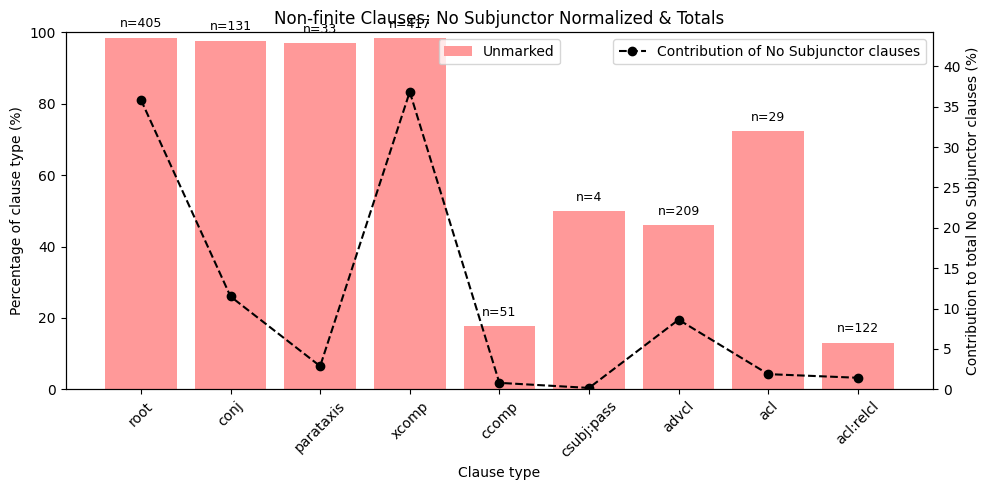

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\588518137.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


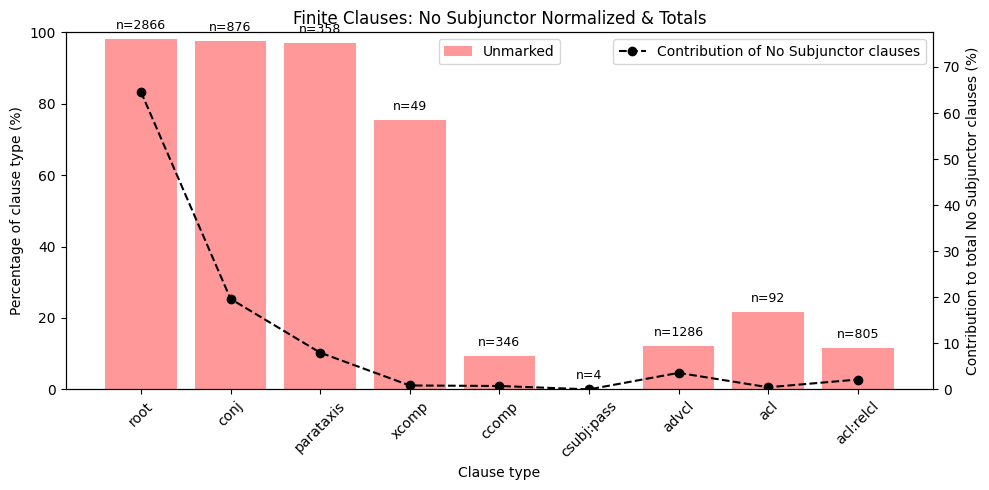

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\588518137.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


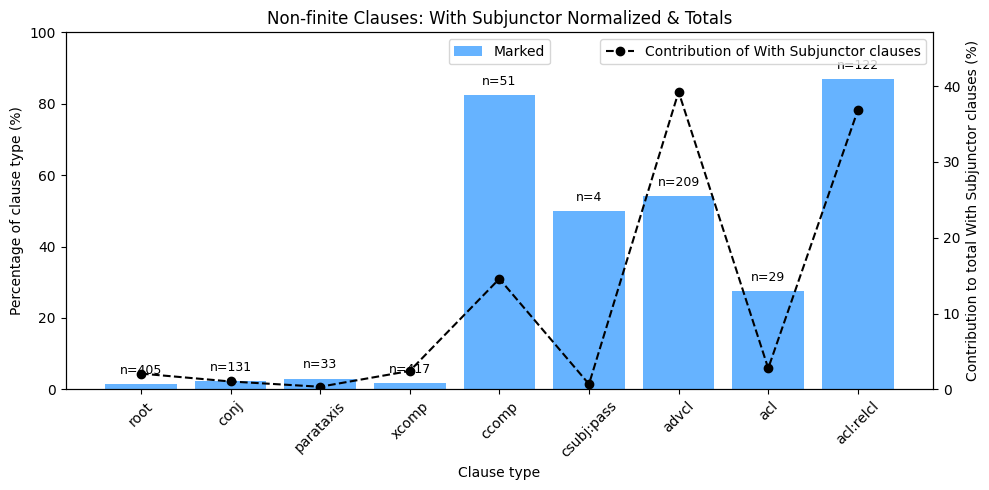

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\588518137.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


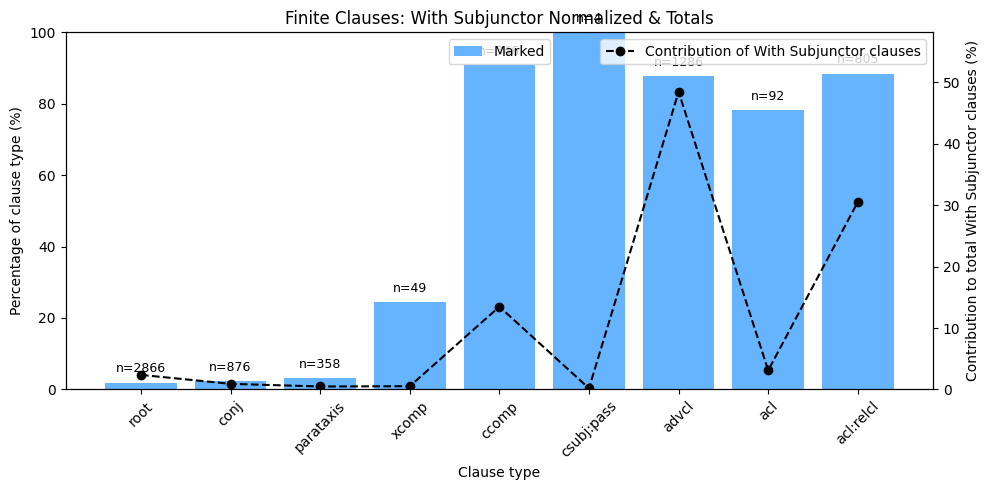

In [134]:
import matplotlib.pyplot as plt
from collections import defaultdict

def plot_clause_type_normalized(stats, clause_type_label="Non-finite", show_marked=False):
    """
    Plot clause type bars normalized to 100% per clause type.
    Shows only unmarked or only marked if show_marked=False/True.
    Absolute total counts (with + without mark) printed above each bar.

    Parameters
    ----------
    stats : dict
        Nested dictionary: stats[clause_type][verbform] -> {"with_mark": int, "without_mark": int}
    clause_type_label : str
        Label for plot, e.g., "Finite" or "Non-finite".
    show_marked : bool
        If True, plot marked clauses only; if False, plot unmarked only.
        Can remove the opposite bar for clarity.
    """

    clause_totals = defaultdict(lambda: {"with_mark": 0, "without_mark": 0})

    # Aggregate counts
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            if isinstance(counts, dict):
                clause_totals[clause_type]["with_mark"] += counts.get("with_mark", 0)
                clause_totals[clause_type]["without_mark"] += counts.get("without_mark", 0)
            elif isinstance(counts, int):
                clause_totals[clause_type]["with_mark"] += counts

    # Order clause types
    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj:pass",
        "advcl", "acl", "acl:relcl"
    ]
    clause_types = [c for c in clause_order if c in clause_totals]

    # Compute normalized percentages per clause type
    normalized_unmarked = []
    normalized_marked = []
    for c in clause_types:
        total = clause_totals[c]["with_mark"] + clause_totals[c]["without_mark"]
        if total == 0:
            normalized_unmarked.append(0)
            normalized_marked.append(0)
        else:
            normalized_unmarked.append(clause_totals[c]["without_mark"] / total * 100)
            normalized_marked.append(clause_totals[c]["with_mark"] / total * 100)

    # ------------------- Plot -------------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    if show_marked:
        # Plot only marked bars
        bars = ax1.bar(clause_types, normalized_marked, color="#66b3ff", label="Marked")
        heights_for_label = normalized_marked
    else:
        # Plot only unmarked bars
        bars = ax1.bar(clause_types, normalized_unmarked, color="#ff9999", label="Unmarked")
        heights_for_label = normalized_unmarked

    ax1.set_xlabel("Clause type")
    ax1.set_ylabel("Percentage of clause type (%)")
    ax1.set_ylim(0, 100)
    ax1.set_xticklabels(clause_types, rotation=45)

    # Add absolute total with n= above each bar
    for i, c in enumerate(clause_types):
        total = clause_totals[c]["with_mark"] + clause_totals[c]["without_mark"]
        if total > 0:
            ax1.text(i, heights_for_label[i] + 2, f"n={total}",
                    ha='center', va='bottom', fontsize=9, color='black')
    # Secondary axis for contribution line
    contribution_pct = [
        clause_totals[c]["without_mark"] / sum(clause_totals[t]["without_mark"] for t in clause_types) * 100
        if sum(clause_totals[t]["without_mark"] for t in clause_types) > 0 else 0
        for c in clause_types
    ] if not show_marked else [
        clause_totals[c]["with_mark"] / sum(clause_totals[t]["with_mark"] for t in clause_types) * 100
        if sum(clause_totals[t]["with_mark"] for t in clause_types) > 0 else 0
        for c in clause_types
    ]

    ax2 = ax1.twinx()
    ax2.plot(clause_types, contribution_pct, color='black', marker='o', linestyle='--',
             label=f'Contribution of {"With Subjunctor" if show_marked else "No Subjunctor"} clauses')
    ax2.set_ylabel(f"Contribution to total {'With Subjunctor' if show_marked else 'No Subjunctor'} clauses (%)")
    ax2.set_ylim(0, max(contribution_pct)*1.2 if contribution_pct else 1)

    ax1.legend(loc="upper center")
    ax2.legend(loc="upper right")
    plt.title(f"{clause_type_label} Clauses: {'With Subjunctor' if show_marked else 'No Subjunctor'} Normalized & Totals")
    plt.tight_layout()
    plt.show()

# Unmarked only
plot_clause_type_normalized(per_deprel_nonfinite_stats, clause_type_label="Non-finite", show_marked=False)
plot_clause_type_normalized(finite_stats_nested, clause_type_label="Finite", show_marked=False)

# Marked only
plot_clause_type_normalized(per_deprel_nonfinite_stats, clause_type_label="Non-finite", show_marked=True)
plot_clause_type_normalized(finite_stats_nested, clause_type_label="Finite", show_marked=True)

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\3062870127.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)
C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\3062870127.py:157: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax2.set_ylim(0, max(contribution_pct)*1.2 if contribution_pct else 1)


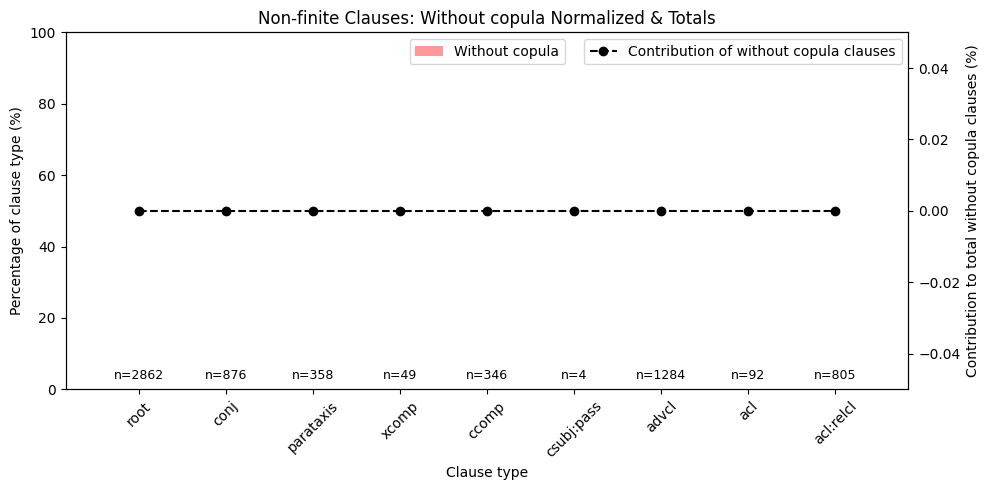

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\3062870127.py:133: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(clause_types, rotation=45)


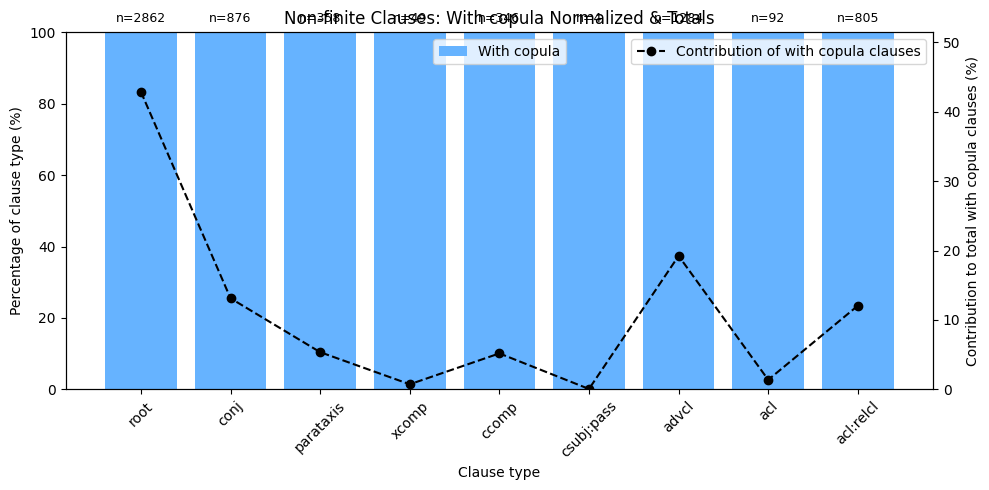

In [ ]:
from collections import defaultdict

def build_clause_stats_with_cop(sentences, excluded_aux_tokens=None):
    """
    Build clause stats where 'cop' dependents are counted instead of 'mark'.
    
    Parameters
    ----------
    sentences : list
        List of sentence objects, each with tokens having attributes:
        - id, form, upos, deprel, feats, head
    excluded_aux_tokens : set, optional
        Set of token IDs that should be treated as finite (like auxiliaries)
    
    Returns
    -------
    clause_stats : dict
        Nested dict: clause_stats[clause_type][verbform] -> {"with_cop": int, "without_cop": int}
    """
    
    target_deprels = {
        "root", "acl:relcl", "acl", "advcl", "acl:cleft",
        "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
    }
    
    clause_stats = defaultdict(lambda: {"with_cop": 0, "without_cop": 0})
    excluded_aux_tokens = excluded_aux_tokens or set()
    
    for sentence in sentences:
        tokens = sentence.get_tokens()
        id_to_token = {t.id: t for t in tokens}
        head_to_dependents = defaultdict(list)
        for t in tokens:
            if t.head is not None:
                head_to_dependents[t.head].append(t)
        
        for token in tokens:
            if token.upos != "VERB":
                continue
            
            verbform = token.feats.get("VerbForm") if token.feats else None
            is_finite = verbform == "Fin" or token.id in excluded_aux_tokens
            if not is_finite:
                continue
            
            # Determine clause type
            deprel = token.deprel.split("|")[-1]
            clause_type = None
            if deprel in target_deprels:
                clause_type = deprel
            elif deprel == "conj":
                head_token = id_to_token.get(token.head)
                if head_token and head_token.deprel.split("|")[-1] in target_deprels:
                    clause_type = "conj"
            
            if clause_type is None:
                continue
            
            # Check for copula dependents
            dependents = head_to_dependents.get(token.id, [])
            has_cop = any(dep.deprel == "cop" for dep in dependents)
            
            if has_cop:
                clause_stats[clause_type]["with_cop"] += 1
            else:
                clause_stats[clause_type]["without_cop"] += 1
    
    return clause_stats

import matplotlib.pyplot as plt
from collections import defaultdict

def plot_clause_type_normalized_cop(stats, clause_type_label="Non-finite", show_cop=False):
    """
    Plot clause type bars normalized to 100% per clause type.
    Shows only clauses with or without cop dependents.
    Absolute total counts (with + without cop) printed above each bar.

    Parameters
    ----------
    stats : dict
        Nested dictionary: stats[clause_type][verbform] -> {"with_cop": int, "without_cop": int}
    clause_type_label : str
        Label for plot, e.g., "Finite" or "Non-finite".
    show_cop : bool
        If True, plot clauses with copula dependents only; if False, plot without copula dependents only.
    """

    clause_totals = defaultdict(lambda: {"with_cop": 0, "without_cop": 0})

    # Aggregate counts
    for clause_type, vf_data in stats.items():
        for vf, counts in vf_data.items():
            if isinstance(counts, dict):
                clause_totals[clause_type]["with_cop"] += counts.get("with_cop", 0)
                clause_totals[clause_type]["without_cop"] += counts.get("without_cop", 0)
            elif isinstance(counts, int):
                clause_totals[clause_type]["with_cop"] += counts

    # Order clause types
    clause_order = [
        "root", "conj", "parataxis",
        "xcomp", "ccomp", "csubj:pass",
        "advcl", "acl", "acl:relcl"
    ]
    clause_types = [c for c in clause_order if c in clause_totals]

    # Compute normalized percentages per clause type
    normalized_without = []
    normalized_with = []
    for c in clause_types:
        total = clause_totals[c]["with_cop"] + clause_totals[c]["without_cop"]
        if total == 0:
            normalized_without.append(0)
            normalized_with.append(0)
        else:
            normalized_without.append(clause_totals[c]["without_cop"] / total * 100)
            normalized_with.append(clause_totals[c]["with_cop"] / total * 100)

    # ------------------- Plot -------------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    if show_cop:
        bars = ax1.bar(clause_types, normalized_with, color="#66b3ff", label="With copula")
        heights_for_label = normalized_with
    else:
        bars = ax1.bar(clause_types, normalized_without, color="#ff9999", label="Without copula")
        heights_for_label = normalized_without

    ax1.set_xlabel("Clause type")
    ax1.set_ylabel("Percentage of clause type (%)")
    ax1.set_ylim(0, 100)
    ax1.set_xticklabels(clause_types, rotation=45)

    # Add absolute total (with + without cop) above each bar
    for i, c in enumerate(clause_types):
        total = clause_totals[c]["with_cop"] + clause_totals[c]["without_cop"]
        if total > 0:
            ax1.text(i, heights_for_label[i] + 2, f"n={total}",
                     ha='center', va='bottom', fontsize=9, color='black')

    # Secondary axis for contribution line (share of clauses across clause types)
    total_selected = sum(
        clause_totals[c]["with_cop"] if show_cop else clause_totals[c]["without_cop"]
        for c in clause_types
    )
    contribution_pct = [
        (clause_totals[c]["with_cop"] if show_cop else clause_totals[c]["without_cop"]) / total_selected * 100
        if total_selected else 0
        for c in clause_types
    ]

    ax2 = ax1.twinx()
    ax2.plot(clause_types, contribution_pct, color='black', marker='o', linestyle='--',
             label=f'Contribution of {"with copula" if show_cop else "without copula"} clauses')
    ax2.set_ylabel(f"Contribution to total {'with copula' if show_cop else 'without copula'} clauses (%)")
    ax2.set_ylim(0, max(contribution_pct)*1.2 if contribution_pct else 1)

    # Legends and title
    ax1.legend(loc="upper center")
    ax2.legend(loc="upper right")
    plt.title(f"{clause_type_label} Clauses: {'With copula' if show_cop else 'Without copula'} Normalized & Totals")
    plt.tight_layout()
    plt.show()

# Build cop-based stats
cop_stats_nested = build_clause_stats_with_cop(syntactically_annotated_corpus, excluded_aux_tokens)

# Plot without copula dependents
plot_clause_type_normalized_cop(cop_stats_nested, clause_type_label="Non-finite", show_cop=False)

# Plot with copula dependents
plot_clause_type_normalized_cop(cop_stats_nested, clause_type_label="Non-finite", show_cop=True)

In [205]:
from collections import Counter, defaultdict

# ======================================================
# TARGET DEPRELS TO CHECK
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# INITIALIZE GLOBAL AND PER-FILE COUNTERS
# ======================================================
global_stats_per_deprel = defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "copula": 0,
    "non_verbal_upos": Counter()
})

global_stats_combined = {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "copula": 0,
    "non_verbal_upos": Counter()
}

per_file_stats = defaultdict(lambda: defaultdict(lambda: {
    "total": 0,
    "verbal": 0,
    "non_verbal": 0,
    "copula": 0,
    "non_verbal_upos": Counter()
}))

# ======================================================
# ITERATE OVER CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    # Build head -> dependents mapping
    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel or token.form in {"_", "__"}:
            continue

        deprel = token.deprel.split("|")[-1]
        clause_type = None

        # Regular clause heads
        if deprel in target_deprels:
            clause_type = deprel

        # Restricted conj clause logic
        elif deprel == "conj":
            head_token = id_to_token.get(token.head)
            if head_token and head_token.deprel:
                head_deprel = head_token.deprel.split("|")[-1]
                # Condition 1: head must be a clause head
                if head_deprel in target_deprels:
                    dependents = head_to_dependents.get(token.id, [])
                    # Filter out trivial dependents
                    filtered_dependents = [
                        dep for dep in dependents
                        if dep.deprel and dep.deprel.split("|")[-1] not in {"det", "case", "amod", "nmod"}
                    ]
                    # Condition 2: at least 3 meaningful dependents
                    if len(filtered_dependents) >= 3:
                        clause_type = "conj"

        if clause_type is None:
            continue

        # --------------------------------------------------
        # SCONJ FILTER (skip for root and conj)
        # --------------------------------------------------
        if clause_type not in {"root", "conj"}:
            dependents = head_to_dependents.get(token.id, [])
            has_sconj_dependent = any(dep.upos == "SCONJ" for dep in dependents)
            if not has_sconj_dependent:
                continue

        # -------------------
        # Check for copula
        # -------------------
        dependents = head_to_dependents.get(token.id, [])
        has_cop = any(dep.deprel == "cop" for dep in dependents)

        # -------------------
        # Update statistics
        # -------------------
        global_stats_per_deprel[clause_type]["total"] += 1
        global_stats_combined["total"] += 1
        per_file_stats[text_id][clause_type]["total"] += 1

        if token.upos == "VERB":
            global_stats_per_deprel[clause_type]["verbal"] += 1
            global_stats_combined["verbal"] += 1
            per_file_stats[text_id][clause_type]["verbal"] += 1
        else:
            global_stats_per_deprel[clause_type]["non_verbal"] += 1
            global_stats_combined["non_verbal"] += 1
            per_file_stats[text_id][clause_type]["non_verbal"] += 1

            global_stats_per_deprel[clause_type]["non_verbal_upos"][token.upos] += 1
            global_stats_combined["non_verbal_upos"][token.upos] += 1
            per_file_stats[text_id][clause_type]["non_verbal_upos"][token.upos] += 1

        if has_cop:
            global_stats_per_deprel[clause_type]["copula"] += 1
            global_stats_combined["copula"] += 1
            per_file_stats[text_id][clause_type]["copula"] += 1

# ======================================================
# GLOBAL SUMMARY
# ======================================================
print("\n=== Nominal, Verbal, and Copula Clauses ===\n")

total = global_stats_combined["total"]
verbal = global_stats_combined["verbal"]
non_verbal = global_stats_combined["non_verbal"]
copula = global_stats_combined["copula"]

print(f"Total clauses: {total}")
print(f"Verbal clauses: {verbal} ({verbal / total * 100:.2f}%)")
print(f"Non-verbal clauses: {non_verbal} ({non_verbal / total * 100:.2f}%)")
print(f"Copula clauses: {copula} ({copula / total * 100:.2f}%)")

print("\nDistribution of UPOS of non-verbal clause heads:")
for upos, count in global_stats_combined["non_verbal_upos"].most_common():
    print(f"  {upos:<10} {count}")

# ======================================================
# GLOBAL PER-DEPREL RESULTS
# ======================================================
print("\n=== Clause Types by Dependency Relation ===\n")

deprel_labels = {
    "root": "Main Clauses",
    "acl:relcl": "Relative Clauses",
    "acl": "Adjectival Clauses",
    "advcl": "Adverbial Clauses",
    "acl:cleft": "Cleft Constructions",
    "xcomp": "Open Clausal Complements",
    "ccomp": "Clausal Complements",
    "csubj": "Clausal Subjects",
    "csubj:pass": "Passive Clausal Subjects",
    "parataxis": "Parataxis",
    "conj": "Coordinated Clauses"
}

for deprel, stats in global_stats_per_deprel.items():
    label = deprel_labels.get(deprel, deprel)
    total = stats["total"]
    verbal = stats["verbal"]
    non_verbal = stats["non_verbal"]
    copula = stats["copula"]

    print(f"\nClause type: {label} ({deprel})")
    print(f"Total clauses: {total}")
    print(f"Verbal clauses: {verbal} ({verbal / total * 100:.2f}%)")
    print(f"Non-verbal clauses: {non_verbal} ({non_verbal / total * 100:.2f}%)")
    print(f"Copula clauses: {copula} ({copula / total * 100:.2f}%)")

    print("UPOS of non-verbal clause heads:")
    for upos, count in stats["non_verbal_upos"].most_common():
        print(f"  {upos:<10} {count}")

# ======================================================
# PER-FILE RESULTS
# ======================================================
print("\n=== Per-File Clause Statistics ===\n")

for text_id, deprel_data in sorted(per_file_stats.items()):
    print(f"\nFile: {text_id}")
    for deprel, stats in deprel_data.items():
        label = deprel_labels.get(deprel, deprel)
        total = stats["total"]
        verbal = stats["verbal"]
        non_verbal = stats["non_verbal"]
        copula = stats["copula"]

        print(f"\n  Clause type: {label} ({deprel})")
        print(f"  Total clauses: {total}")
        print(f"  Verbal clauses: {verbal} ({verbal / total * 100:.2f}%)")
        print(f"  Non-verbal clauses: {non_verbal} ({non_verbal / total * 100:.2f}%)")
        print(f"  Copula clauses: {copula} ({copula / total * 100:.2f}%)")

        print("  UPOS of non-verbal clause heads:")
        for upos, count in stats["non_verbal_upos"].most_common():
            print(f"    {upos:<10} {count}")
    print("=" * 80)


=== Nominal, Verbal, and Copula Clauses ===

Total clauses: 9824
Verbal clauses: 6631 (67.50%)
Non-verbal clauses: 3193 (32.50%)
Copula clauses: 628 (6.39%)

Distribution of UPOS of non-verbal clause heads:
  NOUN       1293
  ADJ        1072
  PRON       320
  ADV        219
  PROPN      170
  AUX        47
  DET        28
  NUM        23
  PART       12
  ADP        4
  _          3
  Noun       1
  SCONJ      1

=== Clause Types by Dependency Relation ===


Clause type: Main Clauses (root)
Total clauses: 5283
Verbal clauses: 3425 (64.83%)
Non-verbal clauses: 1858 (35.17%)
Copula clauses: 286 (5.41%)
UPOS of non-verbal clause heads:
  NOUN       773
  ADJ        608
  PRON       206
  ADV        132
  PROPN      81
  DET        17
  AUX        16
  NUM        15
  PART       4
  _          3
  ADP        2
  Noun       1

Clause type: Clausal Complements (ccomp)
Total clauses: 592
Verbal clauses: 378 (63.85%)
Non-verbal clauses: 214 (36.15%)
Copula clauses: 63 (10.64%)
UPOS of non-v

<Figure size 1200x600 with 0 Axes>

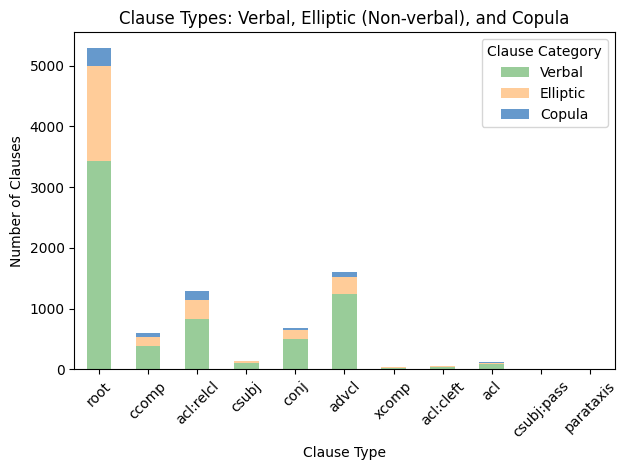

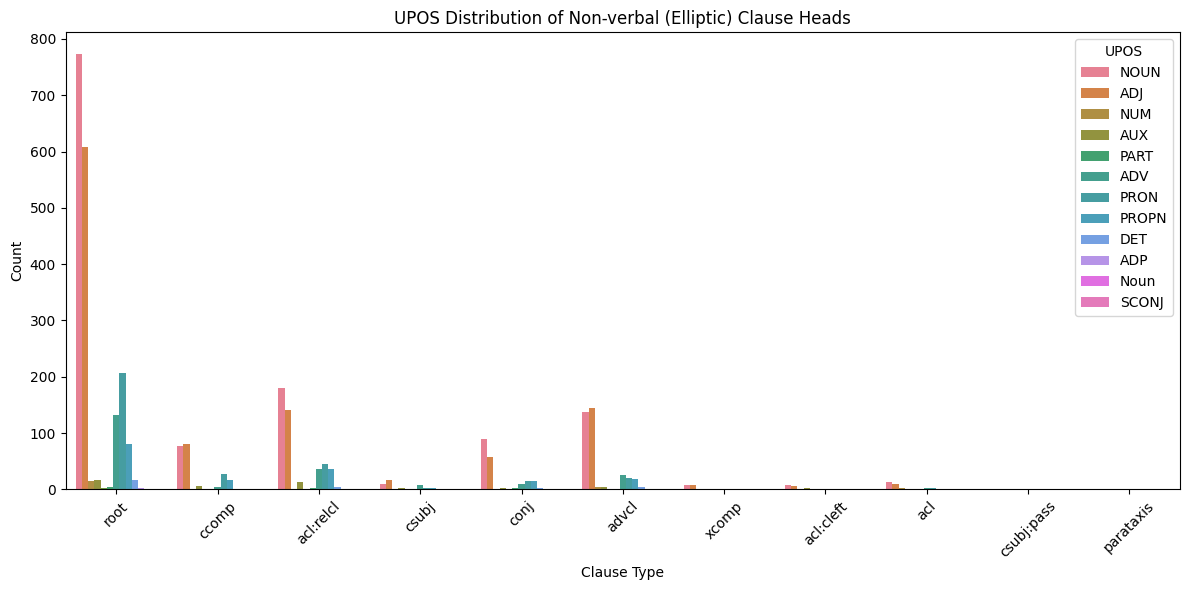

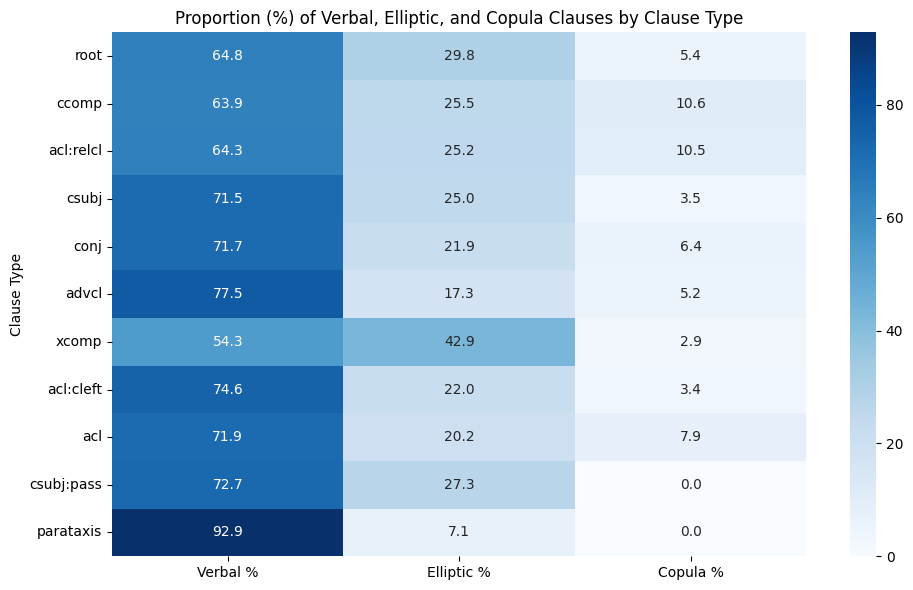

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ======================================================
# Prepare DataFrame for clause type overview
# ======================================================
data = []
for deprel, stats in global_stats_per_deprel.items():
    # Elliptic = non-verbal minus copula (non-verbal clauses that are NOT copula)
    elliptic = stats["non_verbal"] - stats["copula"]
    data.append({
        "Clause": deprel,
        "Verbal": stats["verbal"],
        "Elliptic": max(elliptic, 0),
        "Copula": stats["copula"]
    })

df = pd.DataFrame(data).set_index("Clause")

# ======================================================
# Stacked Bar Chart: Verbal vs Elliptic vs Copula
# ======================================================
plt.figure(figsize=(12,6))
df[['Verbal', 'Elliptic', 'Copula']].plot(
    kind='bar', stacked=True, color=['#99CC99', '#FFCC99', '#6699CC']
)
plt.title("Clause Types: Verbal, Elliptic (Non-verbal), and Copula")
plt.ylabel("Number of Clauses")
plt.xlabel("Clause Type")
plt.xticks(rotation=45)
plt.legend(title="Clause Category")
plt.tight_layout()
plt.show()

# ======================================================
# UPOS Distribution of Non-verbal (Elliptic) Clause Heads
# ======================================================
upos_data = []
for deprel, stats in global_stats_per_deprel.items():
    for upos, count in stats["non_verbal_upos"].items():
        # Optional: skip copula if strictly elliptic
        # For now, include all non-verbal heads
        upos_data.append({"Clause": deprel, "UPOS": upos, "Count": count})

upos_df = pd.DataFrame(upos_data)

plt.figure(figsize=(12,6))
sns.barplot(data=upos_df, x="Clause", y="Count", hue="UPOS")
plt.title("UPOS Distribution of Non-verbal (Elliptic) Clause Heads")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Clause Type")
plt.legend(title="UPOS")
plt.tight_layout()
plt.show()

# ======================================================
# Optional: Heatmap of Copula vs Elliptic Proportion
# ======================================================
heat_data = []
for deprel, stats in global_stats_per_deprel.items():
    total = stats["total"]
    copula = stats["copula"]
    elliptic = stats["non_verbal"] - copula
    verbal = stats["verbal"]
    heat_data.append({
        "Clause": deprel,
        "Verbal %": verbal / total * 100 if total else 0,
        "Elliptic %": max(elliptic / total * 100,0) if total else 0,
        "Copula %": copula / total * 100 if total else 0
    })

heat_df = pd.DataFrame(heat_data).set_index("Clause")

plt.figure(figsize=(10,6))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="Blues")
plt.title("Proportion (%) of Verbal, Elliptic, and Copula Clauses by Clause Type")
plt.ylabel("Clause Type")
plt.tight_layout()
plt.show()

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\1865834425.py:31: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ax.text(j, bottom[j] + df_percent[col][j]/2, str(val), ha='center', va='center', color='white', fontsize=10, fontweight='bold')


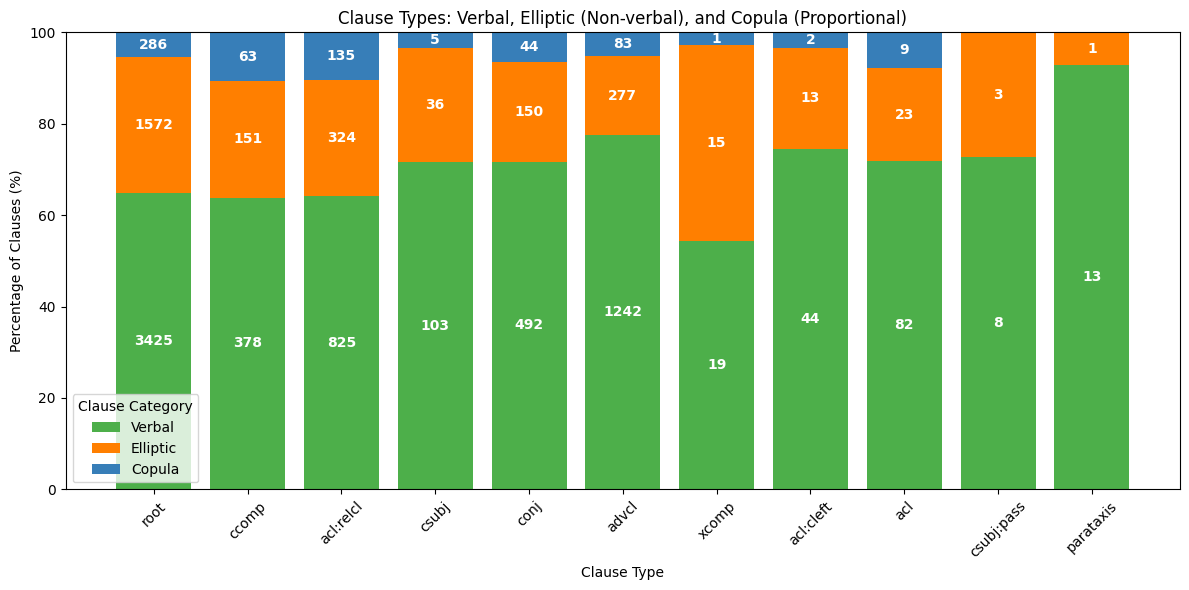

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Prepare DataFrame (elliptic = non-verbal minus copula)
data = []
for deprel, stats in global_stats_per_deprel.items():
    elliptic = stats["non_verbal"] - stats["copula"]
    data.append({
        "Clause": deprel,
        "Verbal": stats["verbal"],
        "Elliptic": max(elliptic, 0),
        "Copula": stats["copula"]
    })

df = pd.DataFrame(data).set_index("Clause")

# Convert to percentages
df_percent = df.div(df.sum(axis=1), axis=0) * 100

# Plot
fig, ax = plt.subplots(figsize=(12,6))
colors = ['#4daf4a', '#ff7f00', '#377eb8']  # Verbal, Elliptic, Copula

bottom = np.zeros(len(df))
for i, col in enumerate(df_percent.columns):
    ax.bar(df_percent.index, df_percent[col], bottom=bottom, color=colors[i], label=col)
    # Add absolute numbers on the bar segments
    for j, val in enumerate(df[col]):
        if val > 0:  # Only label non-zero segments
            ax.text(j, bottom[j] + df_percent[col][j]/2, str(val), ha='center', va='center', color='white', fontsize=10, fontweight='bold')
    bottom += df_percent[col]

ax.set_ylabel("Percentage of Clauses (%)")
ax.set_xlabel("Clause Type")
ax.set_title("Clause Types: Verbal, Elliptic (Non-verbal), and Copula (Proportional)")
ax.legend(title="Clause Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

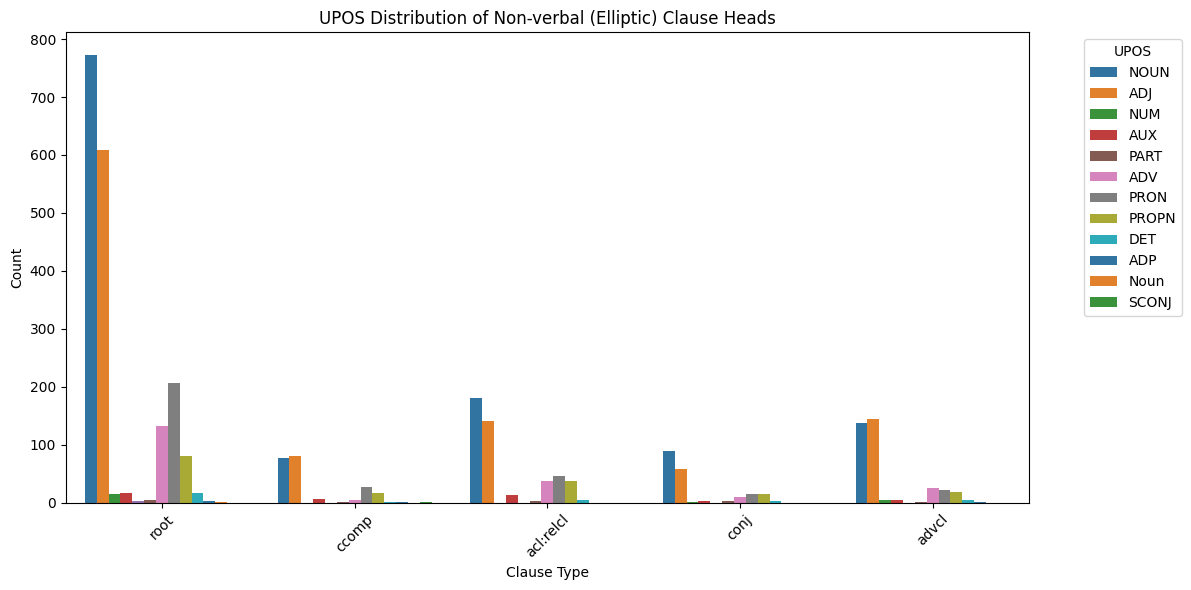

In [208]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

exclude_clauses = {"csubj", "csubj:pass", "parataxis", "xcomp", "acl:cleft", "acl"}

# Prepare UPOS data
upos_data = []
for deprel, stats in global_stats_per_deprel.items():
    if deprel in exclude_clauses:
        continue

    for upos, count in stats["non_verbal_upos"].items():
        upos_data.append({
            "Clause": deprel,
            "UPOS": upos,
            "Count": count
        })

upos_df = pd.DataFrame(upos_data)

plt.figure(figsize=(12,6))

palette = sns.color_palette("tab10", n_colors=upos_df['UPOS'].nunique())

sns.barplot(
    data=upos_df,
    x="Clause",
    y="Count",
    hue="UPOS",
    palette=palette
)

plt.title("UPOS Distribution of Non-verbal (Elliptic) Clause Heads")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.xlabel("Clause Type")
plt.legend(title="UPOS", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\1857993347.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=csubj_df, x="UPOS", y="Count", palette="tab10")


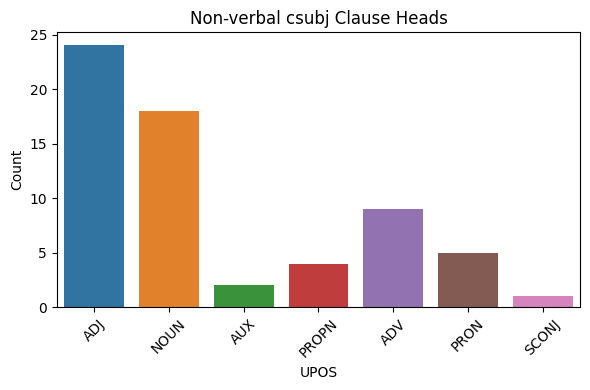

In [210]:
csubj_data = []
for upos, count in debug_csubj["csubj"]["upos"].items():
    csubj_data.append({"UPOS": upos, "Count": count})

csubj_df = pd.DataFrame(csubj_data)

plt.figure(figsize=(6,4))
sns.barplot(data=csubj_df, x="UPOS", y="Count", palette="tab10")
plt.title("Non-verbal csubj Clause Heads")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [223]:
from collections import Counter, defaultdict

# ======================================================
# TARGET CLAUSE DEPRELS
# ======================================================
target_deprels = {
    "root", "acl:relcl", "acl", "advcl", "acl:cleft",
    "xcomp", "ccomp", "csubj", "csubj:pass", "parataxis"
}

# ======================================================
# GLOBAL NEGATION STATS
# ======================================================
neg_stats_global = {
    "verbal": {"total": 0, "negated": 0, "upos": Counter()},
    "copula": {"total": 0, "negated": 0, "upos": Counter()},
    "elliptic": {"total": 0, "negated": 0, "upos": Counter()}
}

# ======================================================
# PER FILE NEGATION STATS
# ======================================================
neg_stats_per_file = defaultdict(lambda: {
    "verbal_total": 0, "verbal_neg": 0, "verbal_upos": Counter(),
    "copula_total": 0, "copula_neg": 0, "copula_upos": Counter(),
    "elliptic_total": 0, "elliptic_neg": 0, "elliptic_upos": Counter()
})

# ======================================================
# ITERATE THROUGH CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    sentence_id = sentence.metadata.get("SENTENCE ID", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    # Map heads to their dependents
    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    # IDs of all clause heads (to exclude from negation check)
    clause_head_ids = {tok.id for tok in tokens if tok.deprel and tok.deprel.split("|")[-1] in target_deprels}

    for token in tokens:
        if not token.deprel:
            continue

        deprel = token.deprel.split("|")[-1]
        if deprel not in target_deprels and deprel != "conj":
            continue

        dependents = head_to_dependents.get(token.id, [])
        has_cop = any(dep.deprel == "cop" for dep in dependents)

        # -------------------------------
        # Determine clause category
        # -------------------------------
        if token.upos == "VERB":
            clause_category = "verbal"
        else:
            clause_category = "copula" if has_cop else "elliptic"

        # Update totals
        neg_stats_global[clause_category]["total"] += 1
        if clause_category == "verbal":
            neg_stats_per_file[text_id]["verbal_total"] += 1
        elif clause_category == "copula":
            neg_stats_per_file[text_id]["copula_total"] += 1
        else:
            neg_stats_per_file[text_id]["elliptic_total"] += 1

        # -------------------------------
        # Check negation (exclude other clause heads)
        # -------------------------------
        clause_negated = False
        for dep in dependents:
            if dep.id in clause_head_ids:
                continue  # skip dependents that are heads of another clause

            feats = dep.feats if dep.feats else {}
            neg_feature = (
                feats.get("Polarity") == "Neg"
                or feats.get("Neg") == "Yes"
                or dep.deprel == "neg"
            )
            if neg_feature:
                clause_negated = True
                neg_stats_global[clause_category]["upos"][dep.upos] += 1
                if clause_category == "verbal":
                    neg_stats_per_file[text_id]["verbal_upos"][dep.upos] += 1
                elif clause_category == "copula":
                    neg_stats_per_file[text_id]["copula_upos"][dep.upos] += 1
                else:
                    neg_stats_per_file[text_id]["elliptic_upos"][dep.upos] += 1

        # Update negated counts
        if clause_negated:
            neg_stats_global[clause_category]["negated"] += 1
            if clause_category == "verbal":
                neg_stats_per_file[text_id]["verbal_neg"] += 1
            elif clause_category == "copula":
                neg_stats_per_file[text_id]["copula_neg"] += 1
            else:
                neg_stats_per_file[text_id]["elliptic_neg"] += 1

# ======================================================
# PRINT GLOBAL RESULTS
# ======================================================
print("\n=== GLOBAL NEGATION: VERBAL, COPULA, ELLIPTIC ===\n")
for clause_type, stats in neg_stats_global.items():
    total = stats["total"]
    negated = stats["negated"]
    ratio = (negated / total * 100) if total else 0

    print(f"{clause_type.upper()} CLAUSES")
    print(f"Total: {total}")
    print(f"Negated: {negated}")
    print(f"Ratio negated: {ratio:.2f}%")
    print(f"UPOS of negation tokens:")
    for upos, count in stats["upos"].most_common():
        print(f"  {upos:<10} {count}")
    print()

# ======================================================
# PRINT PER FILE RESULTS
# ======================================================
print("\n=== PER FILE NEGATION STATISTICS ===\n")
for text_id, stats in sorted(neg_stats_per_file.items()):
    print(f"\nFile: {text_id}")
    for clause_category in ["verbal", "copula", "elliptic"]:
        total = stats[f"{clause_category}_total"]
        negated = stats[f"{clause_category}_neg"]
        ratio = (negated / total * 100) if total else 0
        upos_counter = stats[f"{clause_category}_upos"]

        print(f"{clause_category.capitalize()} clauses: {total}")
        print(f"{clause_category.capitalize()} negated: {negated} ({ratio:.2f}%)")
        print(f"{clause_category.capitalize()} negation UPOS:")
        for upos, count in upos_counter.most_common():
            print(f"  {upos:<10} {count}")
        print("-" * 30)


=== GLOBAL NEGATION: VERBAL, COPULA, ELLIPTIC ===

VERBAL CLAUSES
Total: 8850
Negated: 8
Ratio negated: 0.09%
UPOS of negation tokens:
  VERB       7
  ADV        1

COPULA CLAUSES
Total: 726
Negated: 7
Ratio negated: 0.96%
UPOS of negation tokens:
  AUX        7

ELLIPTIC CLAUSES
Total: 9262
Negated: 1
Ratio negated: 0.01%
UPOS of negation tokens:
  VERB       1


=== PER FILE NEGATION STATISTICS ===


File: AOD-K20_mptf.conllu
Verbal clauses: 84
Verbal negated: 1 (1.19%)
Verbal negation UPOS:
  VERB       1
------------------------------
Copula clauses: 14
Copula negated: 0 (0.00%)
Copula negation UPOS:
------------------------------
Elliptic clauses: 130
Elliptic negated: 0 (0.00%)
Elliptic negation UPOS:
------------------------------

File: Col-TD2-2_mptf.conllu
Verbal clauses: 2
Verbal negated: 0 (0.00%)
Verbal negation UPOS:
------------------------------
Copula clauses: 0
Copula negated: 0 (0.00%)
Copula negation UPOS:
------------------------------
Elliptic clauses: 2
Ellipti

We do not have many negative sentences in the syntactically annotated corpus.

In [224]:
from collections import defaultdict, Counter

# ======================================================
# COPULA NEGATION AND FEATS STATS
# ======================================================
copula_neg_feats_global = Counter()  # Counts of feats combinations
copula_neg_feats_per_file = defaultdict(Counter)

# ======================================================
# ITERATE THROUGH CORPUS
# ======================================================
for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    sentence_id = sentence.metadata.get("SENTENCE ID", "unknown")
    tokens = sentence.get_tokens()

    head_to_dependents = defaultdict(list)
    id_to_token = {}

    for token in tokens:
        id_to_token[token.id] = token
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    # IDs of all clause heads (to exclude from negation check)
    clause_head_ids = {tok.id for tok in tokens if tok.deprel and tok.deprel.split("|")[-1] in target_deprels}

    for token in tokens:
        if not token.deprel:
            continue

        deprel = token.deprel.split("|")[-1]
        if deprel not in target_deprels:
            continue

        dependents = head_to_dependents.get(token.id, [])
        has_cop = any(dep.deprel == "cop" for dep in dependents)

        # Only focus on copula clauses
        if token.upos == "VERB":
            continue
        if not has_cop:
            continue

        # -------------------------------
        # Check negation among dependents
        # -------------------------------
        for dep in dependents:
            if dep.id in clause_head_ids:
                continue  # skip other clause heads

            feats = dep.feats if dep.feats else {}
            neg_feature = (
                feats.get("Polarity") == "Neg"
                or feats.get("Neg") == "Yes"
                or dep.deprel == "neg"
            )
            if neg_feature:
                # Convert feats dict to sorted tuple for counting
                feats_tuple = tuple(sorted(feats.items()))
                copula_neg_feats_global[feats_tuple] += 1
                copula_neg_feats_per_file[text_id][feats_tuple] += 1

# ======================================================
# PRINT GLOBAL FEATS VARIATION
# ======================================================
print("\n=== COPULA CLAUSES NEGATION FEATS (GLOBAL) ===\n")
for feats_tuple, count in copula_neg_feats_global.most_common():
    feats_dict = dict(feats_tuple)
    print(f"Feats: {feats_dict} | Count: {count}")

# ======================================================
# PRINT PER FILE FEATS VARIATION
# ======================================================
print("\n=== COPULA CLAUSES NEGATION FEATS (PER FILE) ===\n")
for text_id, feats_counter in sorted(copula_neg_feats_per_file.items()):
    print(f"\nFile: {text_id}")
    for feats_tuple, count in feats_counter.most_common():
        feats_dict = dict(feats_tuple)
        print(f"Feats: {feats_dict} | Count: {count}")


=== COPULA CLAUSES NEGATION FEATS (GLOBAL) ===

Feats: {'Mood': 'Ind', 'Number': 'Sing', 'Person': '3', 'Polarity': 'Neg', 'Subcat': 'Intr', 'Tense': 'Pres', 'VerbForm': 'Fin', 'VerbType': 'Cop'} | Count: 6

=== COPULA CLAUSES NEGATION FEATS (PER FILE) ===


File: DMX-L19_mptf.conllu
Feats: {'Mood': 'Ind', 'Number': 'Sing', 'Person': '3', 'Polarity': 'Neg', 'Subcat': 'Intr', 'Tense': 'Pres', 'VerbForm': 'Fin', 'VerbType': 'Cop'} | Count: 1

File: Dk5-B_mptf.conllu
Feats: {'Mood': 'Ind', 'Number': 'Sing', 'Person': '3', 'Polarity': 'Neg', 'Subcat': 'Intr', 'Tense': 'Pres', 'VerbForm': 'Fin', 'VerbType': 'Cop'} | Count: 2

File: GBd-TD1_mptf.conllu
Feats: {'Mood': 'Ind', 'Number': 'Sing', 'Person': '3', 'Polarity': 'Neg', 'Subcat': 'Intr', 'Tense': 'Pres', 'VerbForm': 'Fin', 'VerbType': 'Cop'} | Count: 2

File: MHD-MHDC_mptf.conllu
Feats: {'Mood': 'Ind', 'Number': 'Sing', 'Person': '3', 'Polarity': 'Neg', 'Subcat': 'Intr', 'Tense': 'Pres', 'VerbForm': 'Fin', 'VerbType': 'Cop'} | Count: 

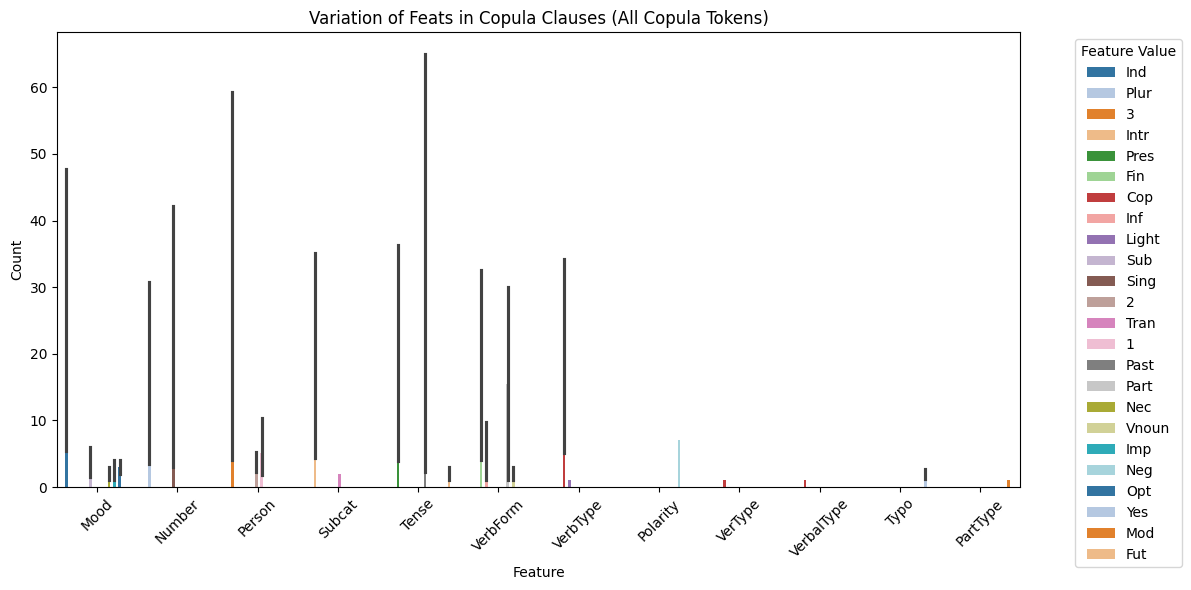

In [226]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# ======================================================
# COLLECT FEATS FROM ALL COPULA TOKENS
# ======================================================
copula_feats_global = Counter()
copula_feats_per_file = defaultdict(Counter)

for sentence in syntactically_annotated_corpus:
    text_id = sentence.metadata.get("source_filename", "unknown")
    tokens = sentence.get_tokens()

    # Map head -> dependents
    head_to_dependents = defaultdict(list)
    for token in tokens:
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel:
            continue

        # Clause categories
        dependents = head_to_dependents.get(token.id, [])
        has_cop = any(dep.deprel == "cop" for dep in dependents)
        if token.upos != "VERB" and has_cop:
            # This is a copula clause
            for dep in dependents:
                if dep.deprel == "cop" and dep.feats:
                    feats_tuple = tuple(sorted(dep.feats.items()))
                    copula_feats_global[feats_tuple] += 1
                    copula_feats_per_file[text_id][feats_tuple] += 1

# ======================================================
# CONVERT GLOBAL FEATS TO DATAFRAME
# ======================================================
records = []
for feats_tuple, count in copula_feats_global.items():
    feats_dict = dict(feats_tuple)
    for feat_name, feat_value in feats_dict.items():
        records.append({
            "Feature": feat_name,
            "Value": feat_value,
            "Count": count
        })

feats_df = pd.DataFrame(records)

# ======================================================
# PLOT: FEATURE VALUE DISTRIBUTION
# ======================================================
plt.figure(figsize=(12, 6))
sns.barplot(
    data=feats_df,
    x="Feature",
    y="Count",
    hue="Value",
    palette="tab20"
)
plt.title("Variation of Feats in Copula Clauses (All Copula Tokens)")
plt.ylabel("Count")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.legend(title="Feature Value", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

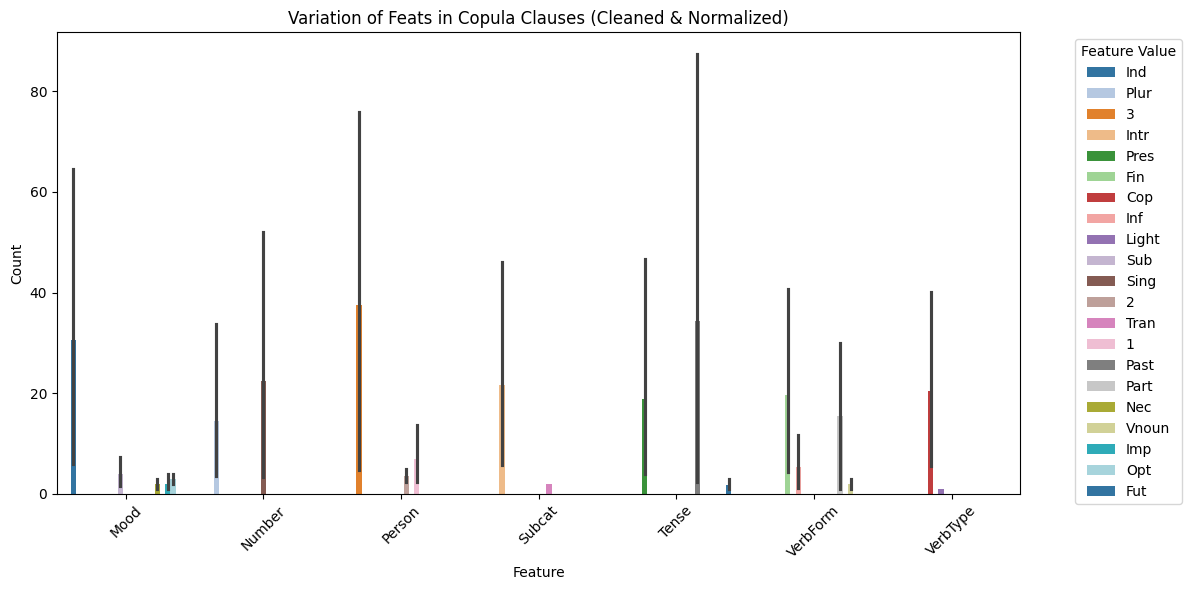

In [228]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# ======================================================
# KEYS TO IGNORE AND KEY MAPPINGS
# ======================================================
ignore_keys = {"Typo", "PartType", "Polarity"}
key_mapping = {
    "VerType": "VerbType",
    "VerbalType": "VerbType"
}

# ======================================================
# COLLECT FEATS FROM ALL COPULA TOKENS (CLEANED)
# ======================================================
copula_feats_global = Counter()

for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    head_to_dependents = defaultdict(list)
    for token in tokens:
        if token.head is not None and isinstance(token.head, int):
            head_to_dependents[token.head].append(token)

    for token in tokens:
        if not token.deprel:
            continue

        dependents = head_to_dependents.get(token.id, [])
        has_cop = any(dep.deprel == "cop" for dep in dependents)
        if token.upos != "VERB" and has_cop:
            # Copula clause
            for dep in dependents:
                if dep.deprel == "cop" and dep.feats:
                    # Clean and normalize feats
                    feats_cleaned = {}
                    for k, v in dep.feats.items():
                        if k in ignore_keys:
                            continue
                        k = key_mapping.get(k, k)
                        feats_cleaned[k] = v
                    feats_tuple = tuple(sorted(feats_cleaned.items()))
                    copula_feats_global[feats_tuple] += 1

# ======================================================
# CONVERT TO DATAFRAME
# ======================================================
records = []
for feats_tuple, count in copula_feats_global.items():
    feats_dict = dict(feats_tuple)
    for feat_name, feat_value in feats_dict.items():
        records.append({
            "Feature": feat_name,
            "Value": feat_value,
            "Count": count
        })

feats_df = pd.DataFrame(records)

# ======================================================
# PLOT FEATURE VALUE DISTRIBUTION
# ======================================================
plt.figure(figsize=(12, 6))
sns.barplot(
    data=feats_df,
    x="Feature",
    y="Count",
    hue="Value",
    palette="tab20"
)
plt.title("Variation of Feats in Copula Clauses (Cleaned & Normalized)")
plt.ylabel("Count")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.legend(title="Feature Value", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\1823409362.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Feature', group_keys=False).apply(replace_rare)
C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\1823409362.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\1823409362.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.b

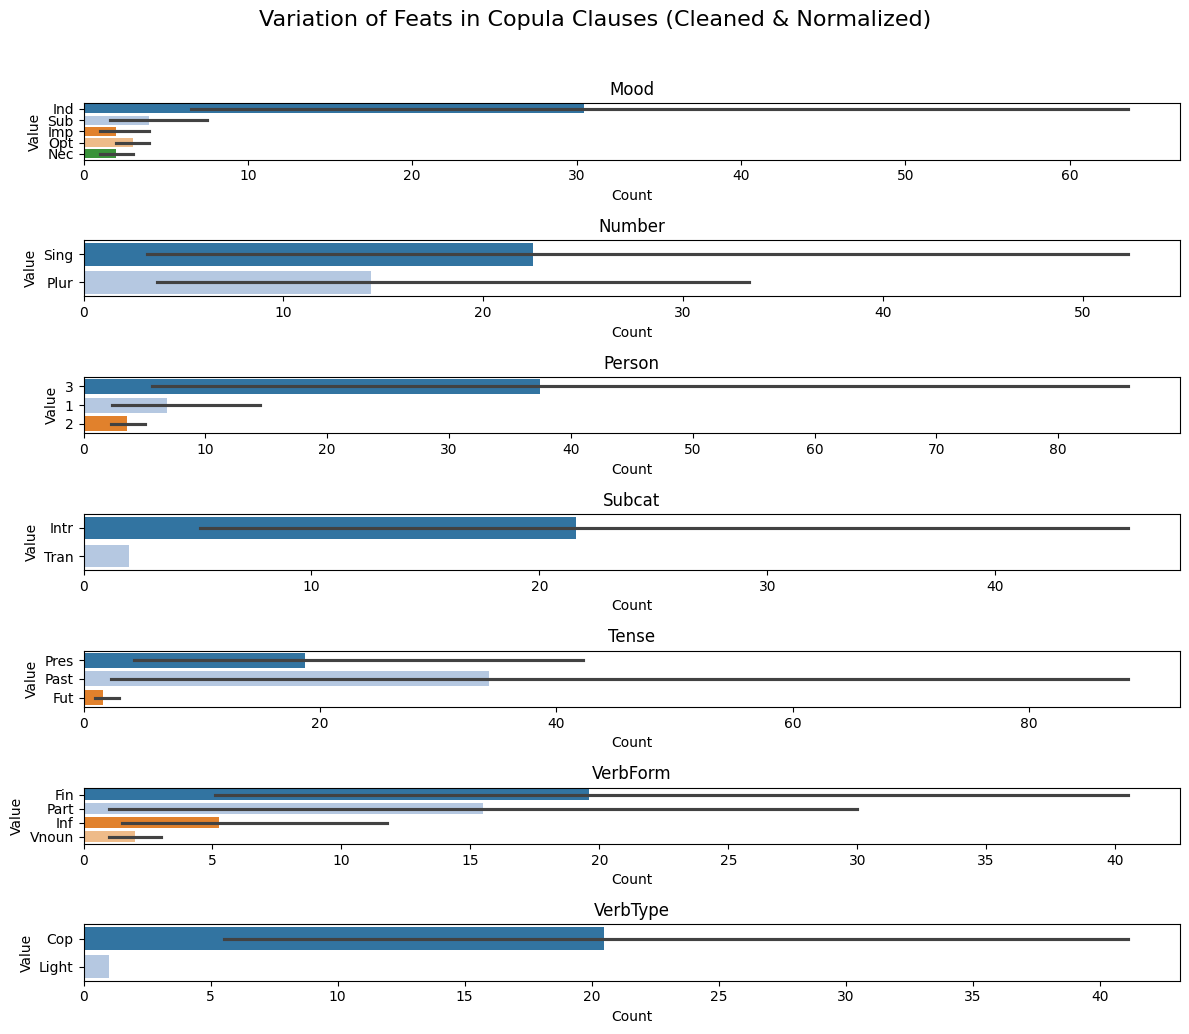

In [229]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# ================================================
# Optional: aggregate rare values under "Other"
# ================================================
def aggregate_rare(df, min_count=2):
    def replace_rare(group):
        value_counts = group['Count'].groupby(group['Value']).sum()
        rare_values = value_counts[value_counts < min_count].index
        group['Value'] = group['Value'].apply(lambda v: 'Other' if v in rare_values else v)
        return group
    return df.groupby('Feature', group_keys=False).apply(replace_rare)

feats_df_agg = aggregate_rare(feats_df, min_count=2)

# ================================================
# Plot: one subplot per Feature
# ================================================
features = feats_df_agg['Feature'].unique()
n_features = len(features)
fig, axes = plt.subplots(n_features, 1, figsize=(12, n_features*1.5), sharex=False)

for ax, feat in zip(axes, features):
    df_feat = feats_df_agg[feats_df_agg['Feature'] == feat]
    df_feat_sorted = df_feat.sort_values('Count', ascending=False)
    sns.barplot(
        data=df_feat_sorted,
        x='Count',
        y='Value',
        palette='tab20',
        ax=ax
    )
    ax.set_title(f"{feat}")
    ax.set_xlabel("Count")
    ax.set_ylabel("Value")

plt.suptitle("Variation of Feats in Copula Clauses (Cleaned & Normalized)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\617928504.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return df.groupby('Feature', group_keys=False).apply(replace_rare)
C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\617928504.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\617928504.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barp

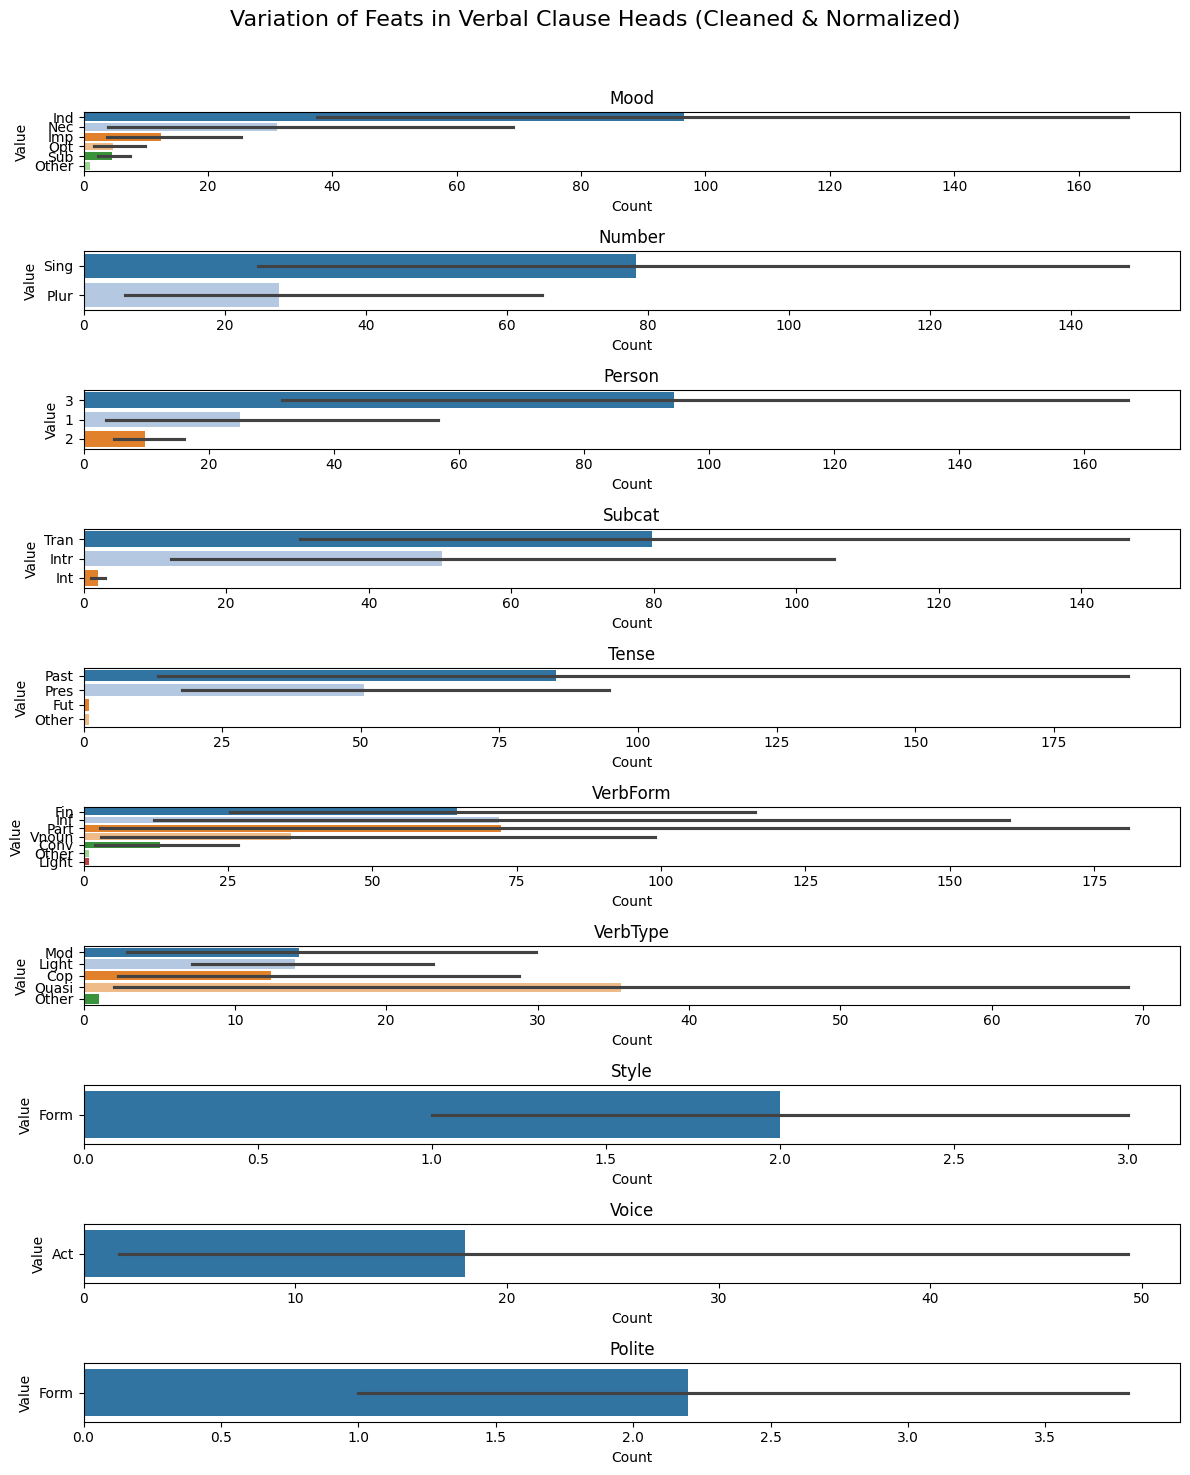

In [233]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

# ================================================
# KEYS TO IGNORE AND KEY MAPPINGS
# ================================================
ignore_keys = {"Typo", "PartType", "Polarity", "Animacy", "Form"}
key_mapping = {
    "VerType": "VerbType",
    "Verbtype": "VerbType",
    "VerbZype": "VerbType",
    "VerbalType": "VerbType",
    "Verbform": "VerbForm"
}

# ================================================
# COLLECT FEATS FROM ALL VERBAL CLAUSE HEADS
# ================================================
verbal_feats_global = Counter()

for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    for token in tokens:
        if token.upos == "VERB":
            # Consider only clause heads
            # We could restrict to tokens whose deprel is in target_deprels if needed
            if not token.feats:
                continue

            feats_cleaned = {}
            for k, v in token.feats.items():
                if k in ignore_keys:
                    continue
                k = key_mapping.get(k, k)
                feats_cleaned[k] = v

            feats_tuple = tuple(sorted(feats_cleaned.items()))
            verbal_feats_global[feats_tuple] += 1

# ================================================
# CONVERT TO DATAFRAME
# ================================================
records = []
for feats_tuple, count in verbal_feats_global.items():
    feats_dict = dict(feats_tuple)
    for feat_name, feat_value in feats_dict.items():
        records.append({
            "Feature": feat_name,
            "Value": feat_value,
            "Count": count
        })

verbal_feats_df = pd.DataFrame(records)

# ================================================
# OPTIONAL: aggregate rare values
# ================================================
def aggregate_rare(df, min_count=2):
    def replace_rare(group):
        value_counts = group['Count'].groupby(group['Value']).sum()
        rare_values = value_counts[value_counts < min_count].index
        group['Value'] = group['Value'].apply(lambda v: 'Other' if v in rare_values else v)
        return group
    return df.groupby('Feature', group_keys=False).apply(replace_rare)

verbal_feats_df_agg = aggregate_rare(verbal_feats_df, min_count=2)

# ================================================
# PLOT: one subplot per Feature
# ================================================
features = verbal_feats_df_agg['Feature'].unique()
n_features = len(features)
fig, axes = plt.subplots(n_features, 1, figsize=(12, n_features*1.5), sharex=False)

for ax, feat in zip(axes, features):
    df_feat = verbal_feats_df_agg[verbal_feats_df_agg['Feature'] == feat]
    df_feat_sorted = df_feat.sort_values('Count', ascending=False)
    sns.barplot(
        data=df_feat_sorted,
        x='Count',
        y='Value',
        palette='tab20',
        ax=ax
    )
    ax.set_title(f"{feat}")
    ax.set_xlabel("Count")
    ax.set_ylabel("Value")

plt.suptitle("Variation of Feats in Verbal Clause Heads (Cleaned & Normalized)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

C:\Users\rahaa\AppData\Local\Temp\ipykernel_32116\755332353.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


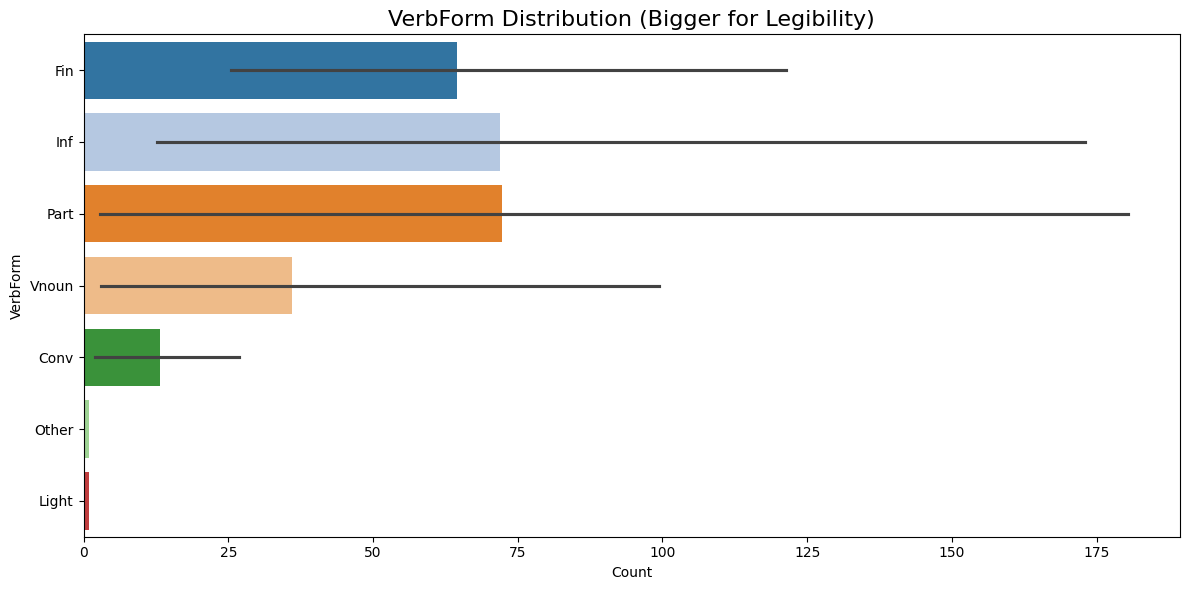

In [235]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# Assume verbal_feats_df_agg is already prepared in the above cell

# Separate VerbForm from the rest
df_verbform = verbal_feats_df_agg[verbal_feats_df_agg['Feature'] == 'VerbForm']
df_other_feats = verbal_feats_df_agg[verbal_feats_df_agg['Feature'] != 'VerbForm']

# ================================================
# PLOT VerbForm separately (bigger for legibility)
# ================================================
plt.figure(figsize=(12, 6))
df_verbform_sorted = df_verbform.sort_values('Count', ascending=False)
sns.barplot(
    data=df_verbform_sorted,
    x='Count',
    y='Value',
    palette='tab20'
)
plt.title("VerbForm Distribution (Bigger for Legibility)", fontsize=16)
plt.xlabel("Count")
plt.ylabel("VerbForm")
plt.tight_layout()
plt.show()


In [ ]:
#cleaning up 

track_keys = {"PartType", "Animacy", "Form", "Verbtype", "VerbZype"}

# Dictionary to collect sentences with these keys
tracked_sentences = defaultdict(list)

# Iterate over corpus and track the specified keys
for sentence in syntactically_annotated_corpus:
    tokens = sentence.get_tokens()
    for token in tokens:
        if token.upos == "VERB" and token.feats:
            # Check if any of the tracked keys are present
            present_keys = [k for k in token.feats if k in track_keys]
            if present_keys:
                sent_id = sentence.metadata.get("SENTENCE ID", "unknown")
                text = sentence.metadata.get("text", "unknown")
                tracked_sentences[sent_id].append({
                    "text": text,
                    "token": token.form,
                    "present_keys": present_keys,
                    "all_feats": token.feats
                })

# ================================================
# Print sentences with the tracked keys
# ================================================
for sent_id, entries in tracked_sentences.items():
    print(f"\nSENTENCE ID: {sent_id}")
    for entry in entries:
        print(f"  Text: {entry['text']}")
        print(f"  Token: {entry['token']}")
        print(f"  Tracked keys present: {entry['present_keys']}")
        print(f"  All feats: {entry['all_feats']}")


SENTENCE ID: DD-K35 s253	_	_	_	_	_	_	_	_	_
  Text: _ _ _ _ ud ān ī ahlawān pad bōxtan az ahreman madan ī ō ohrmazdīg axwān šād bawēd
  Token: madan
  Tracked keys present: ['Animacy']
  All feats: {'Animacy': 'Inan', 'Subcat': 'Intr', 'VerbForm': 'Inf'}

SENTENCE ID: DMX-K43a s17	_	_	_	_	_	_	_	_	_
  Text: _ _ _ čē gētīg pad xrad šāyēd rāyēnīdan
  Token: rāyēnīdan
  Tracked keys present: ['Animacy']
  All feats: {'Animacy': 'Inan', 'Subcat': 'Tran', 'VerbForm': 'Inf'}

SENTENCE ID: DMX-K43a s18	_	_	_	_	_	_	_	_	_
  Text: _ _ _ ud mēnōy pad nērōg ī xrad ō xwēš šāyēd kirdan ,
  Token: kirdan
  Tracked keys present: ['Animacy']
  All feats: {'Animacy': 'Inan', 'Subcat': 'Tran', 'VerbForm': 'Inf'}

SENTENCE ID: Dk5-B s157	_	_	_	_	_	_	_	_	_
  Text: _ _ _ ud kē nang nigerēd abēnangīh =iz ī az ān frāzšawišnīh ī bēgānag kas awi =š
  Token: nigerēd
  Tracked keys present: ['Verbtype']
  All feats: {'Mood': 'Ind', 'Number': 'Sing', 'Person': '3', 'Subcat': 'Tran', 'Tense': 'Pres', 'VerbForm': 'Fi